In [1]:
#Copied from Aaron's code @ https://github.com/aaronw5/Interpreting-Transformers-for-Jet-Tagging
# Update if repo changes

In [2]:
import numpy as np
import awkward as ak
import uproot
import vector
vector.register_awkward()
import os
import shutil
import zipfile
import tarfile
import urllib
import requests
from tqdm import tqdm
import torch
#from weaver.nn.model.ParticleTransformer import ParticleTransformer
#from weaver.utils.logger import _logger
import torch.optim as optim
#from EfficientParticleTransformer import EfficientParticleTransformer
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

In [2]:
#!pip install mplhep

In [3]:
import mplhep as hep

hep.style.use(hep.style.ROOT)

In [4]:
def build_features_and_labels(tree, transform_features=True):

    # load arrays from the tree
    a = tree.arrays(filter_name=['part_*', 'jet_pt', 'jet_energy', 'label_*'])

    # compute new features
    a['part_mask'] = ak.ones_like(a['part_energy'])
    a['part_pt'] = np.hypot(a['part_px'], a['part_py'])
    a['part_pt_log'] = np.log(a['part_pt'])
    a['part_e_log'] = np.log(a['part_energy'])
    a['part_logptrel'] = np.log(a['part_pt']/a['jet_pt'])
    a['part_logerel'] = np.log(a['part_energy']/a['jet_energy'])
    a['part_deltaR'] = np.hypot(a['part_deta'], a['part_dphi'])
    a['part_d0'] = np.tanh(a['part_d0val'])
    a['part_dz'] = np.tanh(a['part_dzval'])

    # apply standardization
    if transform_features:
        a['part_pt_log'] = (a['part_pt_log'] - 1.7) * 0.7
        a['part_e_log'] = (a['part_e_log'] - 2.0) * 0.7
        a['part_logptrel'] = (a['part_logptrel'] - (-4.7)) * 0.7
        a['part_logerel'] = (a['part_logerel'] - (-4.7)) * 0.7
        a['part_deltaR'] = (a['part_deltaR'] - 0.2) * 4.0
        a['part_d0err'] = _clip(a['part_d0err'], 0, 1)
        a['part_dzerr'] = _clip(a['part_dzerr'], 0, 1)

    feature_list = {
        'pf_points': ['part_deta', 'part_dphi'], # not used in ParT
        'pf_features': [
            'part_pt_log',
            'part_e_log',
            'part_logptrel',
            'part_logerel',
            'part_deltaR',
            'part_charge',
            'part_isChargedHadron',
            'part_isNeutralHadron',
            'part_isPhoton',
            'part_isElectron',
            'part_isMuon',
            'part_d0',
            'part_d0err',
            'part_dz',
            'part_dzerr',
            'part_deta',
            'part_dphi',
        ],
        'pf_vectors': [
            'part_px',
            'part_py',
            'part_pz',
            'part_energy',
        ],
        'pf_mask': ['part_mask']
    }

    out = {}
    for k, names in feature_list.items():
        out[k] = np.stack([_pad(a[n], maxlen=128).to_numpy() for n in names], axis=1)

    label_list = ['label_QCD', 'label_Hbb', 'label_Hcc', 'label_Hgg', 'label_H4q', 'label_Hqql', 'label_Zqq', 'label_Wqq', 'label_Tbqq', 'label_Tbl']
    out['label'] = np.stack([a[n].to_numpy().astype('int') for n in label_list], axis=1)

    return out

# Feature building function (adapted from AttentionGraphs.ipynb and config files)
def build_features_and_labels_qg(tree, transform_features=True):
    """Build features for QuarkGluon dataset based on qg_kinpid.yaml"""
    # load arrays from the tree
    a = tree.arrays(filter_name=['part_*', 'jet_pt', 'jet_energy', 'label'])

    # compute new features
    a['part_mask'] = ak.ones_like(a['part_energy'])
    a['part_pt'] = np.hypot(a['part_px'], a['part_py'])
    a['part_pt_log'] = np.log(a['part_pt'])
    a['part_e_log'] = np.log(a['part_energy'])
    a['part_logptrel'] = np.log(a['part_pt']/a['jet_pt'])
    a['part_logerel'] = np.log(a['part_energy']/a['jet_energy'])
    a['part_deltaR'] = np.hypot(a['part_deta'], a['part_dphi'])

    # apply standardization based on qg_kinpid.yaml
    if transform_features:
        a['part_pt_log'] = (a['part_pt_log'] - 1.7) * 0.7
        a['part_e_log'] = (a['part_e_log'] - 2.0) * 0.7
        a['part_logptrel'] = (a['part_logptrel'] - (-4.7)) * 0.7
        a['part_logerel'] = (a['part_logerel'] - (-4.7)) * 0.7
        a['part_deltaR'] = (a['part_deltaR'] - 0.2) * 4.0

    # Feature list for QuarkGluon (kinematic + particle ID)
    feature_list = {
        'pf_points': ['part_deta', 'part_dphi'],
        'pf_features': [
            'part_pt_log',
            'part_e_log', 
            'part_logptrel',
            'part_logerel',
            'part_deltaR',
            'part_charge',
            'part_isChargedHadron',
            'part_isNeutralHadron',
            'part_isPhoton',
            'part_isElectron',
            'part_isMuon',
            'part_deta',
            'part_dphi',
        ],
        'pf_vectors': [
            'part_px',
            'part_py',
            'part_pz',
            'part_energy',
        ],
        'pf_mask': ['part_mask']
    }

    def _pad(a, maxlen=128, value=0, dtype='float32'):
        if isinstance(a, np.ndarray) and a.ndim >= 2 and a.shape[1] == maxlen:
            return a
        elif isinstance(a, ak.Array):
            if a.ndim == 1:
                a = ak.unflatten(a, 1)
            a = ak.fill_none(ak.pad_none(a, maxlen, clip=True), value)
            return ak.values_astype(a, dtype)
        else:
            x = (np.ones((len(a), maxlen)) * value).astype(dtype)
            for idx, s in enumerate(a):
                if not len(s):
                    continue
                trunc = s[:maxlen].astype(dtype)
                x[idx, :len(trunc)] = trunc
            return x

    out = {}
    for k, names in feature_list.items():
        out[k] = np.stack([_pad(a[n], maxlen=128).to_numpy() for n in names], axis=1)

    # Labels for QuarkGluon (binary classification)
    out['label'] = a['label'].to_numpy().astype('int')
    
    return out

def build_features_and_labels_tl(tree, transform_features=True):
    """Build features for TopLandscape dataset based on top_kin.yaml"""
    # load arrays from the tree
    a = tree.arrays(filter_name=['part_*', 'jet_pt', 'jet_energy', 'label'])

    # compute new features (same as QG)
    a['part_mask'] = ak.ones_like(a['part_energy'])
    a['part_pt'] = np.hypot(a['part_px'], a['part_py'])
    a['part_pt_log'] = np.log(a['part_pt'])
    a['part_e_log'] = np.log(a['part_energy'])
    a['part_logptrel'] = np.log(a['part_pt']/a['jet_pt'])
    a['part_logerel'] = np.log(a['part_energy']/a['jet_energy'])
    a['part_deltaR'] = np.hypot(a['part_deta'], a['part_dphi'])

    # apply standardization based on top_kin.yaml (same as QG)
    if transform_features:
        a['part_pt_log'] = (a['part_pt_log'] - 1.7) * 0.7
        a['part_e_log'] = (a['part_e_log'] - 2.0) * 0.7
        a['part_logptrel'] = (a['part_logptrel'] - (-4.7)) * 0.7
        a['part_logerel'] = (a['part_logerel'] - (-4.7)) * 0.7
        a['part_deltaR'] = (a['part_deltaR'] - 0.2) * 4.0

    # Feature list for TopLandscape (same kinematic features as QG)
    feature_list = {
        'pf_points': ['part_deta', 'part_dphi'],
        'pf_features': [
            'part_pt_log',
            'part_e_log',
            'part_logptrel', 
            'part_logerel',
            'part_deltaR',
            'part_deta',
            'part_dphi',
        ],
        'pf_vectors': [
            'part_px',
            'part_py',
            'part_pz',
            'part_energy',
        ],
        'pf_mask': ['part_mask']
    }

    def _pad(a, maxlen=128, value=0, dtype='float32'):
        if isinstance(a, np.ndarray) and a.ndim >= 2 and a.shape[1] == maxlen:
            return a
        elif isinstance(a, ak.Array):
            if a.ndim == 1:
                a = ak.unflatten(a, 1)
            a = ak.fill_none(ak.pad_none(a, maxlen, clip=True), value)
            return ak.values_astype(a, dtype)
        else:
            x = (np.ones((len(a), maxlen)) * value).astype(dtype)
            for idx, s in enumerate(a):
                if not len(s):
                    continue
                trunc = s[:maxlen].astype(dtype)
                x[idx, :len(trunc)] = trunc
            return x

    out = {}
    for k, names in feature_list.items():
        out[k] = np.stack([_pad(a[n], maxlen=128).to_numpy() for n in names], axis=1)

    # Labels for TopLandscape (binary classification) 
    out['label'] = a['label'].to_numpy().astype('int')

    return out

def build_features_and_labels_hls4ml(tree, features = "kin", transform_features=True):
    """Build features for HLS4ML dataset based on hls4ml_kin.yaml or hls4ml_kinplus.yaml"""
    # load arrays from the tree
    # all feature names are j1_ or j_ because build_features_and_labels reads the ROOT file
    # We build features so that names are identical between training and analysis stages
    a = tree.arrays(filter_name=['j1_*', 'j_pt', 'j_energy', 'j_is*'])

    if features == "kin":
        # compute new features (same as QG)
        a['part_mask'] = ak.ones_like(a['j1_energy'])
        a['part_pt'] = np.hypot(a['j1_px'], a['j1_py'])
        a['part_pt_log'] = np.log(a['j1_pt'])
        a['part_e_log'] = np.log(a['j1_e'])
        a['part_logptrel'] = np.log(a['j1_pt']/a['j_pt'])
        a['part_logerel'] = np.log(a['j1_e']/a['j_energy'])

        # alter names to fit with part_ convention instead of j1_
        a['part_px'] = a['j1_px']
        a['part_py'] = a['j1_py']
        a['part_pz'] = a['j1_pz']
        a['part_etarel'] = a['j1_etarel']
        a['part_phirel'] = a['j1_phirel']
        a['part_eta'] = a['j1_eta']
        a['part_energy'] = a['j1_e']
        a['part_deltaR'] = a['j1_deltaR']

    # apply standardization, same as other dataset .yaml configs
    #if transform_features:
    #    a['part_pt_log'] = a['part_pt_log']
    #    a['part_e_log'] = a['part_e_log']
    #    a['part_logptrel'] = a['part_logptrel']
    #    a['part_logerel'] = a['part_logerel']
    #    a['part_deltaR'] = a['part_deltaR']

        # Feature list for HLS4ML
        feature_list = {
            'pf_points': ['part_etarel', 'part_phirel'],
            'pf_features': [
                'part_pt_log',
                'part_e_log',
                'part_logptrel', 
                'part_logerel',
                'part_deltaR',
                'part_etarel',
                'part_phirel',
            ],
            'pf_vectors': [
                'part_px',
                'part_py',
                'part_pz',
                'part_energy',
            ],
            'pf_mask': ['part_mask']
        }
    
    elif features == "kinplus":
        
        # compute new features (just mask for kinplus)
        a['part_mask'] = ak.ones_like(a['j1_e'])

        # alter names to fit with part_ convention
        a['part_px'] = a['j1_px']
        a['part_py'] = a['j1_py']
        a['part_pz'] = a['j1_pz']
        a['part_energy'] = a['j1_e']
        a['part_erel'] = a['j1_erel']
        a['part_pt'] = a['j1_pt']
        a['part_ptrel'] = a['j1_ptrel']
        a['part_eta'] = a['j1_eta']
        a['part_etarel'] = a['j1_etarel']
        a['part_etarot'] = a['j1_etarot']
        a['part_phi'] = a['j1_phi']
        a['part_phirel'] = a['j1_phirel']
        a['part_phirot'] = a['j1_phirot']
        a['part_deltaR'] = a['j1_deltaR']
        a['part_costheta'] = a['j1_costheta']
        a['part_costhetarel'] = a['j1_costhetarel']

        # Feature list for HLS4ML with all particle features
        feature_list = {
            'pf_points': ['part_etarel', 'part_phirel'],
            'pf_features': [
                'part_px',
                'part_py',
                'part_pz',
                'part_energy',
                'part_erel',
                'part_pt',
                'part_ptrel',
                'part_eta',
                'part_etarel',
                'part_etarot',
                'part_phi',
                'part_phirel',
                'part_phirot',
                'part_deltaR',
                'part_costheta',
                'part_costhetarel',
            ],
            'pf_vectors': [
                'part_px',
                'part_py',
                'part_pz',
                'part_energy',
            ],
            'pf_mask': ['part_mask']
        }

    def _pad(a, maxlen=150, value=0, dtype='float32'):
        if isinstance(a, np.ndarray) and a.ndim >= 2 and a.shape[1] == maxlen:
            return a
        elif isinstance(a, ak.Array):
            if a.ndim == 1:
                a = ak.unflatten(a, 1)
            a = ak.fill_none(ak.pad_none(a, maxlen, clip=True), value)
            return ak.values_astype(a, dtype)
        else:
            x = (np.ones((len(a), maxlen)) * value).astype(dtype)
            for idx, s in enumerate(a):
                if not len(s):
                    continue
                trunc = s[:maxlen].astype(dtype)
                x[idx, :len(trunc)] = trunc
            return x

    out = {}
    for k, names in feature_list.items():
        out[k] = np.stack([_pad(a[n], maxlen=150).to_numpy() for n in names], axis=1)

    label_list = ['j_isGluon', 'j_isQuark', 'j_isW', 'j_isZ', 'j_isTop']
    out['label'] = np.stack([a[n].to_numpy().astype('int') for n in label_list], axis=1)

    return out

In [5]:
#!pip install 'weaver-core>=0.4'

In [5]:
#!pip install fastjet

In [5]:
''' Particle Transformer (ParT)

Paper: "Particle Transformer for Jet Tagging" - https://arxiv.org/abs/2202.03772
'''
import math
import random
import warnings
import copy
import torch
import torch.nn as nn
from functools import partial

from typing import Dict, Optional, Tuple
#from fairseq import utils
#from fairseq.incremental_decoding_utils import with_incremental_state
#from fairseq.modules.quant_noise import quant_noise
from torch import Tensor, nn
from torch.nn import Parameter
from weaver.utils.logger import _logger
import torch.nn.functional as F



@torch.jit.script
def delta_phi(a, b):
    return (a - b + math.pi) % (2 * math.pi) - math.pi


@torch.jit.script
def delta_r2(eta1, phi1, eta2, phi2):
    return (eta1 - eta2)**2 + delta_phi(phi1, phi2)**2


def to_pt2(x, eps=1e-8):
    pt2 = x[:, :2].square().sum(dim=1, keepdim=True)
    if eps is not None:
        pt2 = pt2.clamp(min=eps)
    return pt2


def to_m2(x, eps=1e-8):
    m2 = x[:, 3:4].square() - x[:, :3].square().sum(dim=1, keepdim=True)
    if eps is not None:
        m2 = m2.clamp(min=eps)
    return m2


def atan2(y, x):
    sx = torch.sign(x)
    sy = torch.sign(y)
    pi_part = (sy + sx * (sy ** 2 - 1)) * (sx - 1) * (-math.pi / 2)
    atan_part = torch.arctan(y / (x + (1 - sx ** 2))) * sx ** 2
    return atan_part + pi_part


def to_ptrapphim(x, return_mass=True, eps=1e-8, for_onnx=False):
    # x: (N, 4, ...), dim1 : (px, py, pz, E)
    px, py, pz, energy = x.split((1, 1, 1, 1), dim=1)
    pt = torch.sqrt(to_pt2(x, eps=eps))
    # rapidity = 0.5 * torch.log((energy + pz) / (energy - pz))
    rapidity = 0.5 * torch.log(1 + (2 * pz) / (energy - pz).clamp(min=1e-20))
    phi = (atan2 if for_onnx else torch.atan2)(py, px)
    if not return_mass:
        return torch.cat((pt, rapidity, phi), dim=1)
    else:
        m = torch.sqrt(to_m2(x, eps=eps))
        return torch.cat((pt, rapidity, phi, m), dim=1)


def boost(x, boostp4, eps=1e-8):
    # boost x to the rest frame of boostp4
    # x: (N, 4, ...), dim1 : (px, py, pz, E)
    p3 = -boostp4[:, :3] / boostp4[:, 3:].clamp(min=eps)
    b2 = p3.square().sum(dim=1, keepdim=True)
    gamma = (1 - b2).clamp(min=eps)**(-0.5)
    gamma2 = (gamma - 1) / b2
    gamma2.masked_fill_(b2 == 0, 0)
    bp = (x[:, :3] * p3).sum(dim=1, keepdim=True)
    v = x[:, :3] + gamma2 * bp * p3 + x[:, 3:] * gamma * p3
    return v


def p3_norm(p, eps=1e-8):
    return p[:, :3] / p[:, :3].norm(dim=1, keepdim=True).clamp(min=eps)


def pairwise_lv_fts(xi, xj, num_outputs=4, eps=1e-8, for_onnx=False):
    pti, rapi, phii = to_ptrapphim(xi, False, eps=None, for_onnx=for_onnx).split((1, 1, 1), dim=1)
    ptj, rapj, phij = to_ptrapphim(xj, False, eps=None, for_onnx=for_onnx).split((1, 1, 1), dim=1)

    delta = delta_r2(rapi, phii, rapj, phij).sqrt()
    lndelta = torch.log(delta.clamp(min=eps))
    if num_outputs == 1:
        return lndelta

    if num_outputs > 1:
        ptmin = ((pti <= ptj) * pti + (pti > ptj) * ptj) if for_onnx else torch.minimum(pti, ptj)
        lnkt = torch.log((ptmin * delta).clamp(min=eps))
        lnz = torch.log((ptmin / (pti + ptj).clamp(min=eps)).clamp(min=eps))
        outputs = [lnkt, lnz, lndelta]

    if num_outputs > 3:
        xij = xi + xj
        lnm2 = torch.log(to_m2(xij, eps=eps))
        outputs.append(lnm2)

    if num_outputs > 4:
        lnds2 = torch.log(torch.clamp(-to_m2(xi - xj, eps=None), min=eps))
        outputs.append(lnds2)

    # the following features are not symmetric for (i, j)
    if num_outputs > 5:
        xj_boost = boost(xj, xij)
        costheta = (p3_norm(xj_boost, eps=eps) * p3_norm(xij, eps=eps)).sum(dim=1, keepdim=True)
        outputs.append(costheta)

    if num_outputs > 6:
        deltarap = rapi - rapj
        deltaphi = delta_phi(phii, phij)
        outputs += [deltarap, deltaphi]

    assert (len(outputs) == num_outputs)
    return torch.cat(outputs, dim=1)


def build_sparse_tensor(uu, idx, seq_len):
    # inputs: uu (N, C, num_pairs), idx (N, 2, num_pairs)
    # return: (N, C, seq_len, seq_len)
    batch_size, num_fts, num_pairs = uu.size()
    idx = torch.min(idx, torch.ones_like(idx) * seq_len)
    i = torch.cat((
        torch.arange(0, batch_size, device=uu.device).repeat_interleave(num_fts * num_pairs).unsqueeze(0),
        torch.arange(0, num_fts, device=uu.device).repeat_interleave(num_pairs).repeat(batch_size).unsqueeze(0),
        idx[:, :1, :].expand_as(uu).flatten().unsqueeze(0),
        idx[:, 1:, :].expand_as(uu).flatten().unsqueeze(0),
    ), dim=0)
    return torch.sparse_coo_tensor(
        i, uu.flatten(),
        size=(batch_size, num_fts, seq_len + 1, seq_len + 1),
        device=uu.device).to_dense()[:, :, :seq_len, :seq_len]


def trunc_normal_(tensor, mean=0., std=1., a=-2., b=2.):
    # From https://github.com/rwightman/pytorch-image-models/blob/18ec173f95aa220af753358bf860b16b6691edb2/timm/layers/weight_init.py#L8
    r"""Fills the input Tensor with values drawn from a truncated
    normal distribution. The values are effectively drawn from the
    normal distribution :math:`\mathcal{N}(\text{mean}, \text{std}^2)`
    with values outside :math:`[a, b]` redrawn until they are within
    the bounds. The method used for generating the random values works
    best when :math:`a \leq \text{mean} \leq b`.
    Args:
        tensor: an n-dimensional `torch.Tensor`
        mean: the mean of the normal distribution
        std: the standard deviation of the normal distribution
        a: the minimum cutoff value
        b: the maximum cutoff value
    Examples:
        >>> w = torch.empty(3, 5)
        >>> nn.init.trunc_normal_(w)
    """
    def norm_cdf(x):
        # Computes standard normal cumulative distribution function
        return (1. + math.erf(x / math.sqrt(2.))) / 2.

    if (mean < a - 2 * std) or (mean > b + 2 * std):
        warnings.warn("mean is more than 2 std from [a, b] in nn.init.trunc_normal_. "
                      "The distribution of values may be incorrect.",
                      stacklevel=2)

    with torch.no_grad():
        # Values are generated by using a truncated uniform distribution and
        # then using the inverse CDF for the normal distribution.
        # Get upper and lower cdf values
        l = norm_cdf((a - mean) / std)
        u = norm_cdf((b - mean) / std)

        # Uniformly fill tensor with values from [l, u], then translate to
        # [2l-1, 2u-1].
        tensor.uniform_(2 * l - 1, 2 * u - 1)

        # Use inverse cdf transform for normal distribution to get truncated
        # standard normal
        tensor.erfinv_()

        # Transform to proper mean, std
        tensor.mul_(std * math.sqrt(2.))
        tensor.add_(mean)

        # Clamp to ensure it's in the proper range
        tensor.clamp_(min=a, max=b)
        return tensor


class SequenceTrimmer(nn.Module):

    def __init__(self, enabled=False, target=(0.9, 1.02), **kwargs) -> None:
        super().__init__(**kwargs)
        self.enabled = enabled
        self.target = target
        self._counter = 0

    def forward(self, x, v=None, mask=None, uu=None):
        # x: (N, C, P)
        # v: (N, 4, P) [px,py,pz,energy]
        # mask: (N, 1, P) -- real particle = 1, padded = 0
        # uu: (N, C', P, P)
        if mask is None:
            mask = torch.ones_like(x[:, :1])
        mask = mask.bool()

        if self.enabled:
            if self._counter < 5:
                self._counter += 1
            else:
                if self.training:
                    q = min(1, random.uniform(*self.target))
                    maxlen = torch.quantile(mask.type_as(x).sum(dim=-1), q).long()
                    rand = torch.rand_like(mask.type_as(x))
                    rand.masked_fill_(~mask, -1)
                    perm = rand.argsort(dim=-1, descending=True)  # (N, 1, P)
                    mask = torch.gather(mask, -1, perm)
                    x = torch.gather(x, -1, perm.expand_as(x))
                    if v is not None:
                        v = torch.gather(v, -1, perm.expand_as(v))
                    if uu is not None:
                        uu = torch.gather(uu, -2, perm.unsqueeze(-1).expand_as(uu))
                        uu = torch.gather(uu, -1, perm.unsqueeze(-2).expand_as(uu))
                else:
                    maxlen = mask.sum(dim=-1).max()
                maxlen = max(maxlen, 1)
                if maxlen < mask.size(-1):
                    mask = mask[:, :, :maxlen]
                    x = x[:, :, :maxlen]
                    if v is not None:
                        v = v[:, :, :maxlen]
                    if uu is not None:
                        uu = uu[:, :, :maxlen, :maxlen]

        return x, v, mask, uu


class Embed(nn.Module):
    def __init__(self, input_dim, dims, normalize_input=True, activation='gelu'):
        super().__init__()

        self.input_bn = nn.BatchNorm1d(input_dim) if normalize_input else None
        module_list = []
        for dim in dims:
            module_list.extend([
                nn.LayerNorm(input_dim),
                nn.Linear(input_dim, dim),
                nn.GELU() if activation == 'gelu' else nn.ReLU(),
            ])
            input_dim = dim
        self.embed = nn.Sequential(*module_list)

    def forward(self, x):
        if self.input_bn is not None:
            # x: (batch, embed_dim, seq_len)
            x = self.input_bn(x)
            x = x.permute(2, 0, 1).contiguous()
        # x: (seq_len, batch, embed_dim)
        return self.embed(x)


class PairEmbed(nn.Module):
    def __init__(
            self, pairwise_lv_dim, pairwise_input_dim, dims,
            remove_self_pair=False, use_pre_activation_pair=True, mode='sum',
            normalize_input=True, activation='gelu', eps=1e-8,
            for_onnx=False):
        super().__init__()

        self.pairwise_lv_dim = pairwise_lv_dim
        self.pairwise_input_dim = pairwise_input_dim
        self.is_symmetric = (pairwise_lv_dim <= 5) and (pairwise_input_dim == 0)
        self.remove_self_pair = remove_self_pair
        self.mode = mode
        self.for_onnx = for_onnx
        self.pairwise_lv_fts = partial(pairwise_lv_fts, num_outputs=pairwise_lv_dim, eps=eps, for_onnx=for_onnx)
        self.out_dim = dims[-1]

        if self.mode == 'concat':
            input_dim = pairwise_lv_dim + pairwise_input_dim
            module_list = [nn.BatchNorm1d(input_dim)] if normalize_input else []
            for dim in dims:
                module_list.extend([
                    nn.Conv1d(input_dim, dim, 1),
                    nn.BatchNorm1d(dim),
                    nn.GELU() if activation == 'gelu' else nn.ReLU(),
                ])
                input_dim = dim
            if use_pre_activation_pair:
                module_list = module_list[:-1]
            self.embed = nn.Sequential(*module_list)
        elif self.mode == 'sum':
            if pairwise_lv_dim > 0:
                input_dim = pairwise_lv_dim
                module_list = [nn.BatchNorm1d(input_dim)] if normalize_input else []
                for dim in dims:
                    module_list.extend([
                        nn.Conv1d(input_dim, dim, 1),
                        nn.BatchNorm1d(dim),
                        nn.GELU() if activation == 'gelu' else nn.ReLU(),
                    ])
                    input_dim = dim
                if use_pre_activation_pair:
                    module_list = module_list[:-1]
                self.embed = nn.Sequential(*module_list)

            if pairwise_input_dim > 0:
                input_dim = pairwise_input_dim
                module_list = [nn.BatchNorm1d(input_dim)] if normalize_input else []
                for dim in dims:
                    module_list.extend([
                        nn.Conv1d(input_dim, dim, 1),
                        nn.BatchNorm1d(dim),
                        nn.GELU() if activation == 'gelu' else nn.ReLU(),
                    ])
                    input_dim = dim
                if use_pre_activation_pair:
                    module_list = module_list[:-1]
                self.fts_embed = nn.Sequential(*module_list)
        else:
            raise RuntimeError('`mode` can only be `sum` or `concat`')

    def forward(self, x, uu=None):
        # x: (batch, v_dim, seq_len)
        # uu: (batch, v_dim, seq_len, seq_len)
        assert (x is not None or uu is not None)
        with torch.no_grad():
            if x is not None:
                batch_size, _, seq_len = x.size()
            else:
                batch_size, _, seq_len, _ = uu.size()
            if self.is_symmetric and not self.for_onnx:
                i, j = torch.tril_indices(seq_len, seq_len, offset=-1 if self.remove_self_pair else 0,
                                          device=(x if x is not None else uu).device)
                if x is not None:
                    x = x.unsqueeze(-1).repeat(1, 1, 1, seq_len)
                    xi = x[:, :, i, j]  # (batch, dim, seq_len*(seq_len+1)/2)
                    xj = x[:, :, j, i]
                    x = self.pairwise_lv_fts(xi, xj)
                if uu is not None:
                    # (batch, dim, seq_len*(seq_len+1)/2)
                    uu = uu[:, :, i, j]
            else:
                if x is not None:
                    x = self.pairwise_lv_fts(x.unsqueeze(-1), x.unsqueeze(-2))
                    if self.remove_self_pair:
                        i = torch.arange(0, seq_len, device=x.device)
                        x[:, :, i, i] = 0
                    x = x.view(-1, self.pairwise_lv_dim, seq_len * seq_len)
                if uu is not None:
                    uu = uu.view(-1, self.pairwise_input_dim, seq_len * seq_len)
            if self.mode == 'concat':
                if x is None:
                    pair_fts = uu
                elif uu is None:
                    pair_fts = x
                else:
                    pair_fts = torch.cat((x, uu), dim=1)

        if self.mode == 'concat':
            elements = self.embed(pair_fts)  # (batch, embed_dim, num_elements)
        elif self.mode == 'sum':
            if x is None:
                elements = self.fts_embed(uu)
            elif uu is None:
                elements = self.embed(x)
            else:
                elements = self.embed(x) + self.fts_embed(uu)

        if self.is_symmetric and not self.for_onnx:
            y = torch.zeros(batch_size, self.out_dim, seq_len, seq_len, dtype=elements.dtype, device=elements.device)
            y[:, :, i, j] = elements
            y[:, :, j, i] = elements
        else:
            y = elements.view(-1, self.out_dim, seq_len, seq_len)
        return y





class Block(nn.Module):
    def __init__(self, embed_dim=128, num_heads=8, ffn_ratio=4,
                 dropout=0.1, attn_dropout=0.1, activation_dropout=0.1,
                 add_bias_kv=False, activation='gelu',
                 scale_fc=True, scale_attn=True, scale_heads=True, scale_resids=True):
        super().__init__()

        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.ffn_dim = embed_dim * ffn_ratio
        self.interaction = None
        self.pre_mask_attn_weights = None  # To store attention weights before mask is applied

        self.pre_attn_norm = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(
            embed_dim,
            num_heads,
            dropout=attn_dropout,
            add_bias_kv=add_bias_kv,
        )
        self.post_attn_norm = nn.LayerNorm(embed_dim) if scale_attn else None
        self.dropout = nn.Dropout(dropout)

        self.pre_fc_norm = nn.LayerNorm(embed_dim)
        self.fc1 = nn.Linear(embed_dim, self.ffn_dim)
        self.act = nn.GELU() if activation == 'gelu' else nn.ReLU()
        self.act_dropout = nn.Dropout(activation_dropout)
        self.post_fc_norm = nn.LayerNorm(self.ffn_dim) if scale_fc else None
        self.fc2 = nn.Linear(self.ffn_dim, embed_dim)

        self.c_attn = nn.Parameter(torch.ones(num_heads), requires_grad=True) if scale_heads else None
        self.w_resid = nn.Parameter(torch.ones(embed_dim), requires_grad=True) if scale_resids else None
    def getAttention(self):
        return self.interaction
    def getPreMaskAttention(self):
        return self.pre_mask_attn_weights
    def forward(self, x, x_cls=None, padding_mask=None, attn_mask=None):
        """
        Args:
            x (Tensor): input to the layer of shape (seq_len, batch, embed_dim)
            x_cls (Tensor, optional): class token input to the layer of shape (1, batch, embed_dim)
            padding_mask (ByteTensor, optional): binary
                ByteTensor of shape (batch, seq_len) where padding
                elements are indicated by `1.

        Returns:
            encoded output of shape (seq_len, batch, embed_dim)
        """

        if x_cls is not None:
            with torch.no_grad():
                # prepend one element for x_cls: -> (batch, 1+seq_len)
                padding_mask = torch.cat((torch.zeros_like(padding_mask[:, :1]), padding_mask), dim=1)
            # class attention: https://arxiv.org/pdf/2103.17239.pdf
            residual = x_cls
            u = torch.cat((x_cls, x), dim=0)  # (seq_len+1, batch, embed_dim)
            u = self.pre_attn_norm(u)
            x = self.attn(x_cls, u, u, key_padding_mask=padding_mask)[0]  # (1, batch, embed_dim)
        else:
            residual = x


            x = self.pre_attn_norm(x)


            x= self.attn(x, x, x, key_padding_mask=padding_mask,
                          attn_mask=attn_mask, average_attn_weights=False)[0]  # (seq_len, batch, embed_dim)
            y= self.attn(x, x, x, key_padding_mask=padding_mask,
                          attn_mask=attn_mask, average_attn_weights=False)[1]
            self.interaction = y


        if self.c_attn is not None:
            tgt_len = x.size(0)
            x = x.view(tgt_len, -1, self.num_heads, self.head_dim)
            x = torch.einsum('tbhd,h->tbdh', x, self.c_attn)
            x = x.reshape(tgt_len, -1, self.embed_dim)
        if self.post_attn_norm is not None:
            x = self.post_attn_norm(x)
        x = self.dropout(x)
        x += residual

        residual = x
        x = self.pre_fc_norm(x)
        x = self.act(self.fc1(x))
        x = self.act_dropout(x)
        if self.post_fc_norm is not None:
            x = self.post_fc_norm(x)
        x = self.fc2(x)
        x = self.dropout(x)
        if self.w_resid is not None:
            residual = torch.mul(self.w_resid, residual)
        x += residual

        return x


class ParticleTransformer(nn.Module):

    def __init__(self,
                 input_dim,
                 num_classes=10,
                 # network configurations
                 pair_input_dim=4,
                 pair_extra_dim=0,
                 remove_self_pair=False,
                 use_pre_activation_pair=True,
                 embed_dims=[64, 64, 64],
                 pair_embed_dims=[32, 32, 32],
                 num_heads=1,
                 num_layers=1,
                 num_cls_layers=1,
                 block_params=None,
                 cls_block_params={'dropout': 0, 'attn_dropout': 0, 'activation_dropout': 0},
                 fc_params=[],
                 activation='gelu',
                 # misc
                 trim=True,
                 for_inference=False,
                 use_amp=False,
                 **kwargs) -> None:
        super().__init__(**kwargs)

        self.trimmer = SequenceTrimmer(enabled=trim and not for_inference)
        self.attention_matrix = []
        self.for_inference = for_inference
        self.use_amp = use_amp
        embed_dim = embed_dims[-1] if len(embed_dims) > 0 else input_dim
        default_cfg = dict(embed_dim=embed_dim, num_heads=num_heads, ffn_ratio=4,
                           dropout=0.1, attn_dropout=0.1, activation_dropout=0.1,
                           add_bias_kv=False, activation=activation,
                           scale_fc=True, scale_attn=True, scale_heads=True, scale_resids=True)
        self.pairMatrixes = []

        cfg_block = copy.deepcopy(default_cfg)
        if block_params is not None:
            cfg_block.update(block_params)
        _logger.info('cfg_block: %s' % str(cfg_block))

        cfg_cls_block = copy.deepcopy(default_cfg)
        if cls_block_params is not None:
            cfg_cls_block.update(cls_block_params)
        _logger.info('cfg_cls_block: %s' % str(cfg_cls_block))

        self.pair_extra_dim = pair_extra_dim
        self.embed = Embed(input_dim, embed_dims, activation=activation) if len(embed_dims) > 0 else nn.Identity()
        self.pair_embed = PairEmbed(
            pair_input_dim, pair_extra_dim, pair_embed_dims + [cfg_block['num_heads']],
            remove_self_pair=remove_self_pair, use_pre_activation_pair=use_pre_activation_pair,
            for_onnx=for_inference) if pair_embed_dims is not None and pair_input_dim + pair_extra_dim > 0 else None
        self.blocks = nn.ModuleList([Block(**cfg_block) for _ in range(num_layers)])
        self.cls_blocks = nn.ModuleList([Block(**cfg_cls_block) for _ in range(num_cls_layers)])
        self.norm = nn.LayerNorm(embed_dim)
        self.interactionMatrix = None

        if fc_params is not None:
            fcs = []
            in_dim = embed_dim
            for out_dim, drop_rate in fc_params:
                fcs.append(nn.Sequential(nn.Linear(in_dim, out_dim), nn.ReLU(), nn.Dropout(drop_rate)))
                in_dim = out_dim
            fcs.append(nn.Linear(in_dim, num_classes))
            self.fc = nn.Sequential(*fcs)
        else:
            self.fc = None

        # init
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim), requires_grad=True)
        trunc_normal_(self.cls_token, std=.02)

    @torch.jit.ignore
    def no_weight_decay(self):
        return {'cls_token', }

    def getAttention(self):
        return self.attention_matrix

    def getInteraction(self):
        return self.interactionMatrix

    def getPairs(self):
        return self.pairMatrixes


    def forward(self, x, v=None, mask=None, uu=None, uu_idx=None):
        # x: (N, C, P)
        # v: (N, 4, P) [px,py,pz,energy]
        # mask: (N, 1, P) -- real particle = 1, padded = 0
        # for pytorch: uu (N, C', num_pairs), uu_idx (N, 2, num_pairs)
        # for onnx: uu (N, C', P, P), uu_idx=None

        with torch.no_grad():
            if not self.for_inference:
                if uu_idx is not None:
                    uu = build_sparse_tensor(uu, uu_idx, x.size(-1))
            x, v, mask, uu = self.trimmer(x, v, mask, uu)
            padding_mask = ~mask.squeeze(1)  # (N, P)

        with torch.cuda.amp.autocast(enabled=self.use_amp):
            # input embedding
            x = self.embed(x).masked_fill(~mask.permute(2, 0, 1), 0)  # (P, N, C)
            attn_mask = None
            if (v is not None or uu is not None) and self.pair_embed is not None:
                attn_mask = self.pair_embed(v, uu).view(-1, v.size(-1), v.size(-1))  # (N*num_heads, P, P)

            # transform
            #num = 0
            for block in self.blocks:

                x = block(x, x_cls=None, padding_mask=padding_mask, attn_mask=attn_mask)
                self.interactionMatrix = attn_mask
                #if num == 0 :
                self.attention_matrix.append(block.interaction)
                #num = num + 1

            # extract class token
            cls_tokens = self.cls_token.expand(1, x.size(1), -1)  # (1, N, C)
            for block in self.cls_blocks:
                cls_tokens = block(x, x_cls=cls_tokens, padding_mask=padding_mask)

            x_cls = self.norm(cls_tokens).squeeze(0)

            # fc
            if self.fc is None:
                return x_cls
            output = self.fc(x_cls)
            if self.for_inference:
                output = torch.softmax(output, dim=1)


            return output

class ParticleTransformerTagger(nn.Module):

    def __init__(self,
                 pf_input_dim,
                 sv_input_dim,
                 num_classes=None,
                 # network configurations
                 pair_input_dim=4,
                 pair_extra_dim=0,
                 remove_self_pair=False,
                 use_pre_activation_pair=True,
                 embed_dims=[128, 512, 128],
                 pair_embed_dims=[64, 64, 64],
                 num_heads=8,
                 num_layers=8,
                 num_cls_layers=2,
                 block_params=None,
                 cls_block_params={'dropout': 0, 'attn_dropout': 0, 'activation_dropout': 0},
                 fc_params=[],
                 activation='gelu',
                 # misc
                 trim=True,
                 for_inference=False,
                 use_amp=False,
                 **kwargs) -> None:
        super().__init__(**kwargs)

        self.use_amp = use_amp

        self.pf_trimmer = SequenceTrimmer(enabled=trim and not for_inference)
        self.sv_trimmer = SequenceTrimmer(enabled=trim and not for_inference)

        self.pf_embed = Embed(pf_input_dim, embed_dims, activation=activation)
        self.sv_embed = Embed(sv_input_dim, embed_dims, activation=activation)

        self.part = ParticleTransformer(input_dim=embed_dims[-1],
                                        num_classes=num_classes,
                                        # network configurations
                                        pair_input_dim=pair_input_dim,
                                        pair_extra_dim=pair_extra_dim,
                                        remove_self_pair=remove_self_pair,
                                        use_pre_activation_pair=use_pre_activation_pair,
                                        embed_dims=[],
                                        pair_embed_dims=pair_embed_dims,
                                        num_heads=num_heads,
                                        num_layers=num_layers,
                                        num_cls_layers=num_cls_layers,
                                        block_params=block_params,
                                        cls_block_params=cls_block_params,
                                        fc_params=fc_params,
                                        activation=activation,
                                        # misc
                                        trim=False,
                                        for_inference=for_inference,
                                        use_amp=use_amp)

    @torch.jit.ignore
    def no_weight_decay(self):
        return {'part.cls_token', }

    def forward(self, pf_x, pf_v=None, pf_mask=None, sv_x=None, sv_v=None, sv_mask=None):
        # x: (N, C, P)
        # v: (N, 4, P) [px,py,pz,energy]
        # mask: (N, 1, P) -- real particle = 1, padded = 0

        with torch.no_grad():
            pf_x, pf_v, pf_mask, _ = self.pf_trimmer(pf_x, pf_v, pf_mask)
            sv_x, sv_v, sv_mask, _ = self.sv_trimmer(sv_x, sv_v, sv_mask)
            v = torch.cat([pf_v, sv_v], dim=2)
            mask = torch.cat([pf_mask, sv_mask], dim=2)

        with torch.cuda.amp.autocast(enabled=self.use_amp):
            pf_x = self.pf_embed(pf_x)  # after embed: (seq_len, batch, embed_dim)
            sv_x = self.sv_embed(sv_x)
            x = torch.cat([pf_x, sv_x], dim=0)

            return self.part(x, v, mask)


class ParticleTransformerTaggerWithExtraPairFeatures(nn.Module):

    def __init__(self,
                 pf_input_dim,
                 sv_input_dim,
                 num_classes=None,
                 # network configurations
                 pair_input_dim=4,
                 pair_extra_dim=0,
                 remove_self_pair=False,
                 use_pre_activation_pair=True,
                 embed_dims=[128, 512, 128],
                 pair_embed_dims=[64, 64, 64],
                 num_heads=8,
                 num_layers=8,
                 num_cls_layers=2,
                 block_params=None,
                 cls_block_params={'dropout': 0, 'attn_dropout': 0, 'activation_dropout': 0},
                 fc_params=[],
                 activation='gelu',
                 # misc
                 trim=True,
                 for_inference=False,
                 use_amp=False,
                 **kwargs) -> None:
        super().__init__(**kwargs)

        self.use_amp = use_amp
        self.for_inference = for_inference

        self.pf_trimmer = SequenceTrimmer(enabled=trim and not for_inference)
        self.sv_trimmer = SequenceTrimmer(enabled=trim and not for_inference)

        self.pf_embed = Embed(pf_input_dim, embed_dims, activation=activation)
        self.sv_embed = Embed(sv_input_dim, embed_dims, activation=activation)

        self.part = ParticleTransformer(input_dim=embed_dims[-1],
                                        num_classes=num_classes,
                                        # network configurations
                                        pair_input_dim=pair_input_dim,
                                        pair_extra_dim=pair_extra_dim,
                                        remove_self_pair=remove_self_pair,
                                        use_pre_activation_pair=use_pre_activation_pair,
                                        embed_dims=[],
                                        pair_embed_dims=pair_embed_dims,
                                        num_heads=num_heads,
                                        num_layers=num_layers,
                                        num_cls_layers=num_cls_layers,
                                        block_params=block_params,
                                        cls_block_params=cls_block_params,
                                        fc_params=fc_params,
                                        activation=activation,
                                        # misc
                                        trim=False,
                                        for_inference=for_inference,
                                        use_amp=use_amp)

    @torch.jit.ignore
    def no_weight_decay(self):
        return {'part.cls_token', }

    def forward(self, pf_x, pf_v=None, pf_mask=None, sv_x=None, sv_v=None, sv_mask=None, pf_uu=None, pf_uu_idx=None):
        # x: (N, C, P)
        # v: (N, 4, P) [px,py,pz,energy]
        # mask: (N, 1, P) -- real particle = 1, padded = 0

        with torch.no_grad():
            if not self.for_inference:
                if pf_uu_idx is not None:
                    pf_uu = build_sparse_tensor(pf_uu, pf_uu_idx, pf_x.size(-1))

            pf_x, pf_v, pf_mask, pf_uu = self.pf_trimmer(pf_x, pf_v, pf_mask, pf_uu)
            sv_x, sv_v, sv_mask, _ = self.sv_trimmer(sv_x, sv_v, sv_mask)
            v = torch.cat([pf_v, sv_v], dim=2)
            mask = torch.cat([pf_mask, sv_mask], dim=2)
            uu = torch.zeros(v.size(0), pf_uu.size(1), v.size(2), v.size(2), dtype=v.dtype, device=v.device)
            uu[:, :, :pf_x.size(2), :pf_x.size(2)] = pf_uu

        with torch.cuda.amp.autocast(enabled=self.use_amp):
            pf_x = self.pf_embed(pf_x)  # after embed: (seq_len, batch, embed_dim)
            sv_x = self.sv_embed(sv_x)
            x = torch.cat([pf_x, sv_x], dim=0)

            return self.part(x, v, mask, uu)



In [9]:
#!pip install 'weaver-core>=0.4'

In [6]:
import torch

class ParticleTransformerWrapper(torch.nn.Module):
    def __init__(self, **kwargs) -> None:
        super().__init__()
        self.mod = ParticleTransformer(**kwargs)
        self.attention_matrix = None
        self.interactionMatrix = None
        self.pre_mask_attention_matrices = []

    @torch.jit.ignore
    def no_weight_decay(self):
        return {'mod.cls_token', }

    def forward(self, points, features, lorentz_vectors, mask):
        output = self.mod(features, v=lorentz_vectors, mask=mask)
        self.attention_matrix = self.mod.getAttention()
        self.interactionMatrix = self.mod.getInteraction()
        #self.pre_mask_attention_matrices = self.get_pre_mask_attention_matrices()
        return output

    def get_attention_matrix(self):
        return self.attention_matrix

    def get_interactionMatrix(self):
        return self.interactionMatrix




def get_model(model_type='hls4ml',**kwargs):

    if model_type == 'qg':
        # QuarkGluon model configuration (13 kinpid features)
        cfg = dict(
            input_dim=13,  # pt_log, e_log, logptrel, logerel, deltaR, charge, isChargedHadron, isNeutralHadron, isPhoton, isElectron, isMuon, deta, dphi
            num_classes=2,  # Quark vs Gluon
            pair_input_dim=4,
            use_pre_activation_pair=False,
            embed_dims=[128, 512, 128],
            pair_embed_dims=[64, 64, 64],
            num_heads=8,
            num_layers=8,
            num_cls_layers=2,
            block_params=None,
            cls_block_params={'dropout': 0, 'attn_dropout': 0, 'activation_dropout': 0},
            fc_params=[],
            activation='gelu',
            trim=True,
            for_inference=False,
        )
    elif model_type == 'tl':
        # TopLandscape model configuration (7 kinematic features)
        cfg = dict(
            input_dim=7,  # part_pt_log, part_e_log, part_logptrel, part_logerel, part_deltaR, part_deta, part_dphi
            num_classes=2,  # Top vs QCD
            pair_input_dim=4,
            use_pre_activation_pair=False,
            embed_dims=[128, 512, 128],
            pair_embed_dims=[64, 64, 64],
            num_heads=8,
            num_layers=8,
            num_cls_layers=2,
            block_params=None,
            cls_block_params={'dropout': 0, 'attn_dropout': 0, 'activation_dropout': 0},
            fc_params=[],
            activation='gelu',
            trim=True,
            for_inference=False,
        )
    elif model_type == 'hls4ml':
        # HLS4ML model configuration
        cfg = dict(
            input_dim=7,  # part_pt_log, part_e_log, part_logptrel, part_logerel, part_deltaR, part_deta, part_dphi
            num_classes=5,  # Top vs QCD
            pair_input_dim=4,
            use_pre_activation_pair=False,
            embed_dims=[128, 512, 128],
            pair_embed_dims=[64, 64, 64],
            num_heads=8,
            num_layers=8,
            num_cls_layers=2,
            block_params=None,
            cls_block_params={'dropout': 0, 'attn_dropout': 0, 'activation_dropout': 0},
            fc_params=[],
            activation='gelu',
            trim=True,
            for_inference=False,
        )
    else:
        cfg = dict(
            input_dim=17,
            num_classes=10,
            # network configurations
            pair_input_dim=4,
            use_pre_activation_pair=False,
            embed_dims=[128, 512, 128],
            pair_embed_dims=[64, 64, 64],
            num_heads=8,
            num_layers=8,
            num_cls_layers=2,
            block_params=None,
            cls_block_params={'dropout': 0, 'attn_dropout': 0, 'activation_dropout': 0},
            fc_params=[],
            activation='gelu',
            # misc
            trim=True,
            for_inference=False,
        )
    
    cfg.update(**kwargs)
    model = ParticleTransformerWrapper(**cfg)

    model_info = {

    }

    return model, model_info


def get_loss(data_config, **kwargs):
    return torch.nn.CrossEntropyLoss()

In [7]:
def load_data(dataset_type='hls4ml', batch_size=300):
    """
    Load sample data from actual dataset files or create realistic dummy data
    
    Args:
        dataset_type: 'qg' for QuarkGluon or 'tl' for TopLandscape
        batch_size: Number of jets to load
        num_particles: Maximum number of particles per jet
    """

    try:
        if dataset_type == 'qg':
            # Try to load QuarkGluon data 
            data_path = "../qg_test_file_0.root"
            if os.path.exists(data_path):
                print(f"Loading actual QuarkGluon data from {data_path}")
                with uproot.open(data_path)['tree'] as tree:
                    print('This part is working - QG')
                    data = build_features_and_labels_qg(tree)
                    # Truncate to batch_size
                    if data['pf_points'].shape[0] > batch_size:
                        print(f"Truncating from {data['pf_points'].shape[0]} jets to {batch_size} jets")
                        data = {
                            'pf_points': data['pf_points'][:batch_size],
                            'pf_features': data['pf_features'][:batch_size], 
                            'pf_vectors': data['pf_vectors'][:batch_size],
                            'pf_mask': data['pf_mask'][:batch_size],
                            'labels': data['label'][:batch_size]
                        }
                    return data

        elif dataset_type == 'tl':
            # Try to load TopLandscape data
            data_path = "../tl_test_file_0.root"
            if os.path.exists(data_path):
                print(f"Loading actual TopLandscape data from {data_path}")
                with uproot.open(data_path)['tree'] as tree:
                    print('This part is working - TL')
                    data = build_features_and_labels_tl(tree)
                    # Truncate to batch_size
                    #if data['pf_points'].shape[0] > batch_size:
                    #    print(f"Truncating from {data['pf_points'].shape[0]} jets to {batch_size} jets")
                    data = {
                            'pf_points': data['pf_points'][:batch_size],
                            'pf_features': data['pf_features'][:batch_size],
                            'pf_vectors': data['pf_vectors'][:batch_size],
                            'pf_mask': data['pf_mask'][:batch_size],
                            'labels': data['label'][:batch_size]
                        }
                    return data
        elif dataset_type == 'hls4ml':
            data_path = "./jetImage_6_150p_0_10000.root"
            if os.path.exists(data_path):
                print(f"Loading actual HLS4ML data from {data_path}")
                with uproot.open(data_path)['tree'] as tree:
                    print('This part is working - HLS4ML')
                    data = build_features_and_labels_hls4ml(tree)
                    # Truncate to batch_size
                    if data['pf_points'].shape[0] > batch_size:
                        print(f"Truncating from {data['pf_points'].shape[0]} jets to {batch_size} jets")
                        data = {
                            'pf_points': data['pf_points'][:batch_size],
                            'pf_features': data['pf_features'][:batch_size],
                            'pf_vectors': data['pf_vectors'][:batch_size],
                            'pf_mask': data['pf_mask'][:batch_size],
                            'labels': data['label'][:batch_size]
                        }
                    return data
                
    except Exception as e:
        print(f"Could not load actual data: {e}")
        raise e

# Load data for HLS4ML models
print("Loading test data...")
hls4ml_data = load_data('hls4ml', batch_size=300)

print(f"HLS4ML sample data shapes:")
for k, v in hls4ml_data.items():
    print(f"  {k}: {v.shape}")

print(f"\nFeature dimensions:")
for k, v in hls4ml_data.items():
    if 'pf_features' in k:
        print(f"  {k}: {v.shape[1]} features")

Loading test data...
Loading actual HLS4ML data from ./jetImage_6_150p_0_10000.root
This part is working - HLS4ML
Could not load actual data: no field 'j1_energy' in record with 23 fields


FieldNotFoundError: no field 'j1_energy' in record with 23 fields

In [26]:
#check the feature names in each model (qg and tl)
print("\nFeature names:")
print("  HLS4ML (kin):", hls4ml_data['pf_features'])


Feature names:
  HLS4ML (kin): [[[ 4.7735109e+00  4.4896159e+00  4.4538183e+00 ...  0.0000000e+00
    0.0000000e+00  0.0000000e+00]
  [ 4.9066281e+00  4.6004453e+00  4.5792413e+00 ...  0.0000000e+00
    0.0000000e+00  0.0000000e+00]
  [-2.4012053e+00 -2.6850998e+00 -2.7208974e+00 ...  0.0000000e+00
    0.0000000e+00  0.0000000e+00]
  ...
  [ 1.8636795e-02  4.7468692e-02  2.0220539e-02 ...  0.0000000e+00
    0.0000000e+00  0.0000000e+00]
  [-5.2749997e-01 -4.7954679e-01 -5.1137495e-01 ...  0.0000000e+00
    0.0000000e+00  0.0000000e+00]
  [-2.8389392e+00 -2.8191628e+00 -2.8331418e+00 ...  0.0000000e+00
    0.0000000e+00  0.0000000e+00]]

 [[ 5.0238094e+00  4.7604923e+00  4.7580223e+00 ...  0.0000000e+00
    0.0000000e+00  0.0000000e+00]
  [ 5.4709234e+00  5.2076645e+00  5.2059073e+00 ...  0.0000000e+00
    0.0000000e+00  0.0000000e+00]
  [-1.8948833e+00 -2.1582005e+00 -2.1606705e+00 ...  0.0000000e+00
    0.0000000e+00  0.0000000e+00]
  ...
  [ 4.7490649e-02  4.4839643e-02  4.6368562e-

In [32]:
hls4mltrained_modelpath = './save_hls4ml_model/on-hls4ml-run1_best_epoch_state.pt'

model = get_model('hls4ml')
hls4ml_state_dict = torch.load(hls4mltrained_modelpath, map_location=torch.device('cpu'))
model[0].load_state_dict(hls4ml_state_dict)
hls4ml_pf_features = hls4ml_data['pf_features'][200:300]
hls4ml_pf_vectors = hls4ml_data['pf_vectors'][200:300]
hls4ml_pf_mask = hls4ml_data['pf_mask'][200:300]
hls4ml_pf_points = hls4ml_data['pf_points'][200:300]
hls4ml_labels = hls4ml_data['labels'][200:300]
model[0].eval()
with torch.no_grad():
    hls4ml_y_pred= model[0](torch.from_numpy(hls4ml_pf_points),torch.from_numpy(hls4ml_pf_features),torch.from_numpy(hls4ml_pf_vectors),torch.from_numpy(hls4ml_pf_mask))
hls4ml_attention = model[0].get_attention_matrix()
hls4ml_interaction = model[0].get_interactionMatrix()

In [52]:
# load untrained model for comparison

init_model = get_model('hls4ml')
init_model[0].eval()
with torch.no_grad():
    init_y_pred = init_model[0](torch.from_numpy(hls4ml_pf_points),torch.from_numpy(hls4ml_pf_features),torch.from_numpy(hls4ml_pf_vectors),torch.from_numpy(hls4ml_pf_mask))
init_attention = init_model[0].get_attention_matrix()
init_interaction = init_model[0].get_interactionMatrix()

In [ ]:
# !pip install scipy

In [33]:
import scipy
from scipy import special

In [34]:
hls4ml_y_pred.shape

torch.Size([100, 5])

In [36]:
#qg_softmaxed = special.softmax(qg_y_pred, axis = -1)
#tl_softmaxed = special.softmax(tl_y_pred, axis = -1)
hls4ml_softmaxed = special.softmax(hls4ml_y_pred, axis = -1)


In [37]:
#for x in qg_softmaxed:
#  print(x)

#for x in tl_softmaxed:
#  print(x)

for x in hls4ml_softmaxed:
  print(x)

tensor([1.6623e-03, 1.3464e-03, 2.0604e-04, 2.0245e-04, 9.9658e-01])
tensor([0.0059, 0.0020, 0.0127, 0.0051, 0.9744])
tensor([0.1817, 0.7788, 0.0072, 0.0082, 0.0241])
tensor([2.2229e-04, 2.3298e-03, 9.3999e-01, 4.6320e-02, 1.1138e-02])
tensor([0.5544, 0.0181, 0.0215, 0.0133, 0.3927])
tensor([0.7597, 0.1985, 0.0185, 0.0168, 0.0064])
tensor([0.9766, 0.0129, 0.0011, 0.0018, 0.0076])
tensor([0.0023, 0.0188, 0.9524, 0.0063, 0.0202])
tensor([0.3358, 0.5620, 0.0504, 0.0491, 0.0027])
tensor([0.5144, 0.1025, 0.0024, 0.0052, 0.3755])
tensor([3.1730e-04, 3.2444e-03, 5.7154e-02, 9.3857e-01, 7.0994e-04])
tensor([5.0835e-05, 2.6905e-04, 9.5572e-01, 3.8279e-02, 5.6781e-03])
tensor([2.8391e-04, 1.1561e-02, 9.0967e-04, 9.8465e-01, 2.5922e-03])
tensor([0.0119, 0.0332, 0.1206, 0.2292, 0.6051])
tensor([0.1312, 0.7842, 0.0425, 0.0410, 0.0010])
tensor([0.8177, 0.0886, 0.0017, 0.0022, 0.0898])
tensor([1.6815e-02, 6.4792e-03, 3.2175e-05, 9.0096e-05, 9.7658e-01])
tensor([3.3211e-02, 2.2510e-02, 1.1132e-04, 2.4

In [18]:
index = 0
#for x in qg_softmaxed:
#  print(index)
#  print('        label = ' + str(np.argmax(qg_labels[index])) + ' prediction: ' + str(np.argmax(x)) + ' ' + str(x))
#  index = index + 1

#Find total number of particles of each label

print(qg_labels)

#example qg-jet for quark label: 5
#example qg-jet for gluon label: 6

index = 0
#print('Now for the TL model')
#for x in tl_softmaxed:
  #print(index)
  #print('        label = ' + str(np.argmax(tl_labels[index])) + ' prediction: ' + str(np.argmax(x)) + ' ' + str(x))
  #index = index + 1

print(tl_labels)

#example tl-jet for top label: 0
#example tl-jet for qcd label: 10

[0 1 0 0 1 0 1 1 1 1 1 0 0 1 0 1 1 0 0 1 1 1 0 1 0 1 0 0 0 0 0 0 0 1 1 0 0
 0 0 1 1 0 0 1 0 0 0 1 1 0 1 1 0 0 1 0 1 0 1 0 1 1 0 1 0 1 1 0 0 1 0 1 0 1
 0 0 0 0 1 1 0 0 1 1 1 1 1 0 1 0 1 1 1 1 0 1 0 1 0 0]
[0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 1 1 1 1
 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [67]:
jet = 8
number = jet
hls4ml_jet_num = 0
for b in np.squeeze(hls4ml_pf_mask[number]):
    if b == 0:
        break
    hls4ml_jet_num = hls4ml_jet_num + 1

print(hls4ml_jet_num)

print(hls4ml_labels[number])

27
[0 1 0 0 0]


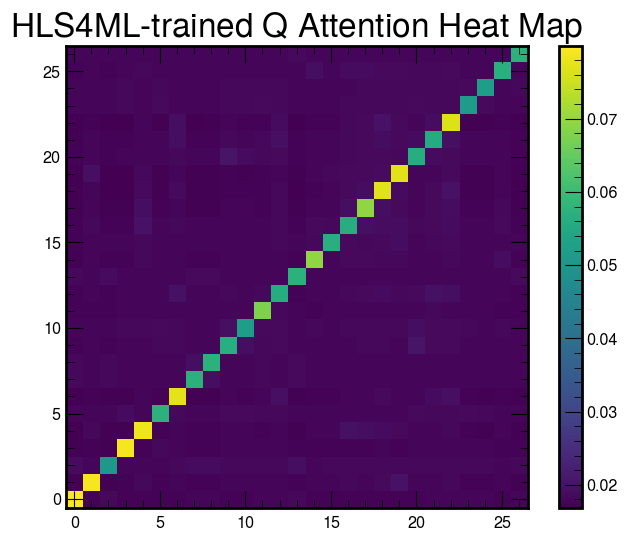

In [68]:
# Testing using init_model

# Plotting the attention matrix with the origin in the lower left
plt.figure(figsize=(8, 6))  # Adjust figure size as needed

# Visualizing a specific part of the attention matrix
plt.imshow(init_attention[7][7][4, 0:hls4ml_jet_num, 0:hls4ml_jet_num], origin='lower', cmap='viridis')

# Adding colorbar
plt.colorbar()

# Set the x and y ticks to integer values
plt.xticks(np.arange(0, hls4ml_jet_num, step=5))  # Set x-axis ticks as integers with step size of 5
plt.yticks(np.arange(0, hls4ml_jet_num, step=5))  # Same for y-axis
plt.title(r'HLS4ML-trained $Q$ Attention Heat Map', fontsize=24)

# Using LaTeX for the title in particle decay process format

# Show the plot
plt.show()


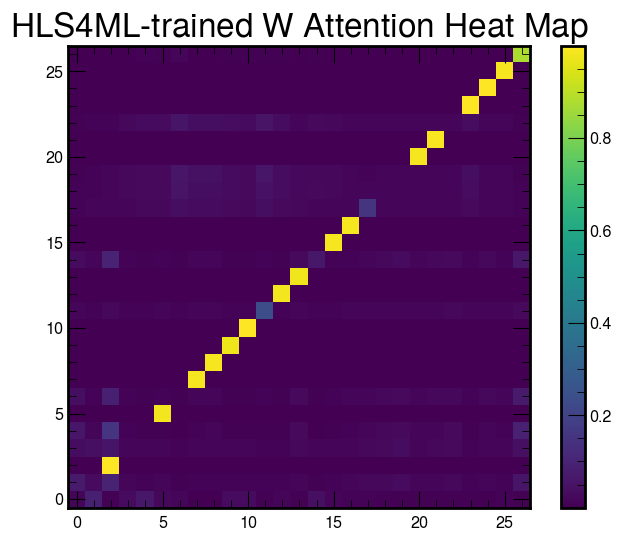

In [70]:
# Assuming the following variables are already defined
# Example dummy data for context:
# attention = np.random.rand(12, 128, 64, 64)  # A random tensor for illustration purposes
# num = 50  # You can replace this with your actual value

# Plotting the attention matrix with the origin in the lower left
plt.figure(figsize=(8, 6))  # Adjust figure size as needed

# Visualizing a specific part of the attention matrix
plt.imshow(hls4ml_attention[7][7][4, 0:hls4ml_jet_num, 0:hls4ml_jet_num], origin='lower', cmap='viridis')

# Adding colorbar
plt.colorbar()

# Set the x and y ticks to integer values
plt.xticks(np.arange(0, hls4ml_jet_num, step=5))  # Set x-axis ticks as integers with step size of 5
plt.yticks(np.arange(0, hls4ml_jet_num, step=5))  # Same for y-axis
plt.title(r'HLS4ML-trained $W$ Attention Heat Map', fontsize=24)

# Using LaTeX for the title in particle decay process format

# Save the plot to a file
#plt.savefig('hls4ml_heatmap_gluon_head.pdf', bbox_inches="tight")

# Show the plot
plt.show()


In [ ]:
interaction = model[0].get_interactionMatrix()


In [ ]:
interaction.shape

In [ ]:
interaction= np.reshape(interaction, (attention[0].shape))


In [ ]:
intstack = []
for x in range(8):
  intstack.append(interaction)

In [ ]:
intstack = np.stack(intstack)

In [ ]:
intstack = intstack.transpose(1,0,2,3,4)

In [ ]:
atstack = np.stack(attention).transpose(1,0,2,3,4)

In [ ]:
import numpy as np

epsilon = 1e-10
log_softmaxed_attn = np.log(atstack + 1e-10)


pre_attn_matrix= log_softmaxed_attn - intstack



In [ ]:
attentionOnly = pre_attn_matrix

In [ ]:
attentionOnly.shape

In [ ]:
jet = 9
head = 0
layer = 0

In [ ]:
number = jet
num = 0
for b in np.squeeze(pf_mask[number]):
    if b == 0:
        break
    num = num + 1

In [55]:
import os
import pickle as pkl
import matplotlib.pyplot as plt
import numpy as np
import torch
import fastjet


def get_subjets(px, py, pz, e, N_SUBJETS=3, JET_ALGO="kt", jet_radius=0.8):
    """
    Declusters a jet into exactly N_SUBJETS using the JET_ALGO and jet_radius provided.

    Args:
        px [np.ndarray]: NumPy array of shape ``[num_particles]`` containing the px of each particle inside the jet
        py [np.ndarray]: NumPy array of shape ``[num_particles]`` containing the py of each particle inside the jet
        pz [np.ndarray]: NumPy array of shape ``[num_particles]`` containing the pz of each particle inside the jet
        e [np.ndarray]: NumPy array of shape ``[num_particles]`` containing the e of each particle inside the jet
        N_SUBJETS [int]: Number of subjets to decluster the jet into
            (default is 3)
        JET_ALGO [str]: The jet declustering algorithm to use. Choices are ["CA", "kt", "antikt"]
            (default is "CA")
        jet_radius [float]: The jet radius to use when declustering
            (default is 0.8)

    Returns:
        subjet_idx [np.array]: NumPy array of shape ``[num_particles]`` with elements
                                representing which subjet the particle belongs to
        subjet_vectors [list]: includes bjet information (e.g. px, py, pz)

    """
    import awkward as ak
    import fastjet
    import vector

    if JET_ALGO == "kt":
        JET_ALGO = fastjet.kt_algorithm
    elif JET_ALGO == "antikt":
        JET_ALGO = fastjet.antikt_algorithm
    elif JET_ALGO == "CA":
        JET_ALGO = fastjet.cambridge_algorithm

    jetdef = fastjet.JetDefinition(JET_ALGO, jet_radius)

    # define jet directly not an array of jets
    jet = ak.zip(
        {
            "px": px,
            "py": py,
            "pz": pz,
            "E": e,
        },
        with_name="MomentumArray4D",
    )

    pseudojet = [
        fastjet.PseudoJet(particle.px.item(), particle.py.item(), particle.pz.item(), particle.E.item()) for particle in jet
    ]

    cluster = fastjet.ClusterSequence(pseudojet, jetdef)

    # cluster jets
    jets = cluster.inclusive_jets()
    print(len(jets))
    #assert len(jets) == 1

    # get the 3 exclusive jets
    subjets = cluster.exclusive_subjets(jets[0], N_SUBJETS)
    assert len(subjets) == N_SUBJETS

    # sort by pt
    subjets = sorted(subjets, key=lambda x: x.pt(), reverse=True)

    # define a subjet_idx placeholder
    subjet_idx = ak.zeros_like(px, dtype=int) - 1
    mapping = subjet_idx.to_list()

    subjet_indices = []
    for subjet_idx, subjet in enumerate(subjets):
        subjet_indices.append([])
        for subjet_const in subjet.constituents():
            for idx, jet_const in enumerate(pseudojet):
                if (
                    subjet_const.px() == jet_const.px()
                    and subjet_const.py() == jet_const.py()
                    and subjet_const.pz() == jet_const.pz()
                    and subjet_const.E() == jet_const.E()
                ):
                    subjet_indices[-1].append(idx)


    for subjet_idx, subjet in enumerate(subjets):
        local_mapping = np.array(mapping)
        local_mapping[subjet_indices[subjet_idx]] = subjet_idx
        mapping = local_mapping

    # add the jet index
    jet["subjet_idx"] = ak.Array(mapping)

    subjet_vectors = [
        vector.obj(
            px=ak.sum(jet.px[jet.subjet_idx == j], axis=-1),
            py=ak.sum(jet.py[jet.subjet_idx == j], axis=-1),
            pz=ak.sum(jet.pz[jet.subjet_idx == j], axis=-1),
            E=ak.sum(jet.E[jet.subjet_idx == j], axis=-1),
        )
        for j in range(0, N_SUBJETS)
    ]

    return jet["subjet_idx"].to_numpy(), subjet_vectors


def scaling_up(outpath, epoch, N_values=30, N_SUBJETS=3, JET_ALGO="CA", jet_radius=0.8):
    """
    Computes the distribution of edges connecting different subjets for different values of N.

    Args:
        outpath [str]: Path to load the Rscores pkl files
        epoch [int]: The epoch at which to load the model
            (if -1: best trained model, if 0: untrained model, otherwise loads the corresponding epoch)
        N_values [int]: The different values of N to scan, which will be taken as range(N_values)
            (default is 15)
        N_SUBJETS [int]: Number of subjets to decluster the jet into
            (default is 3)
        JET_ALGO [str]: The jet declustering algorithm to use. Choices are ["CA", "kt", "antikt"]
            (default is "CA")
        jet_radius [float]: The jet radius to use when declustering
            (default is 0.8)

    """

    # same: list of counters, for each N, of edges connecting the same subjet
    top_same, qcd_same = np.array([0] * N_values), np.array([0] * N_values)
    # diff: list of counters, for each N, of edges connecting different subjets
    top_diff, qcd_diff = np.array([0] * N_values), np.array([0] * N_values)

    if epoch == -1:
        PATH = f"{outpath}/Rscores_best"
        save_as = "best"
        legend_title = "Trained model"
    elif epoch == 0:
        PATH = f"{outpath}/Rscores_untrained"
        save_as = "untrained"
        legend_title = "Untrained model"
    else:
        PATH = f"{outpath}/Rscores_epoch_{epoch}"
        save_as = f"epoch_{epoch}"
        legend_title = f"Model at epoch {epoch}"

    # load the jet information
    with open(f"{PATH}/batch_y.pkl", "rb") as handle:
        batch_y_list = pkl.load(handle)
    with open(f"{PATH}/batch_p4.pkl", "rb") as handle:
        batch_p4_list = pkl.load(handle)

    # load the edgeRscores and edge_index of each EdgeConv block
    with open(f"{PATH}/R_edges.pkl", "rb") as handle:
        R_edges_list = pkl.load(handle)
    with open(f"{PATH}/edge_index.pkl", "rb") as handle:
        edge_index_list = pkl.load(handle)

    Num_jets = len(batch_p4_list)
    print(f"Total # of jets is {Num_jets}")
    for i in range(Num_jets):
        # define the jet information
        jet_label = batch_y_list[i]

        px = batch_p4_list[i][:, 0]
        py = batch_p4_list[i][:, 1]
        pz = batch_p4_list[i][:, 2]
        e = batch_p4_list[i][:, 3]

        # define the edgeRscores and the edge_index of the last EdgeConv block
        edge_Rscores = R_edges_list[i]["edge_conv_2"]
        edge_index = edge_index_list[i]["edge_conv_2"]

        # get subjets
        try:
            print(f"- Declustering jet # {i} using {JET_ALGO} algorithm")
            subjet_idx, _ = get_subjets(px, py, pz, e, N_SUBJETS, JET_ALGO, jet_radius)
        except AssertionError:
            print(f"skipping jet # {i}")
            continue

        for N in range(N_values):
            # N=0 doesn't make sense here
            for edge in torch.topk(edge_Rscores, N + 1).indices:
                if jet_label == 1:
                    if subjet_idx[edge_index[0][edge]] != subjet_idx[edge_index[1][edge]]:
                        top_diff[N] += 1
                    else:
                        top_same[N] += 1
                else:
                    if subjet_idx[edge_index[0][edge]] != subjet_idx[edge_index[1][edge]]:
                        qcd_diff[N] += 1
                    else:
                        qcd_same[N] += 1

    top_fraction = top_diff / (top_same + top_diff)
    qcd_fraction = qcd_diff / (qcd_same + qcd_diff)

    outpath = f"{outpath}/scaling_up"
    if not os.path.exists(outpath):
        os.makedirs(outpath)

    with open(f"{outpath}/top_fraction_{save_as}.pkl", "wb") as f:
        pkl.dump(top_fraction, f)
    with open(f"{outpath}/qcd_fraction_{save_as}.pkl", "wb") as f:
        pkl.dump(qcd_fraction, f)

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.plot(range(len(top_fraction)), top_fraction, label="Top")
    ax.plot(range(len(qcd_fraction)), qcd_fraction, label="QCD")
    ax.legend(title=legend_title)
    ax.set_xlabel(r"$N_{edges}$", fontsize=20)
    ax.set_ylabel(r"$N_{edges \ between \ subjets}$ / $N_{edges}$", fontsize=20)
    fig.tight_layout()
    plt.savefig(f"{outpath}/scaling_up_{save_as}.pdf")
    print(f"saved the plot as {outpath}/scaling_up_{save_as}.pdf")

In [32]:
qg_subjets = get_subjets(qg_pf_vectors[jet][0][0:qg_jet_num],qg_pf_vectors[jet][1][0:qg_jet_num], qg_pf_vectors[jet][2][0:qg_jet_num], qg_pf_vectors[jet][3][0:qg_jet_num], N_SUBJETS=2,  JET_ALGO="kt")

1#--------------------------------------------------------------------------
#                         FastJet release 3.4.1
#                 M. Cacciari, G.P. Salam and G. Soyez                  
#     A software package for jet finding and analysis at colliders      
#                           http://fastjet.fr                           
#	                                                                      
# Please cite EPJC72(2012)1896 [arXiv:1111.6097] if you use this package
# for scientific work and optionally PLB641(2006)57 [hep-ph/0512210].   
#                                                                       
# FastJet is provided without warranty under the GNU GPL v2 or higher.  
# It uses T. Chan's closest pair algorithm, S. Fortune's Voronoi code,
# CGAL and 3rd party plugin jet algorithms. See COPYING file for details.
#--------------------------------------------------------------------------



In [33]:
labels[6]

NameError: name 'labels' is not defined

In [ ]:

jet = 4
number = jet
num = 0
for b in np.squeeze(pf_mask[number]):
    if b == 0:
        break
    num = num + 1

In [ ]:
deta = pf_features[jet][15][0:num]
dphi = pf_features[jet][16][0:num]
pt = pf_features[jet][0][0:num]

In [ ]:
deta = pf_features[jet][15][0:num]
dphi = pf_features[jet][16][0:num]
pt = pf_features[jet][0][0:num]
detaCH = []
detaNH = []
detaMuon = []
detaElectron = []
detaPhoton = []
dphiCH = []
dphiNH = []
dphiMuon = []
dphiElectron = []
dphiPhoton = []
ptCH = []
ptNH = []
ptPhoton = []
ptMuon = []
ptElectron = []
for particle in range(len(deta)):
    if pf_features[jet][6][particle] == 1:
        detaCH.append(pf_features[jet][15][particle])
        dphiCH.append(pf_features[jet][16][particle])
        ptCH.append(pf_features[jet][0][particle])
    elif pf_features[jet][7][particle] == 1:
        detaNH.append(pf_features[jet][15][particle])
        dphiNH.append(pf_features[jet][16][particle])
        ptNH.append(pf_features[jet][0][particle])

    elif pf_features[jet][8][particle] == 1:
        detaPhoton.append(pf_features[jet][15][particle])
        dphiPhoton.append(pf_features[jet][16][particle])
        ptPhoton.append(pf_features[jet][0][particle])
    elif pf_features[jet][9][particle] == 1:
        detaElectron.append(pf_features[jet][15][particle])
        dphiElectron.append(pf_features[jet][16][particle])
        ptElectron.append(pf_features[jet][0][particle])

    elif pf_features[jet][10][particle] == 1:
        detaMuon.append(pf_features[jet][15][particle])
        dphiMuon.append(pf_features[jet][16][particle])

        ptMuon.append(pf_features[jet][0][particle])


In [ ]:
attention[0].shape

In [ ]:
attention[x][jet][:,0:num,0:num].shape

In [ ]:
attention[x][jet][:][0:num,0:num].shape

In [ ]:
attentionOnly.shape

In [ ]:
attentionOnly = np.transpose(attentionOnly,[1,0,2,3,4])

In [ ]:
attentionOnly.shape

In [19]:
import scipy

In [ ]:
correlation = []
for indexed in range(8):
  correlation.append(scipy.stats.pearsonr(attention[0][jet][:,0:num,0:num][indexed].flatten(), attentionOnly[0][jet][:,0:num,0:num][indexed].flatten()))


In [ ]:
correlation

In [56]:
CMS = {
    # "font.sans-serif": ["TeX Gyre Heros", "Helvetica", "Arial"],
    "font.family": "sans-serif",
    "mathtext.fontset": "custom",
    "mathtext.rm": "TeX Gyre Heros",
    "mathtext.bf": "TeX Gyre Heros:bold",
    "mathtext.sf": "TeX Gyre Heros",
    "mathtext.it": "TeX Gyre Heros:italic",
    "mathtext.tt": "TeX Gyre Heros",
    "mathtext.cal": "TeX Gyre Heros",
    "mathtext.default": "regular",
    "figure.figsize": (8.0, 8.0),
    "font.size": 14,
    #"text.usetex": True,
    "axes.labelsize": "medium",
    "axes.unicode_minus": False,
    "xtick.labelsize": "small",
    "ytick.labelsize": "small",
    # Make legends smaller
    "legend.fontsize": "x-small",  # Adjusted to a smaller size
    "legend.handlelength": 1.5,
    "legend.borderpad": 0.5,
    "xtick.direction": "in",
    "xtick.major.size": 12,
    "xtick.minor.size": 6,
    "xtick.major.pad": 6,
    "xtick.top": True,
    "xtick.major.top": True,
    "xtick.major.bottom": True,
    "xtick.minor.top": True,
    "xtick.minor.bottom": True,
    "xtick.minor.visible": True,
    "ytick.direction": "in",
    "ytick.major.size": 12,
    "ytick.minor.size": 6.0,
    "ytick.right": True,
    "ytick.major.left": True,
    "ytick.major.right": True,
    "ytick.minor.left": True,
    "ytick.minor.right": True,
    "ytick.minor.visible": True,
    "grid.alpha": 0.8,
    "grid.linestyle": ":",
    "axes.linewidth": 2,
    "savefig.transparent": False,
}
plt.style.use(CMS)


In [ ]:
random_matrix = np.random.rand(2, 2, 8, 128,128)


In [ ]:
from scipy.special import softmax

srandom_matrix = softmax(random_matrix, axis = 4)

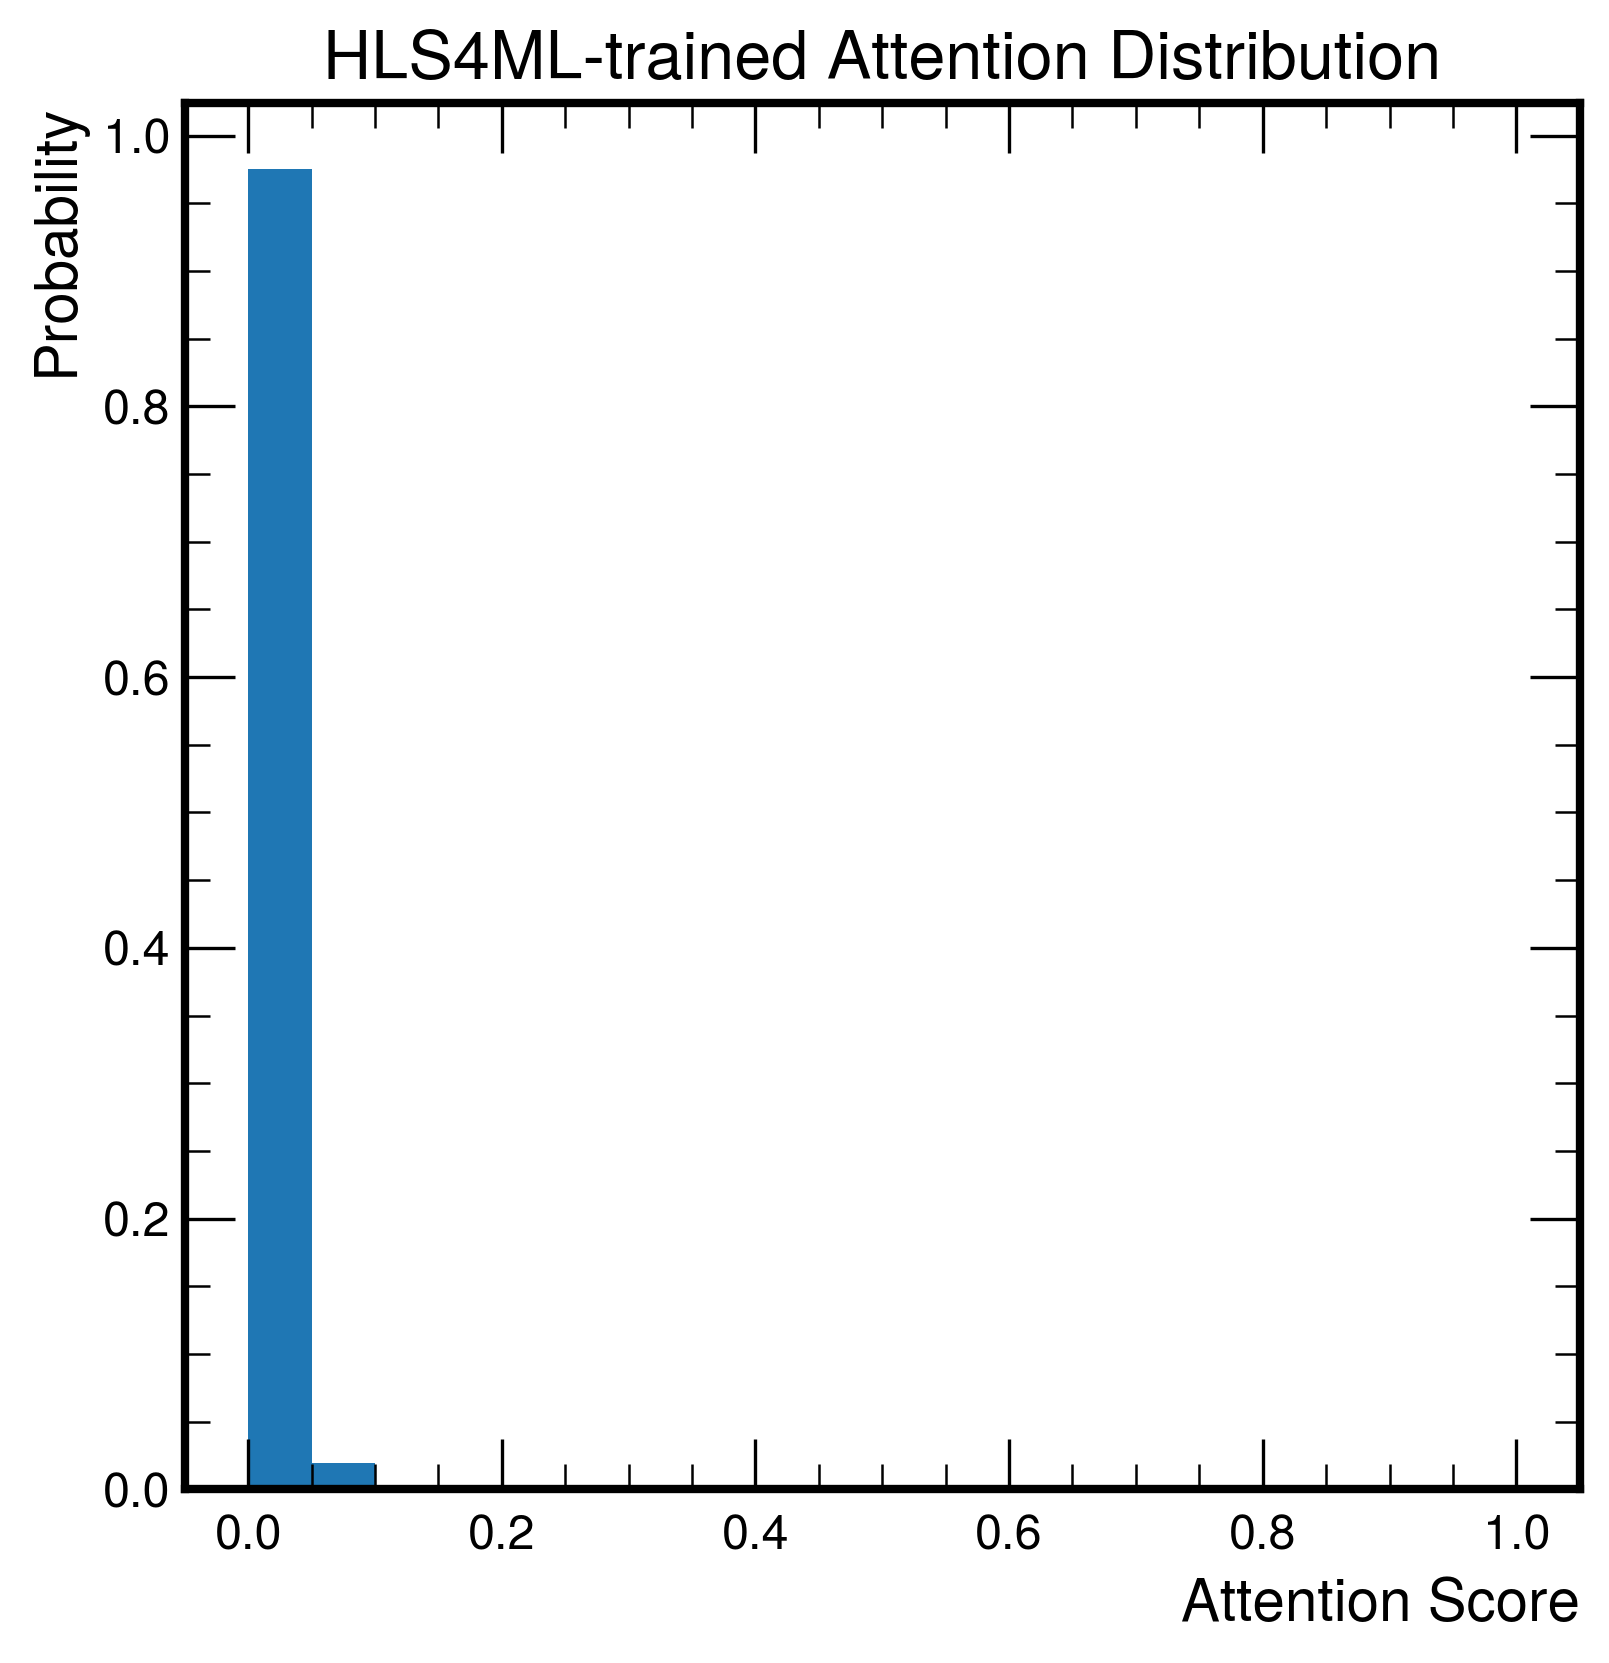

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#running for qg-trained model first

# Assuming attention is already a list or array
# Flattening the attention array
flattened_attention = np.stack(hls4ml_attention).flatten()

# Define number of bins for the probability distribution
num_bins = 20

# Define the bin edges between 0 and 1, using 20 evenly spaced bins
bin_edges = np.linspace(0, 1, num_bins + 1)

# Function to process data in chunks and compute histogram
def process_in_chunks(attention_iterator, chunk_size=10000, bin_edges=bin_edges):
    hist_counts = np.zeros(len(bin_edges) - 1)  # Initialize histogram counts for bins

    # Process each chunk of attention data
    for chunk in attention_iterator:
        # Flatten the chunk to ensure it's 1D and processable by np.histogram
        chunk = np.array(chunk).flatten()

        # Calculate histogram for this chunk
        hist, _ = np.histogram(chunk, bins=bin_edges)

        # Accumulate the counts
        hist_counts += hist

    total_data_points = hist_counts.sum()  # Total number of points processed
    probabilities = hist_counts / total_data_points  # Normalize to get probabilities
    return probabilities

# Simulate loading a large dataset in chunks (e.g., from a file or other source)
def attention_generator(attention, chunk_size):
    """Simulate chunked data loader for large dataset."""
    for i in range(0, len(attention), chunk_size):
        yield attention[i:i + chunk_size]

# Process the data in chunks (using a generator)
probabilities = process_in_chunks(attention_generator(flattened_attention, chunk_size=100000))

# Manually set the bin centers to have equal bar spacing
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # Calculate the centers of each bin
equal_width = bin_edges[1] - bin_edges[0]  # Set equal width for all bars based on bin spacing

# Create figure and axes
fig, ax = plt.subplots(figsize=(6, 6), dpi=300)

# Plot bar graph with equal-width bars
ax.bar(bin_centers, probabilities, width=equal_width, log=False)  # No log scale for clearer visualization

# Set custom x-tick locations and labels (optional)
#ax.set_xticks(bin_centers, 0.1)
#ax.set_xticklabels([f'{edge:.2f}' for edge in bin_centers], fontsize=10, fontweight='bold')

# Set x and y axis labels
ax.set_xlabel('Attention Score', fontsize=14)
ax.set_ylabel('Probability', fontsize=14)
plt.yscale('log')

# Add a title
ax.set_title('HLS4ML-trained Attention Distribution', fontsize=16)
#plt.savefig('HLS4ML_attentionDist.pdf', bbox_inches="tight")

# Show the plot
plt.show()


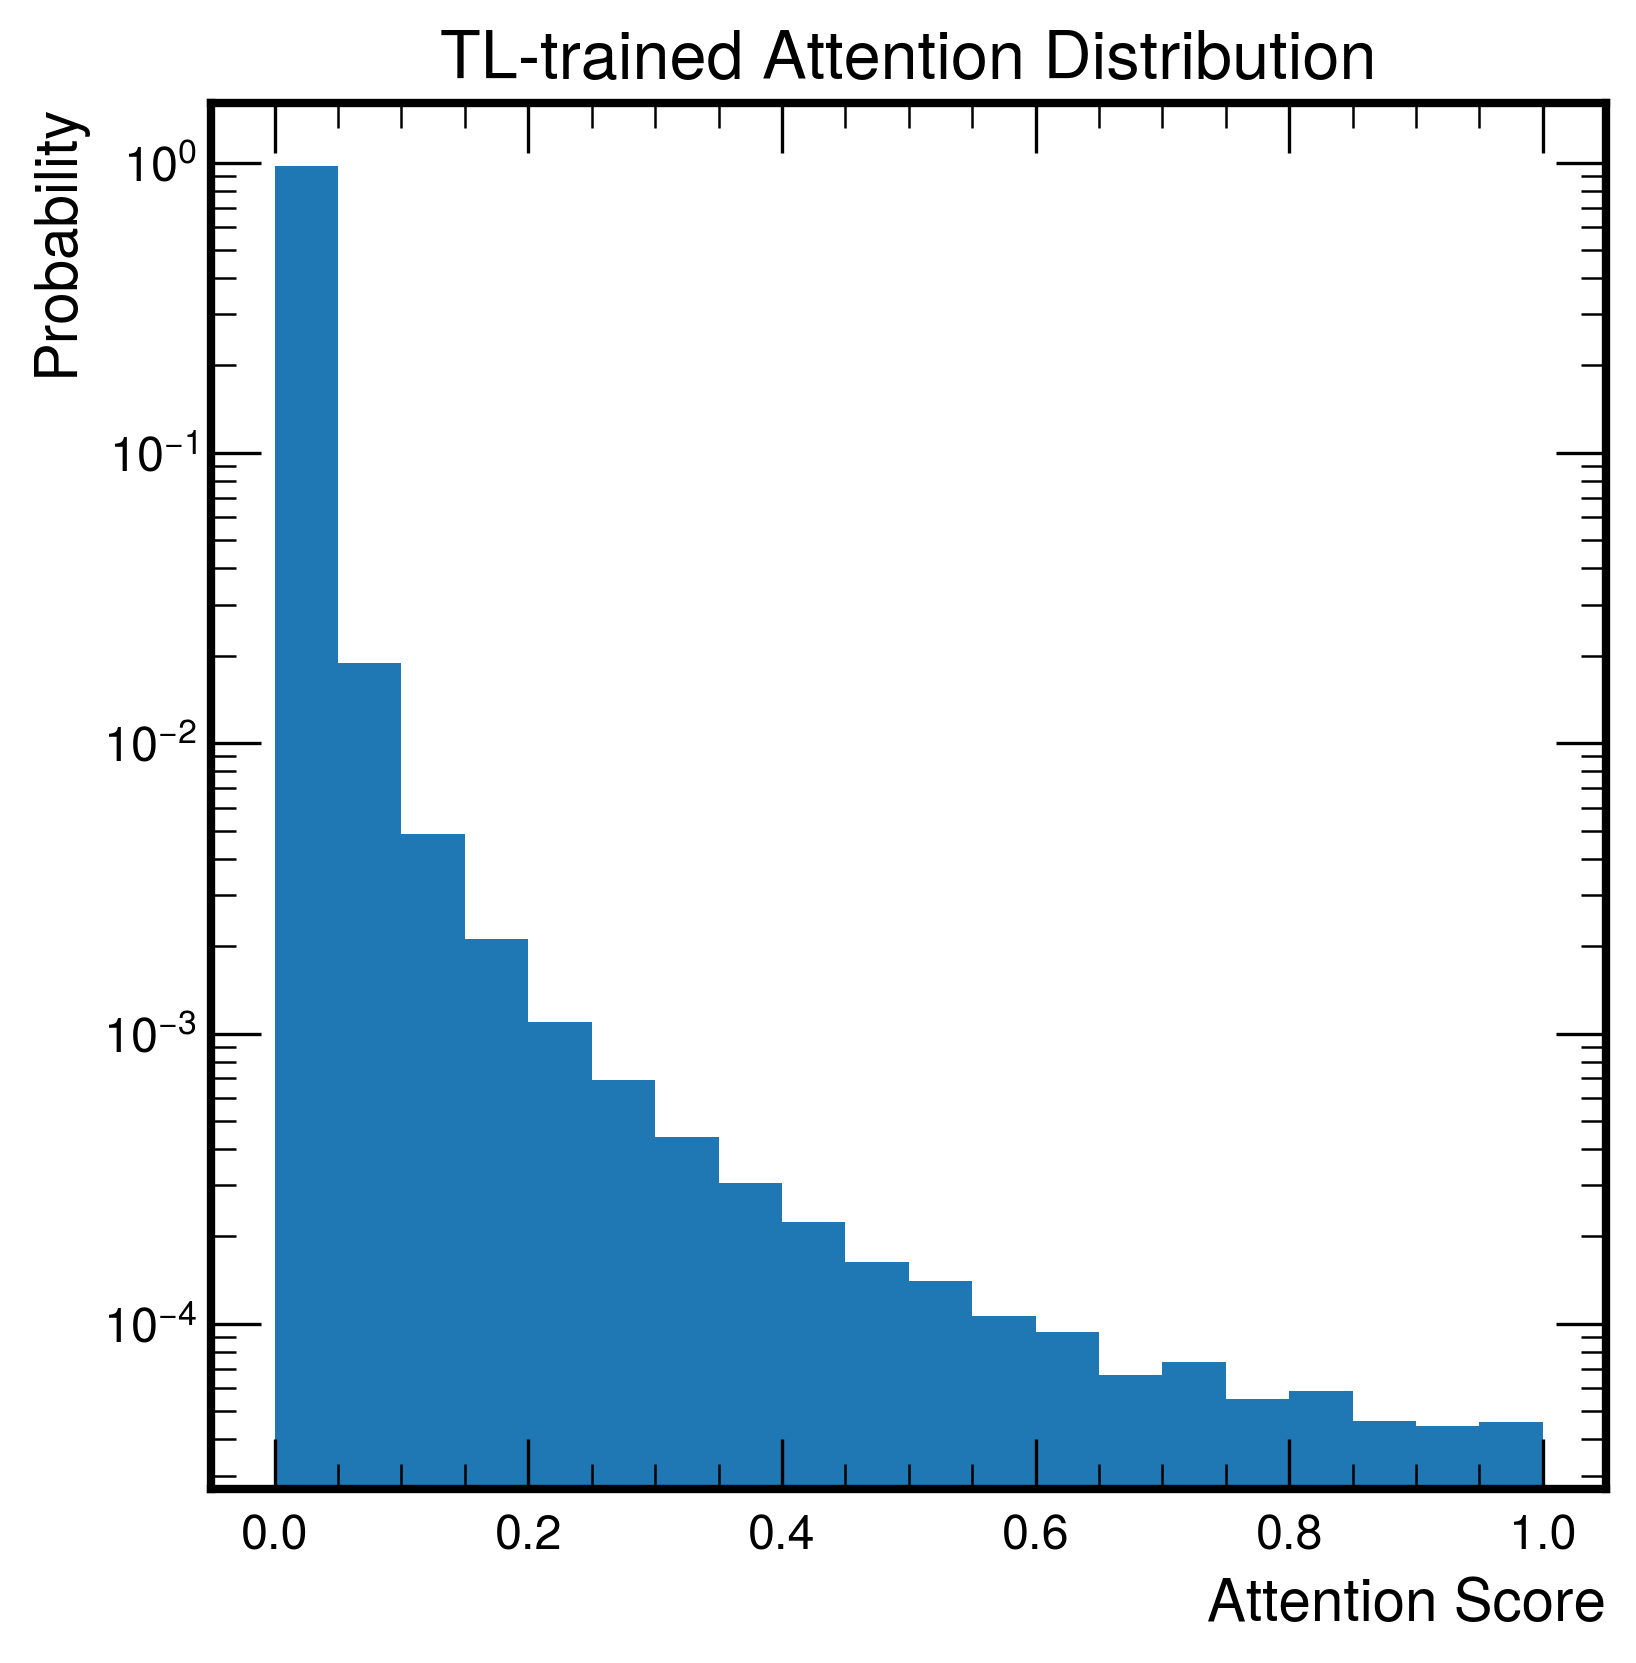

In [27]:
import numpy as np
import matplotlib.pyplot as plt

#running for tl-trained model second

# Assuming attention is already a list or array
# Flattening the attention array
flattened_attention = np.stack(tl_attention).flatten()

# Define number of bins for the probability distribution
num_bins = 20

# Define the bin edges between 0 and 1, using 20 evenly spaced bins
bin_edges = np.linspace(0, 1, num_bins + 1)


# Process the data in chunks (using a generator)
probabilities = process_in_chunks(attention_generator(flattened_attention, chunk_size=100000))

# Manually set the bin centers to have equal bar spacing
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # Calculate the centers of each bin
equal_width = bin_edges[1] - bin_edges[0]  # Set equal width for all bars based on bin spacing

# Create figure and axes
fig, ax = plt.subplots(figsize=(6, 6), dpi=300)

# Plot bar graph with equal-width bars
ax.bar(bin_centers, probabilities, width=equal_width, log=False)  # No log scale for clearer visualization

# Set custom x-tick locations and labels (optional)
#ax.set_xticks(bin_centers, 0.1)
#ax.set_xticklabels([f'{edge:.2f}' for edge in bin_centers], fontsize=10, fontweight='bold')

# Set x and y axis labels
ax.set_xlabel('Attention Score', fontsize=14)
ax.set_ylabel('Probability', fontsize=14)
plt.yscale('log')

# Add a title
ax.set_title('TL-trained Attention Distribution', fontsize=16)
plt.savefig('TL_attentionDist_8172025.pdf', bbox_inches="tight")

# Show the plot
plt.show()


In [ ]:
jet = 19

In [28]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colorbar import ColorbarBase
from matplotlib.cm import ScalarMappable

# Define a function to plot the particles and attention lines
def plot_attention_with_particles(attention_head, jet, deta_all, dphi_all, pt_all, subjets_all, layer_number, head_number, pf_features, output_filename):

    # Normalize pt values for alpha transparency
    print("Normalizing pt values...")
    norm_pt = mcolors.Normalize(vmin=pt_all.min(), vmax=pt_all.max())

    # Identify the lowest Pt subjet
    unique_subjets = np.unique(subjets_all)
    print(f"Unique subjets: {unique_subjets}")
    lowest_pt_subjet = min(np.unique(subjets_all), key=lambda s: np.sum(pt_all[subjets_all == s]))
    print(f"Lowest Pt subjet: {lowest_pt_subjet}")

    # Use a bright colormap
    colormap = plt.get_cmap('spring')

    # Normalize attention for line transparency/width
    print("Normalizing attention values...")
    norm_attention = mcolors.Normalize(vmin=attention_head.min(), vmax=attention_head.max())


    # Set figure size and DPI for faster rendering
    print("Setting up figure...")
    fig, ax = plt.subplots(figsize=(8, 6), dpi=300)  # Increase DPI for better rendering

    # Preprocess data to plot particles in batches based on their properties
    print("Categorizing particles...")
    particle_groups = {
        'charged_hadron': {'deta': [], 'dphi': [], 'pt': [], 'color': [], 'alpha': [], 'marker': '^'},
        'neutral_hadron': {'deta': [], 'dphi': [], 'pt': [], 'color': [], 'alpha': [], 'marker': 'v'},
        'photon': {'deta': [], 'dphi': [], 'pt': [], 'color': [], 'alpha': [], 'marker': 'o'},
        'electron': {'deta': [], 'dphi': [], 'pt': [], 'color': [], 'alpha': [], 'marker': 'P'},
        'muon': {'deta': [], 'dphi': [], 'pt': [], 'color': [], 'alpha': [], 'marker': 'X'},
        'default': {'deta': [], 'dphi': [], 'pt': [], 'color': [], 'alpha': [], 'marker': 'o'}
    }

    for i in range(len(deta_all)):
        # Alpha transparency based on pt with a minimum of 0.5 and scaling with normalized pt
        alpha = max(0.5, norm_pt(pt_all[i]))
#if subjets_all[i] == lowest_pt_subjet:
        #else:
        other_subjet_idx = np.where(unique_subjets == subjets_all[i])[0][0]
        color = colormap(other_subjet_idx / len(unique_subjets) * 0.7)  # Bright colors

        # Determine the marker based on the particle type in pf_features
        if pf_features[jet][6][i] == 1:  # Charged Hadron
            group = 'charged_hadron'
        elif pf_features[jet][7][i] == 1:  # Neutral Hadron
            group = 'neutral_hadron'
        elif pf_features[jet][8][i] == 1:  # Photon
            group = 'photon'
        elif pf_features[jet][9][i] == 1:  # Electron
            group = 'electron'
        elif pf_features[jet][10][i] == 1:  # Muon
            group = 'muon'
        else:
            group = 'default'

        # Store the particle data in the appropriate group for batch plotting
        particle_groups[group]['deta'].append(deta_all[i])
        particle_groups[group]['dphi'].append(dphi_all[i])
        particle_groups[group]['color'].append(color)
        particle_groups[group]['alpha'].append(alpha)

    print("Plotting particles...")
    # Batch plot particles for each group
    for group, data in particle_groups.items():
        if data['deta']:  # Only plot if there are particles in this group
            # Apply alpha transparency as an array for each particle
            ax.scatter(data['deta'], data['dphi'], color=data['color'], alpha=data['alpha'], s=250, zorder=3, marker=data['marker'],
                       edgecolors='black', linewidths=1.5, antialiased=False)  # Disable anti-aliasing for speed

    # Plot attention lines between particles with values above 0.9
    print("Plotting attention lines...")
    for i in range(attention_head.shape[0]):
        for j in range(attention_head.shape[1]):
            if i != j:  # No self-loops
                # Attention value between particles i and j
                attn_value = attention_head[i, j]
                linestyle = ''
                lineValue=1
                if attn_value > 0:  # Only plot lines for attention values >= 0.9
                    alpha = norm_attention(attn_value)  # Transparency based on attention
                    lineValue = 1
                    # Solid lines within the same subjet, dashed between different subjets
                    linestyle = ''
                    if subjets_all[i] == subjets_all[j]:
                        linestyle = 'solid'
                        lineValue = 1
                    else:
                        linestyle = 'dotted'
                        linestyle = (0, (2, 2))
                        lineValue = 1.3

                    # Plot lines
                    ax.plot([deta_all[i], deta_all[j]], [dphi_all[i], dphi_all[j]], color='black',
                            alpha=alpha, linewidth=lineValue * alpha, linestyle=linestyle, antialiased=False)  # Disable anti-aliasing for speed

    print("Adding legends...")

    # Add the subjet legend without Pt values
    legend1 = ax.legend(handles=[
        plt.Line2D([0], [0], marker='o', color='w', label=f'Subjet {int(subjet)}', markerfacecolor=colormap(subjet / len(unique_subjets) * 0.7), markersize=10)
        for subjet in unique_subjets
    ], loc='upper right', title="Subjets")

    # Add the particle shape legend
    #legend2 = ax.legend(handles=[
    #    plt.Line2D([0], [0], marker=group['marker'], color='w', label=label, markerfacecolor='black', markersize=10)
    #    for label, group in zip(['Charged Hadron', 'Neutral Hadron', 'Photon', 'Electron', 'Muon'], particle_groups.values())
    #], loc='lower right', title="Particle Shapes")

    # Add all legends to the plot
    ax.add_artist(legend1)
    #ax.add_artist(legend2)

    # Set axis labels without bold styling
    ax.set_xlabel(r'$\Delta \eta$')
    ax.set_ylabel(r'$\Delta \phi$')

    # Add title with layer and head information
    #ax.set_title(f'Layer {layer_number + 1} - Head {head_number + 1}')
    ax.set_title('Untrained Model')

    #ax.set_xlim(-0.4, 0.7)
    #ax.set_xticks(np.arange(-0.4, 0.7, 0.2))

    # Add a colorbar for the attention weights at the bottom
    #cbar_ax = fig.add_axes([0.15, -0.03, 0.7, 0.03])  # Add a colorbar axis below the plot
    cmap = plt.cm.gray_r  # Use a gray colormap to represent attention weights
    vmin=attention_head.min()
    vmax=attention_head.max()
    norm = plt.Normalize(vmin=attention_head.min(), vmax=attention_head.max())  # Normalize based on attention values
    #cb = ColorbarBase(cbar_ax, cmap=cmap, norm=norm)
    cb = plt.colorbar(ScalarMappable(norm=norm, cmap=cmap))
    cb.set_label('Attention Weight')

    # Save the figure instead of showing it
    print(f"Saving figure to {output_filename}...")
    #plt.savefig(output_filename, bbox_inches='tight')
    print("Figure saved.")

def tl_plot_attention_with_particles(attention_head, jet, deta_all, dphi_all, pt_all, subjets_all, layer_number, head_number, pf_features, output_filename):

    # Normalize pt values for alpha transparency
    print("Normalizing pt values...")
    norm_pt = mcolors.Normalize(vmin=pt_all.min(), vmax=pt_all.max())

    # Identify the lowest Pt subjet
    unique_subjets = np.unique(subjets_all)
    print(f"Unique subjets: {unique_subjets}")
    lowest_pt_subjet = min(np.unique(subjets_all), key=lambda s: np.sum(pt_all[subjets_all == s]))
    print(f"Lowest Pt subjet: {lowest_pt_subjet}")

    # Use a bright colormap
    colormap = plt.get_cmap('spring')

    # Normalize attention for line transparency/width
    print("Normalizing attention values...")
    norm_attention = mcolors.Normalize(vmin=attention_head.min(), vmax=attention_head.max())


    # Set figure size and DPI for faster rendering
    print("Setting up figure...")
    fig, ax = plt.subplots(figsize=(8, 6), dpi=300)  # Increase DPI for better rendering

    # Preprocess data to plot particles in batches based on their properties
    print("Categorizing particles...")
    particle_groups = {
        'charged_hadron': {'deta': [], 'dphi': [], 'pt': [], 'color': [], 'alpha': [], 'marker': '^'},
        'neutral_hadron': {'deta': [], 'dphi': [], 'pt': [], 'color': [], 'alpha': [], 'marker': 'v'},
        'photon': {'deta': [], 'dphi': [], 'pt': [], 'color': [], 'alpha': [], 'marker': 'o'},
        'electron': {'deta': [], 'dphi': [], 'pt': [], 'color': [], 'alpha': [], 'marker': 'P'},
        'muon': {'deta': [], 'dphi': [], 'pt': [], 'color': [], 'alpha': [], 'marker': 'X'},
        'default': {'deta': [], 'dphi': [], 'pt': [], 'color': [], 'alpha': [], 'marker': 'o'}
    }

    for i in range(len(deta_all)):
        # Alpha transparency based on pt with a minimum of 0.5 and scaling with normalized pt
        alpha = max(0.5, norm_pt(pt_all[i]))
#if subjets_all[i] == lowest_pt_subjet:
        #else:
        other_subjet_idx = np.where(unique_subjets == subjets_all[i])[0][0]
        color = colormap(other_subjet_idx / len(unique_subjets) * 0.7)  # Bright colors

        group = 'default' # TopLandscape does not include Particle ID features, so we use a default group

        # Store the particle data in the appropriate group for batch plotting
        particle_groups[group]['deta'].append(deta_all[i])
        particle_groups[group]['dphi'].append(dphi_all[i])
        particle_groups[group]['color'].append(color)
        particle_groups[group]['alpha'].append(alpha)

    print("Plotting particles...")
    # Batch plot particles for each group
    for group, data in particle_groups.items():
        if data['deta']:  # Only plot if there are particles in this group
            # Apply alpha transparency as an array for each particle
            ax.scatter(data['deta'], data['dphi'], color=data['color'], alpha=data['alpha'], s=250, zorder=3, marker=data['marker'],
                       edgecolors='black', linewidths=1.5, antialiased=False)  # Disable anti-aliasing for speed

    # Plot attention lines between particles with values above 0.9
    print("Plotting attention lines...")
    for i in range(attention_head.shape[0]):
        for j in range(attention_head.shape[1]):
            if i != j:  # No self-loops
                # Attention value between particles i and j
                attn_value = attention_head[i, j]
                linestyle = ''
                lineValue=1
                if attn_value > 0:  # Only plot lines for attention values >= 0.9
                    alpha = norm_attention(attn_value)  # Transparency based on attention
                    lineValue = 1
                    # Solid lines within the same subjet, dashed between different subjets
                    linestyle = ''
                    if subjets_all[i] == subjets_all[j]:
                        linestyle = 'solid'
                        lineValue = 1
                    else:
                        linestyle = 'dotted'
                        linestyle = (0, (2, 2))
                        lineValue = 1.3

                    # Plot lines
                    ax.plot([deta_all[i], deta_all[j]], [dphi_all[i], dphi_all[j]], color='black',
                            alpha=alpha, linewidth=lineValue * alpha, linestyle=linestyle, antialiased=False)  # Disable anti-aliasing for speed

    print("Adding legends...")

    # Add the subjet legend without Pt values
    legend1 = ax.legend(handles=[
        plt.Line2D([0], [0], marker='o', color='w', label=f'Subjet {int(subjet)}', markerfacecolor=colormap(subjet / len(unique_subjets) * 0.7), markersize=10)
        for subjet in unique_subjets
    ], loc='upper right', title="Subjets")

    # Add all legends to the plot
    ax.add_artist(legend1)

    # Set axis labels without bold styling
    ax.set_xlabel(r'$\Delta \eta$')
    ax.set_ylabel(r'$\Delta \phi$')

    # Add title with layer and head information
    ax.set_title(f'Layer {layer_number + 1} - Head {head_number + 1}')
    #ax.set_title('Untrained Model')

    #ax.set_xlim(-0.4, 0.7)
    #ax.set_xticks(np.arange(-0.4, 0.7, 0.2))

    # Add a colorbar for the attention weights at the bottom
    #cbar_ax = fig.add_axes([0.15, -0.03, 0.7, 0.03])  # Add a colorbar axis below the plot
    cmap = plt.cm.gray_r  # Use a gray colormap to represent attention weights
    vmin=attention_head.min()
    vmax=attention_head.max()
    norm = plt.Normalize(vmin=attention_head.min(), vmax=attention_head.max())  # Normalize based on attention values
    #cb = ColorbarBase(cbar_ax, cmap=cmap, norm=norm)
    cb = plt.colorbar(ScalarMappable(norm=norm, cmap=cmap))
    cb.set_label('Attention Weight')

    # Save the figure instead of showing it
    print(f"Saving figure to {output_filename}...")
    plt.savefig(output_filename, bbox_inches='tight')
    print("Figure saved.")

1
Normalizing pt values...
Unique subjets: [0 1 2]
Lowest Pt subjet: 2
Normalizing attention values...
Setting up figure...
Categorizing particles...
Plotting particles...
Plotting attention lines...
Adding legends...
Saving figure to Jet0Tbqq/Tbqq-layer8-head18172025.pdf...
Figure saved.
Normalizing pt values...
Unique subjets: [0 1 2]
Lowest Pt subjet: 2
Normalizing attention values...
Setting up figure...
Categorizing particles...
Plotting particles...
Plotting attention lines...
Adding legends...
Saving figure to Jet0Tbqq/Tbqq-layer8-head28172025.pdf...
Figure saved.
Normalizing pt values...
Unique subjets: [0 1 2]
Lowest Pt subjet: 2
Normalizing attention values...
Setting up figure...
Categorizing particles...
Plotting particles...
Plotting attention lines...
Adding legends...
Saving figure to Jet0Tbqq/Tbqq-layer8-head38172025.pdf...
Figure saved.
Normalizing pt values...
Unique subjets: [0 1 2]
Lowest Pt subjet: 2
Normalizing attention values...
Setting up figure...
Categorizing

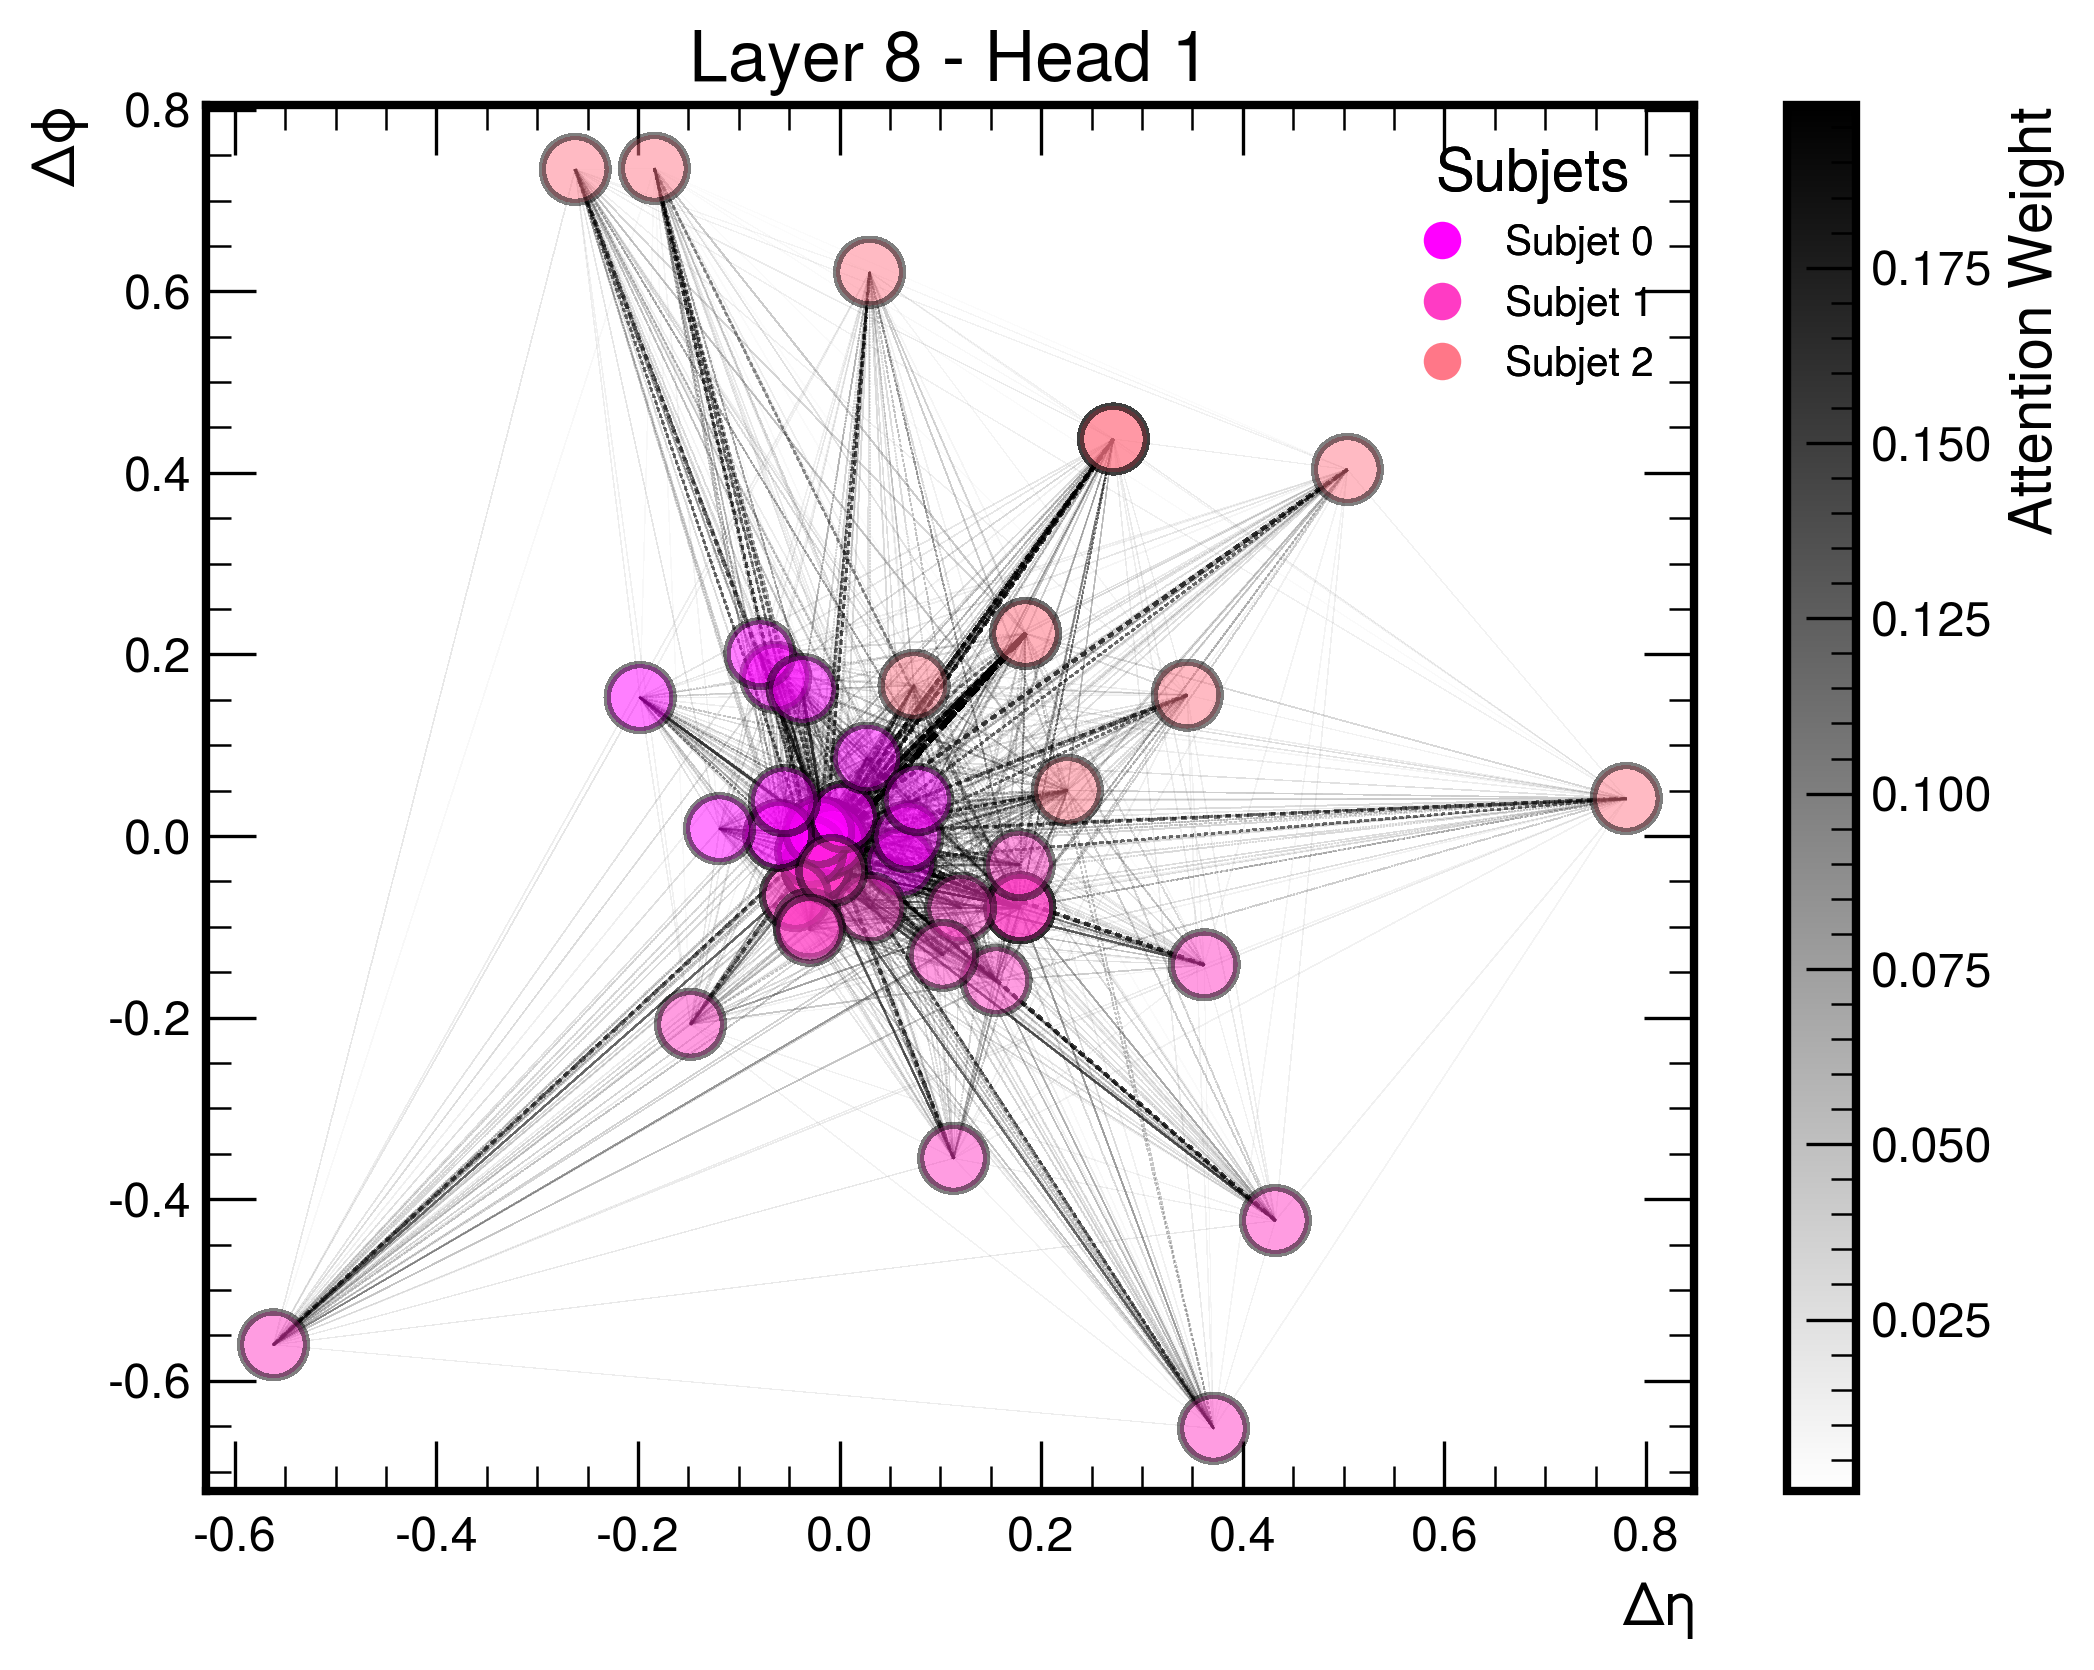

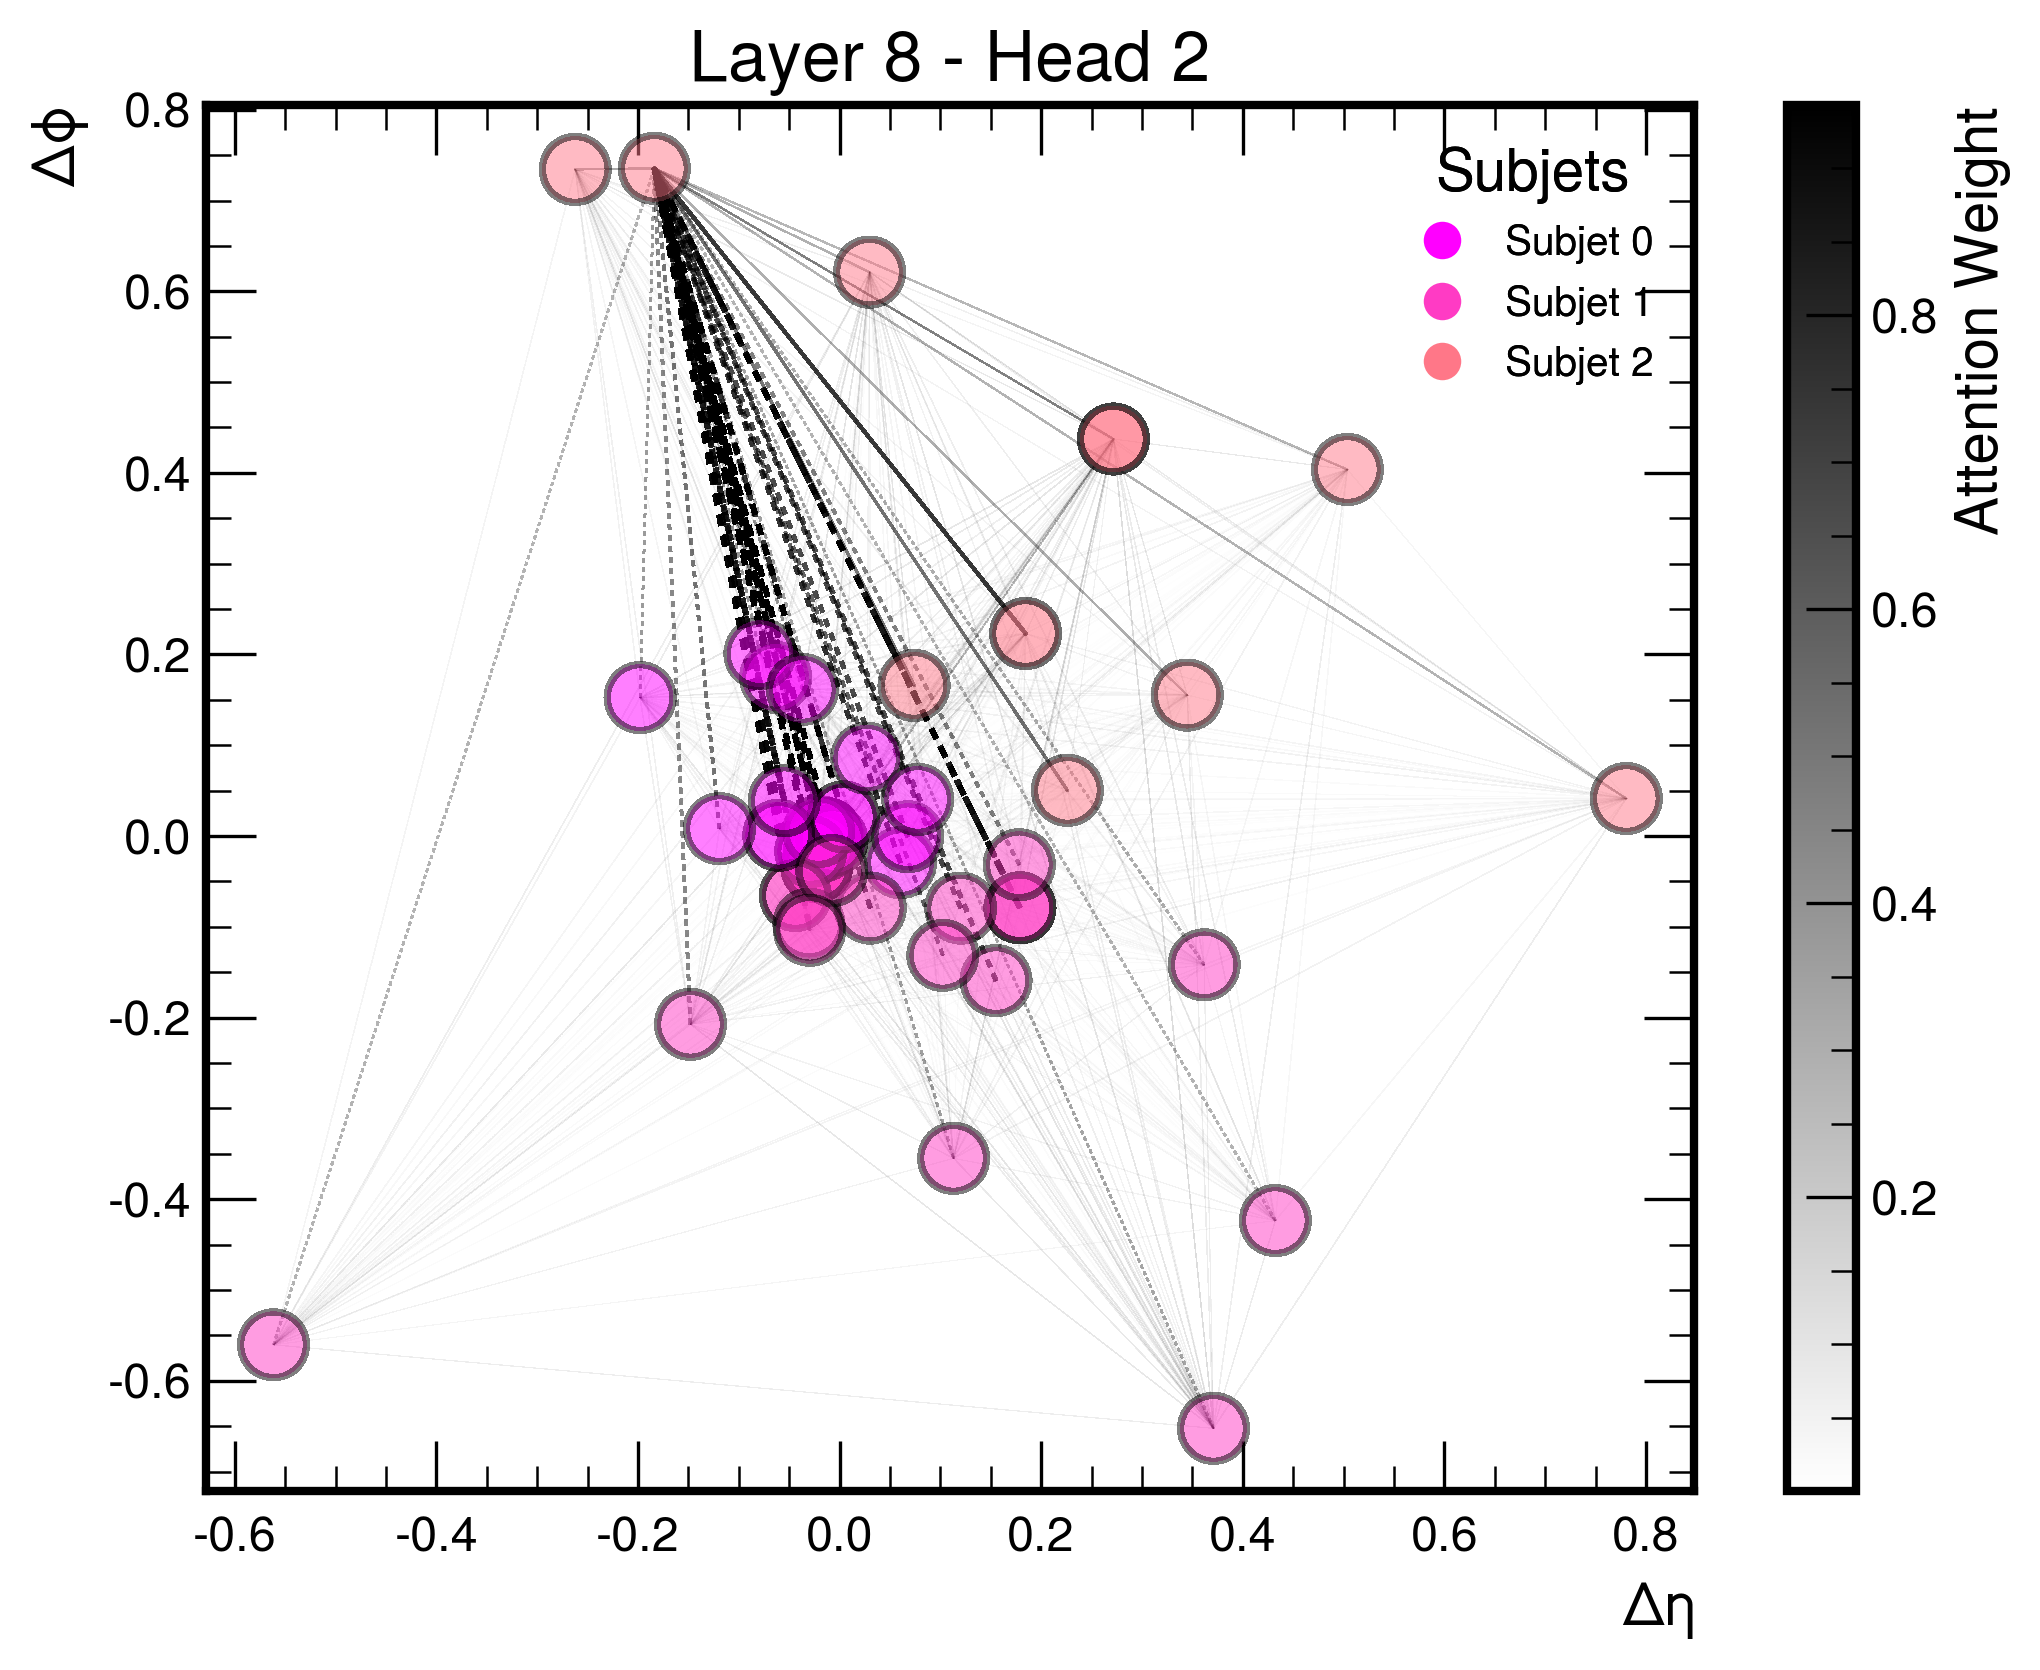

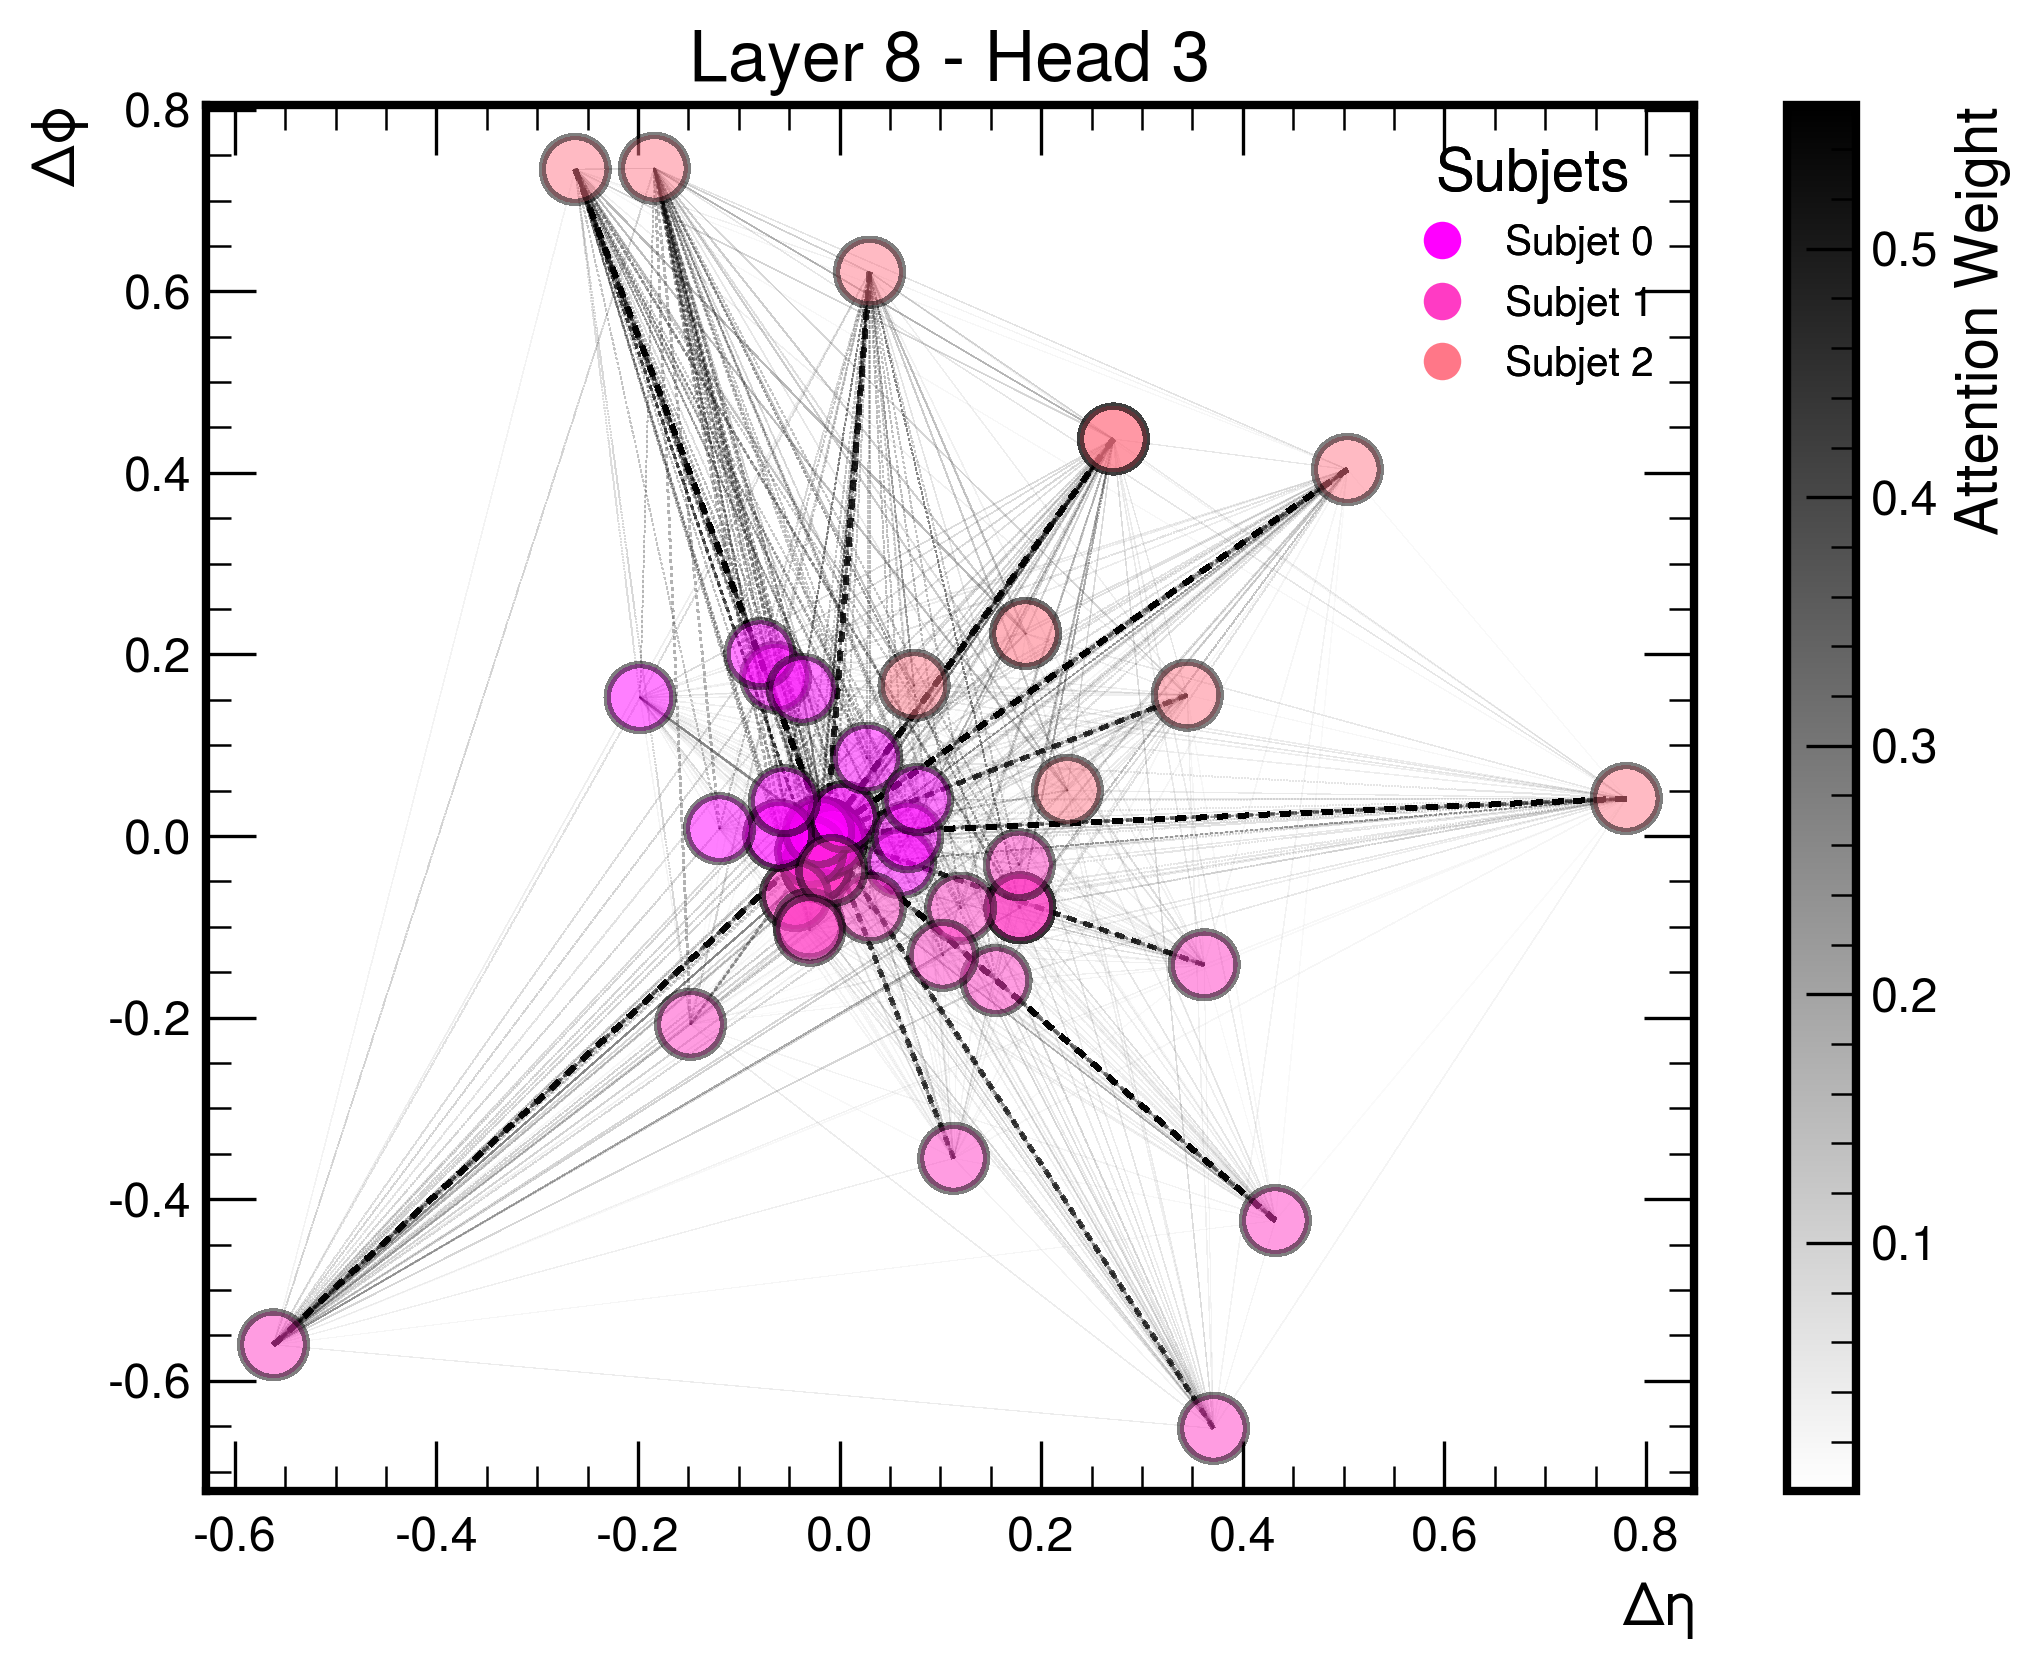

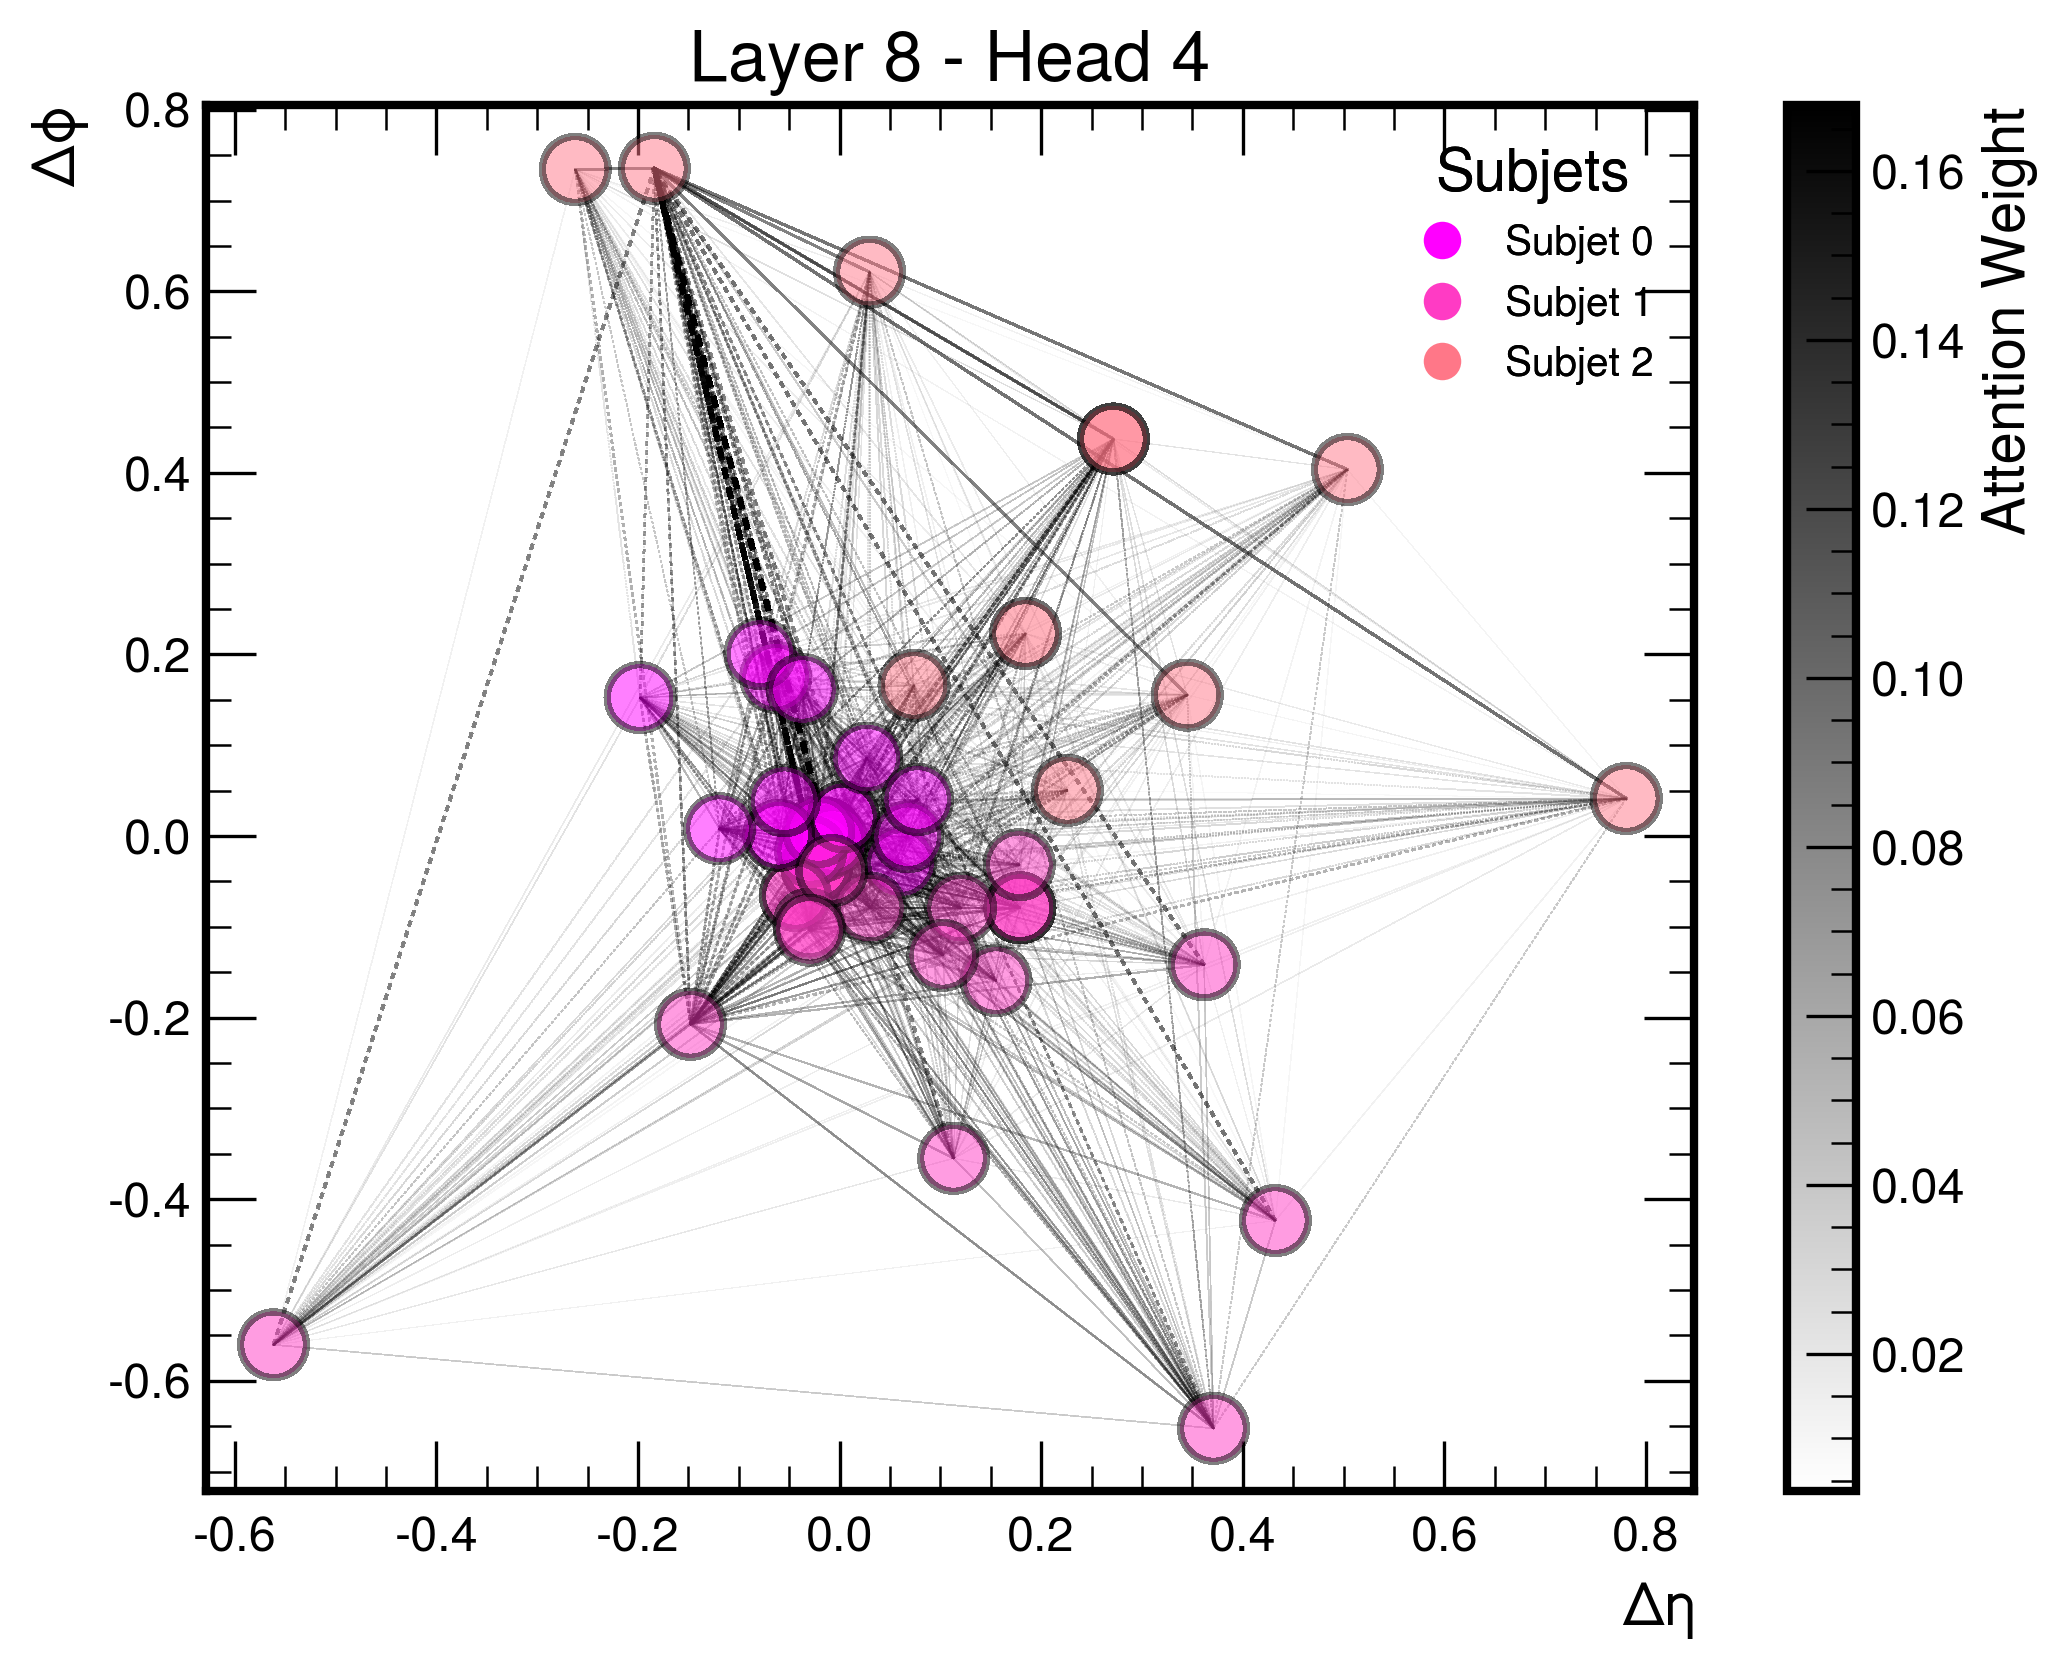

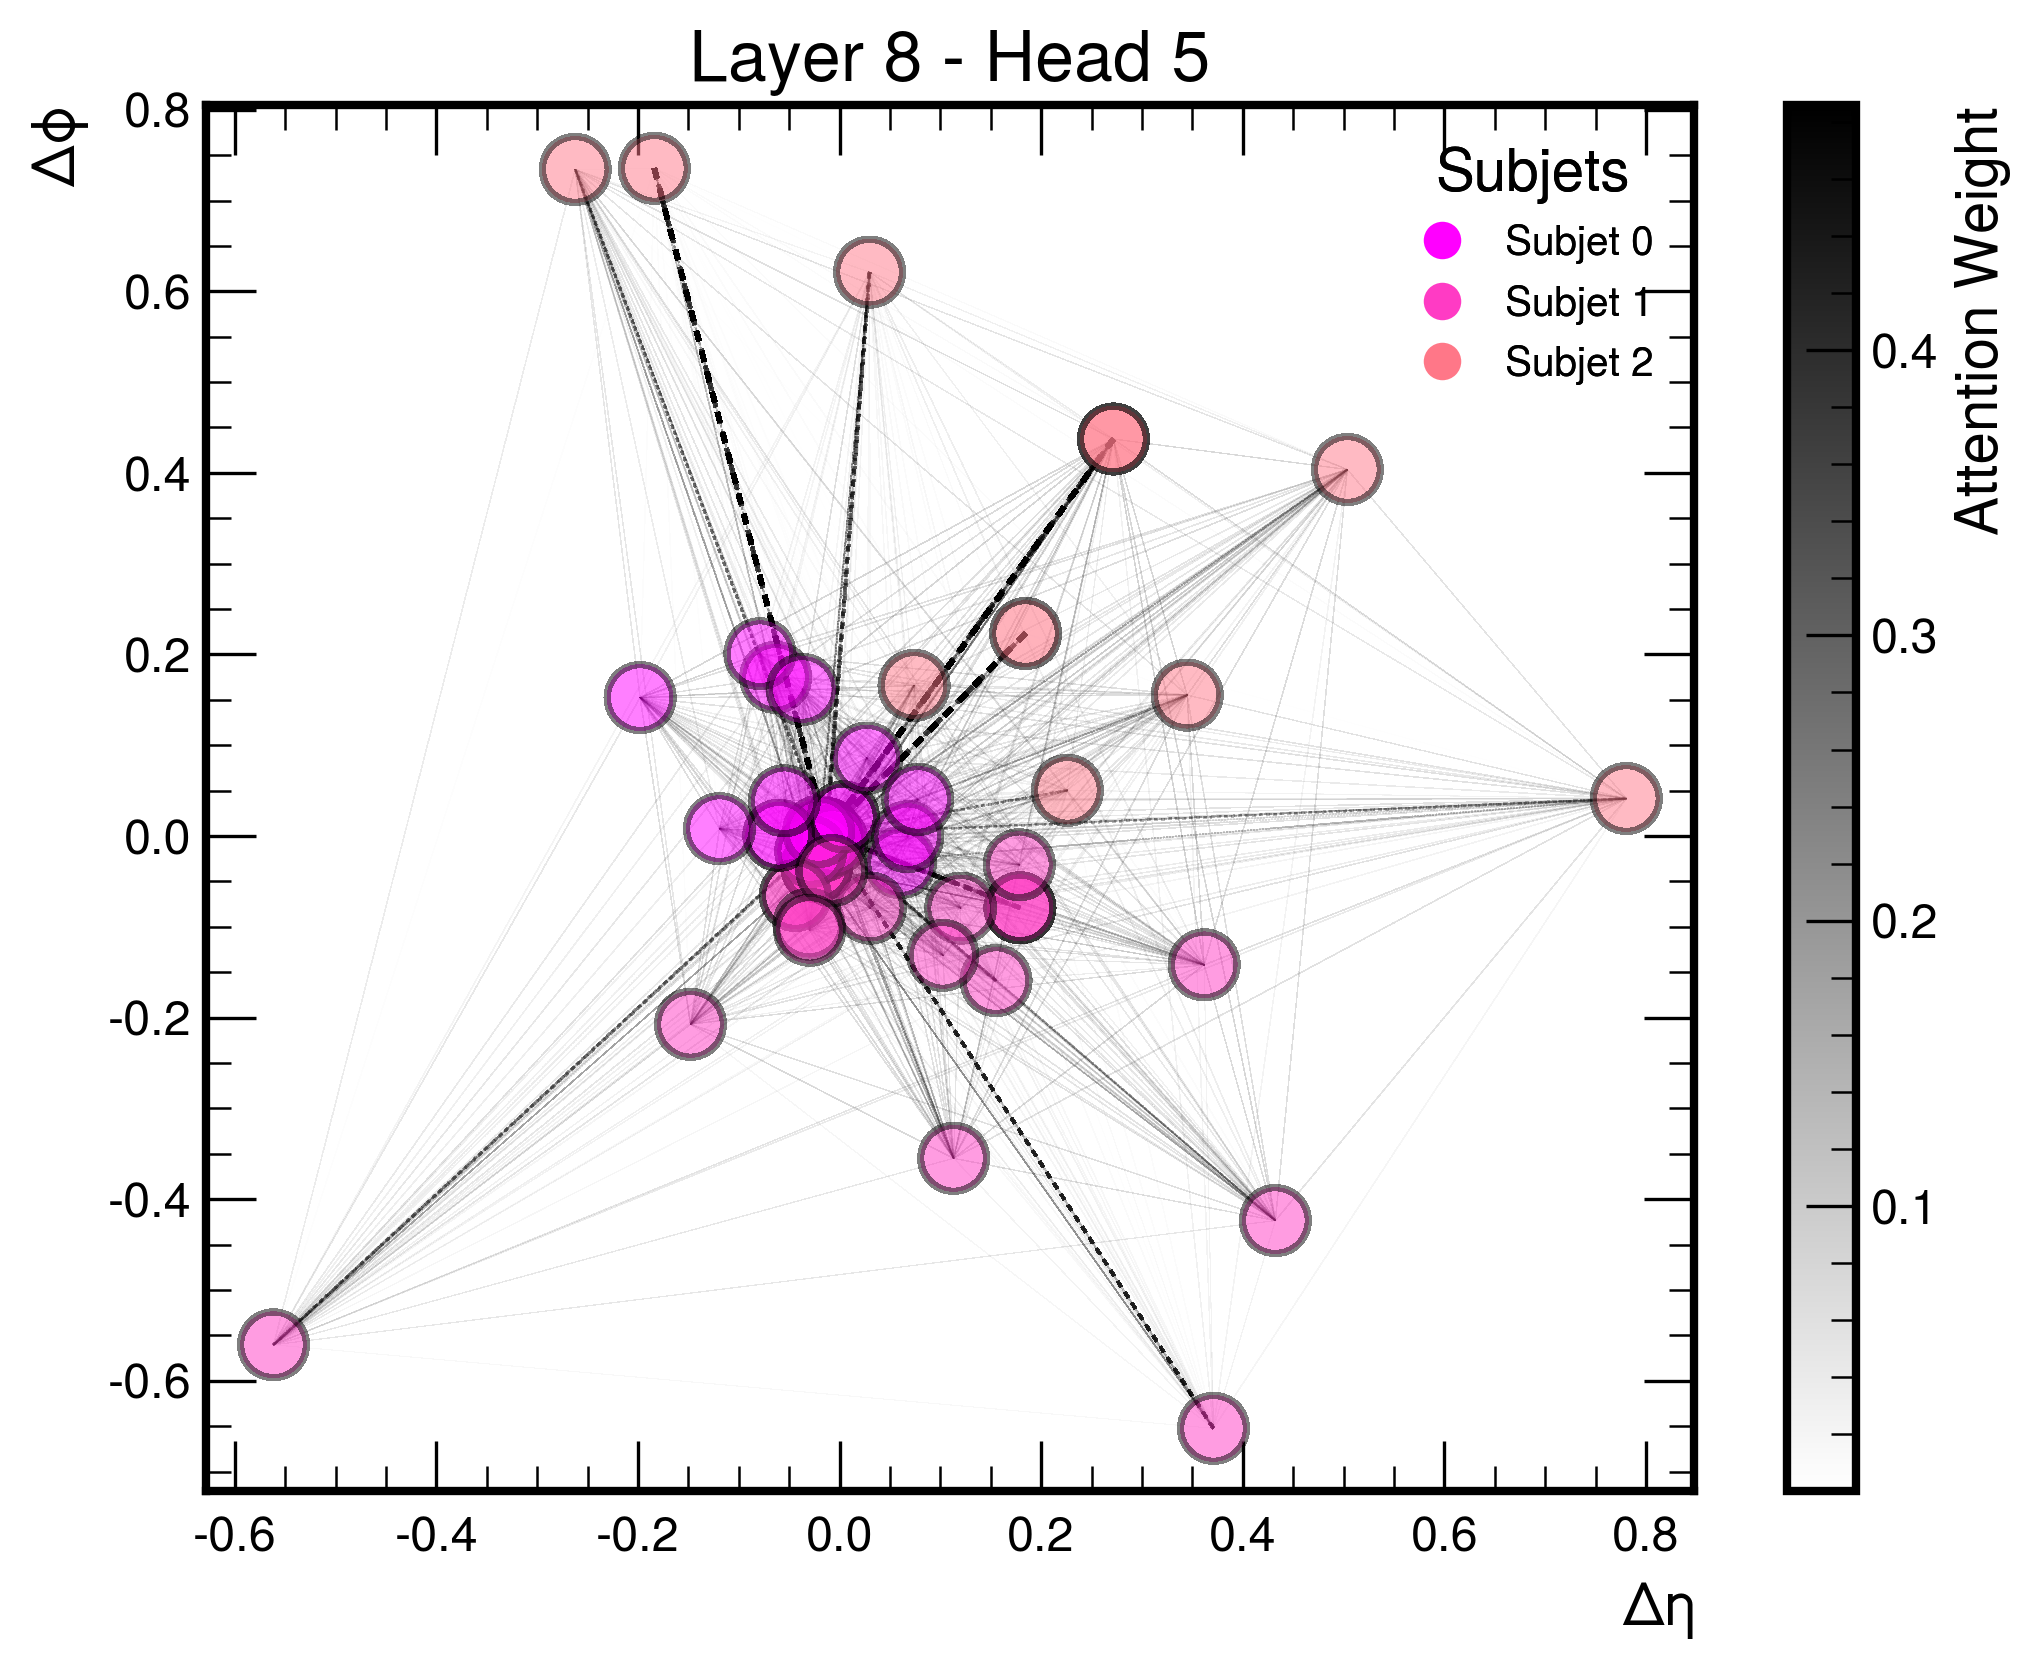

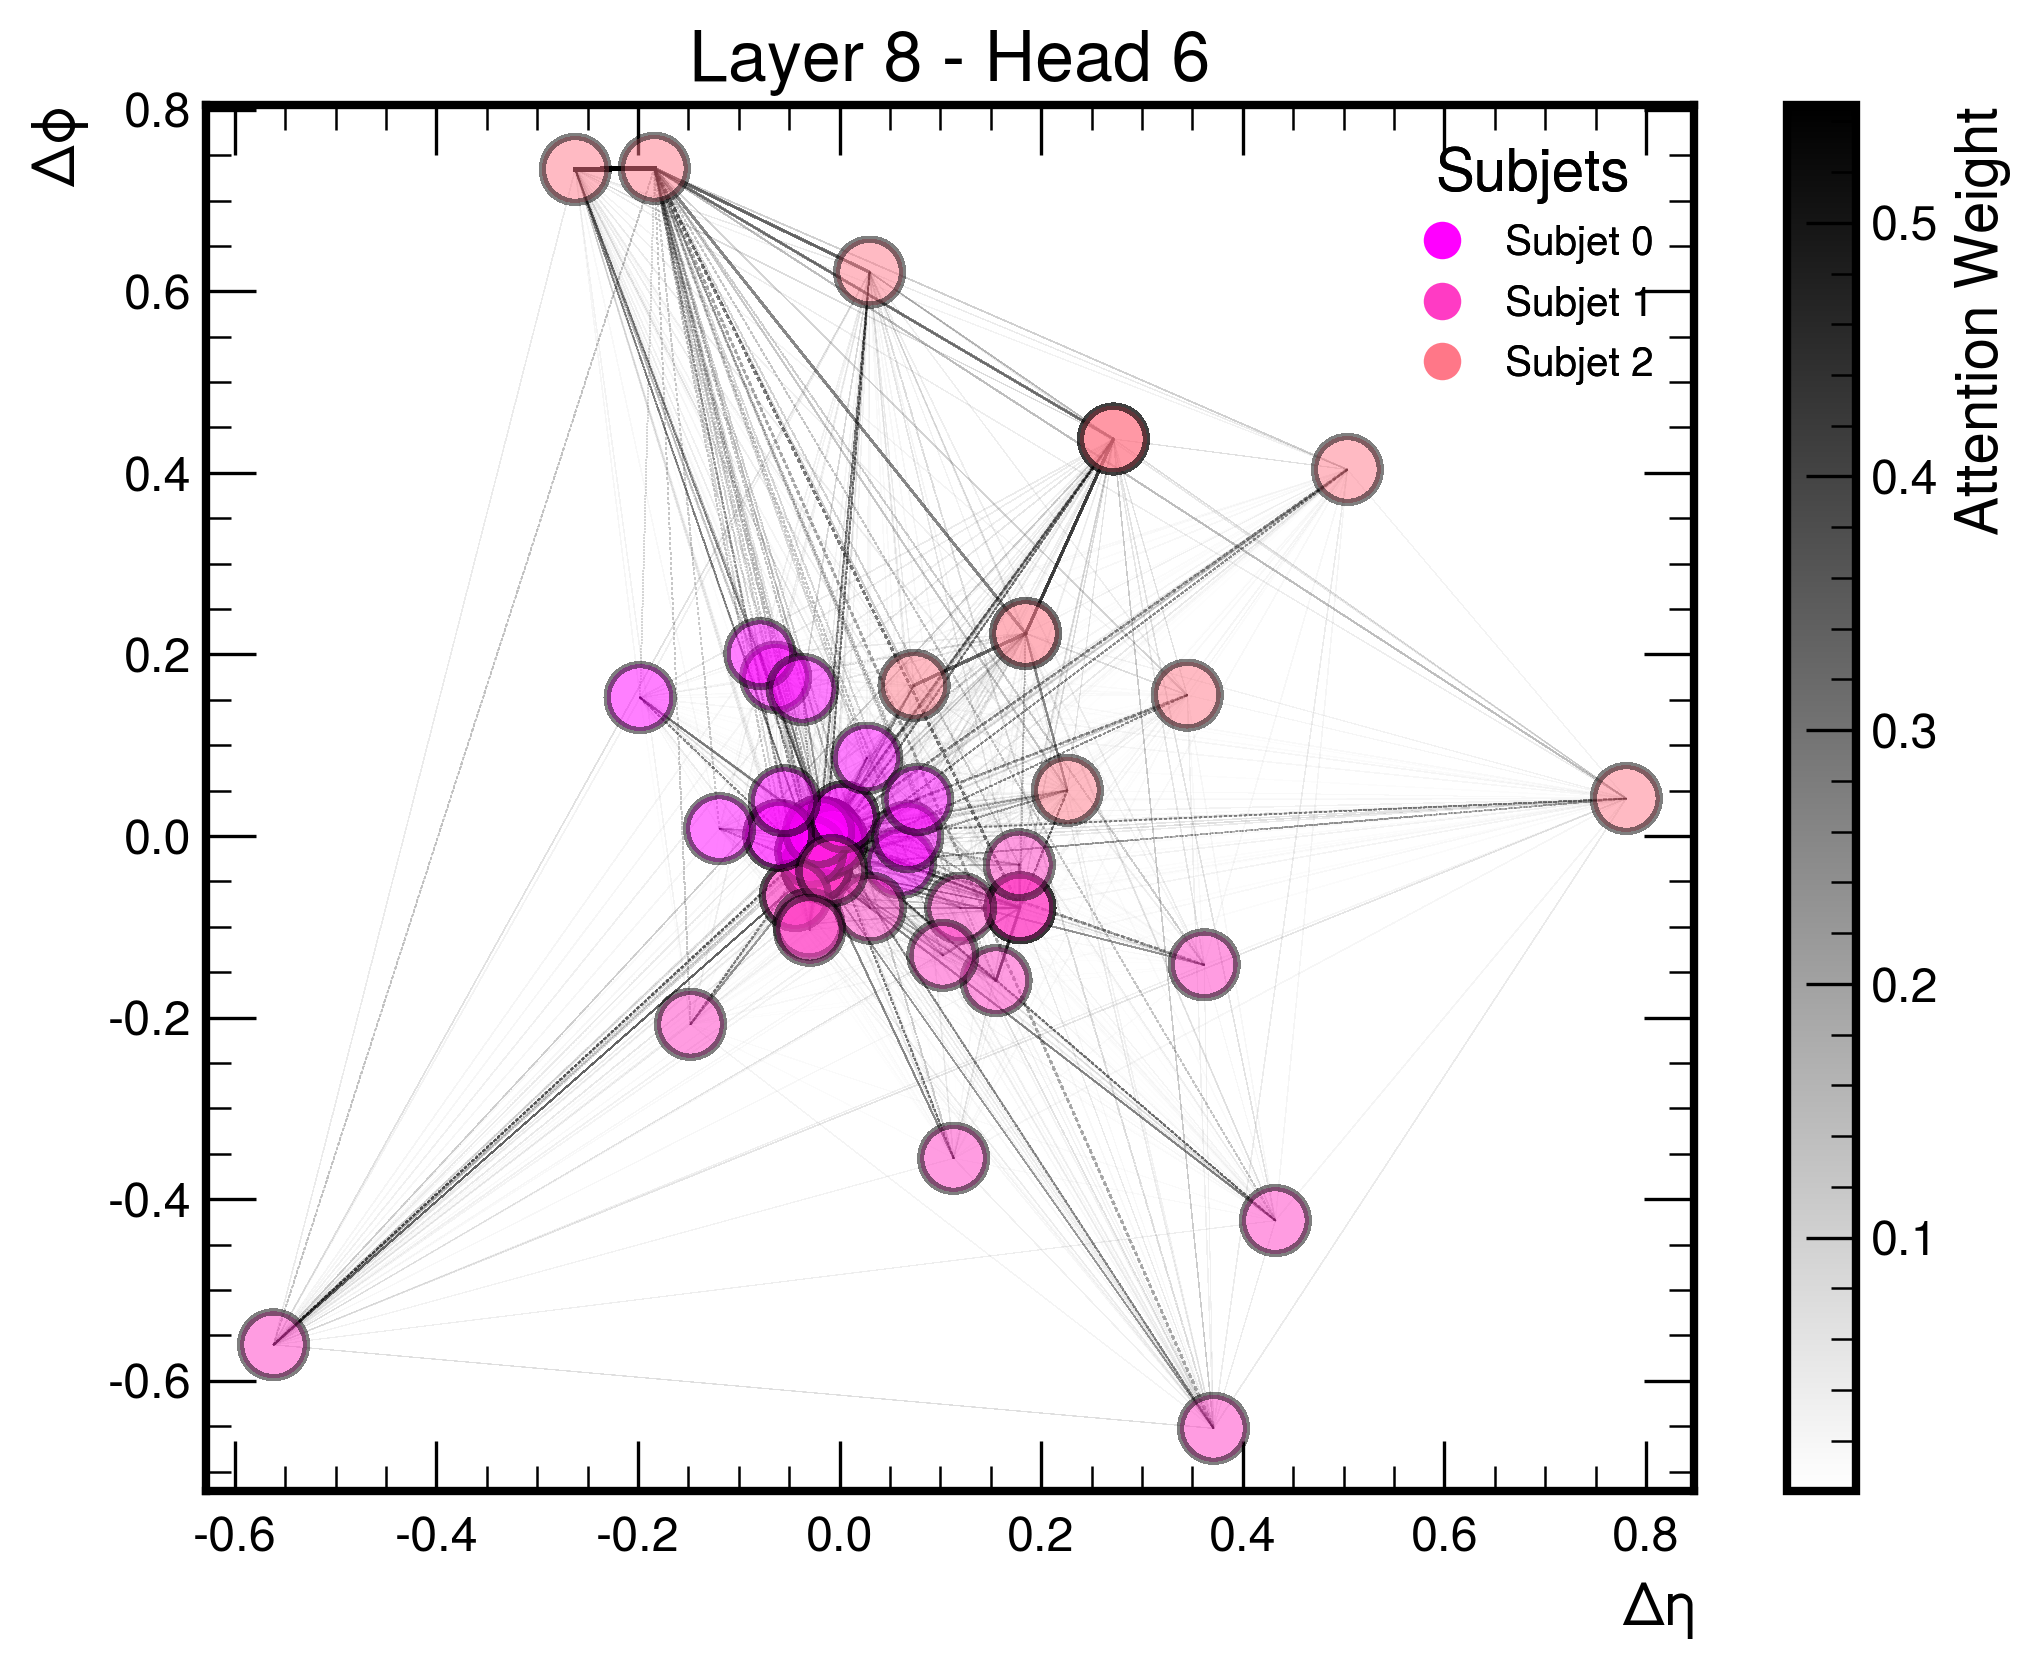

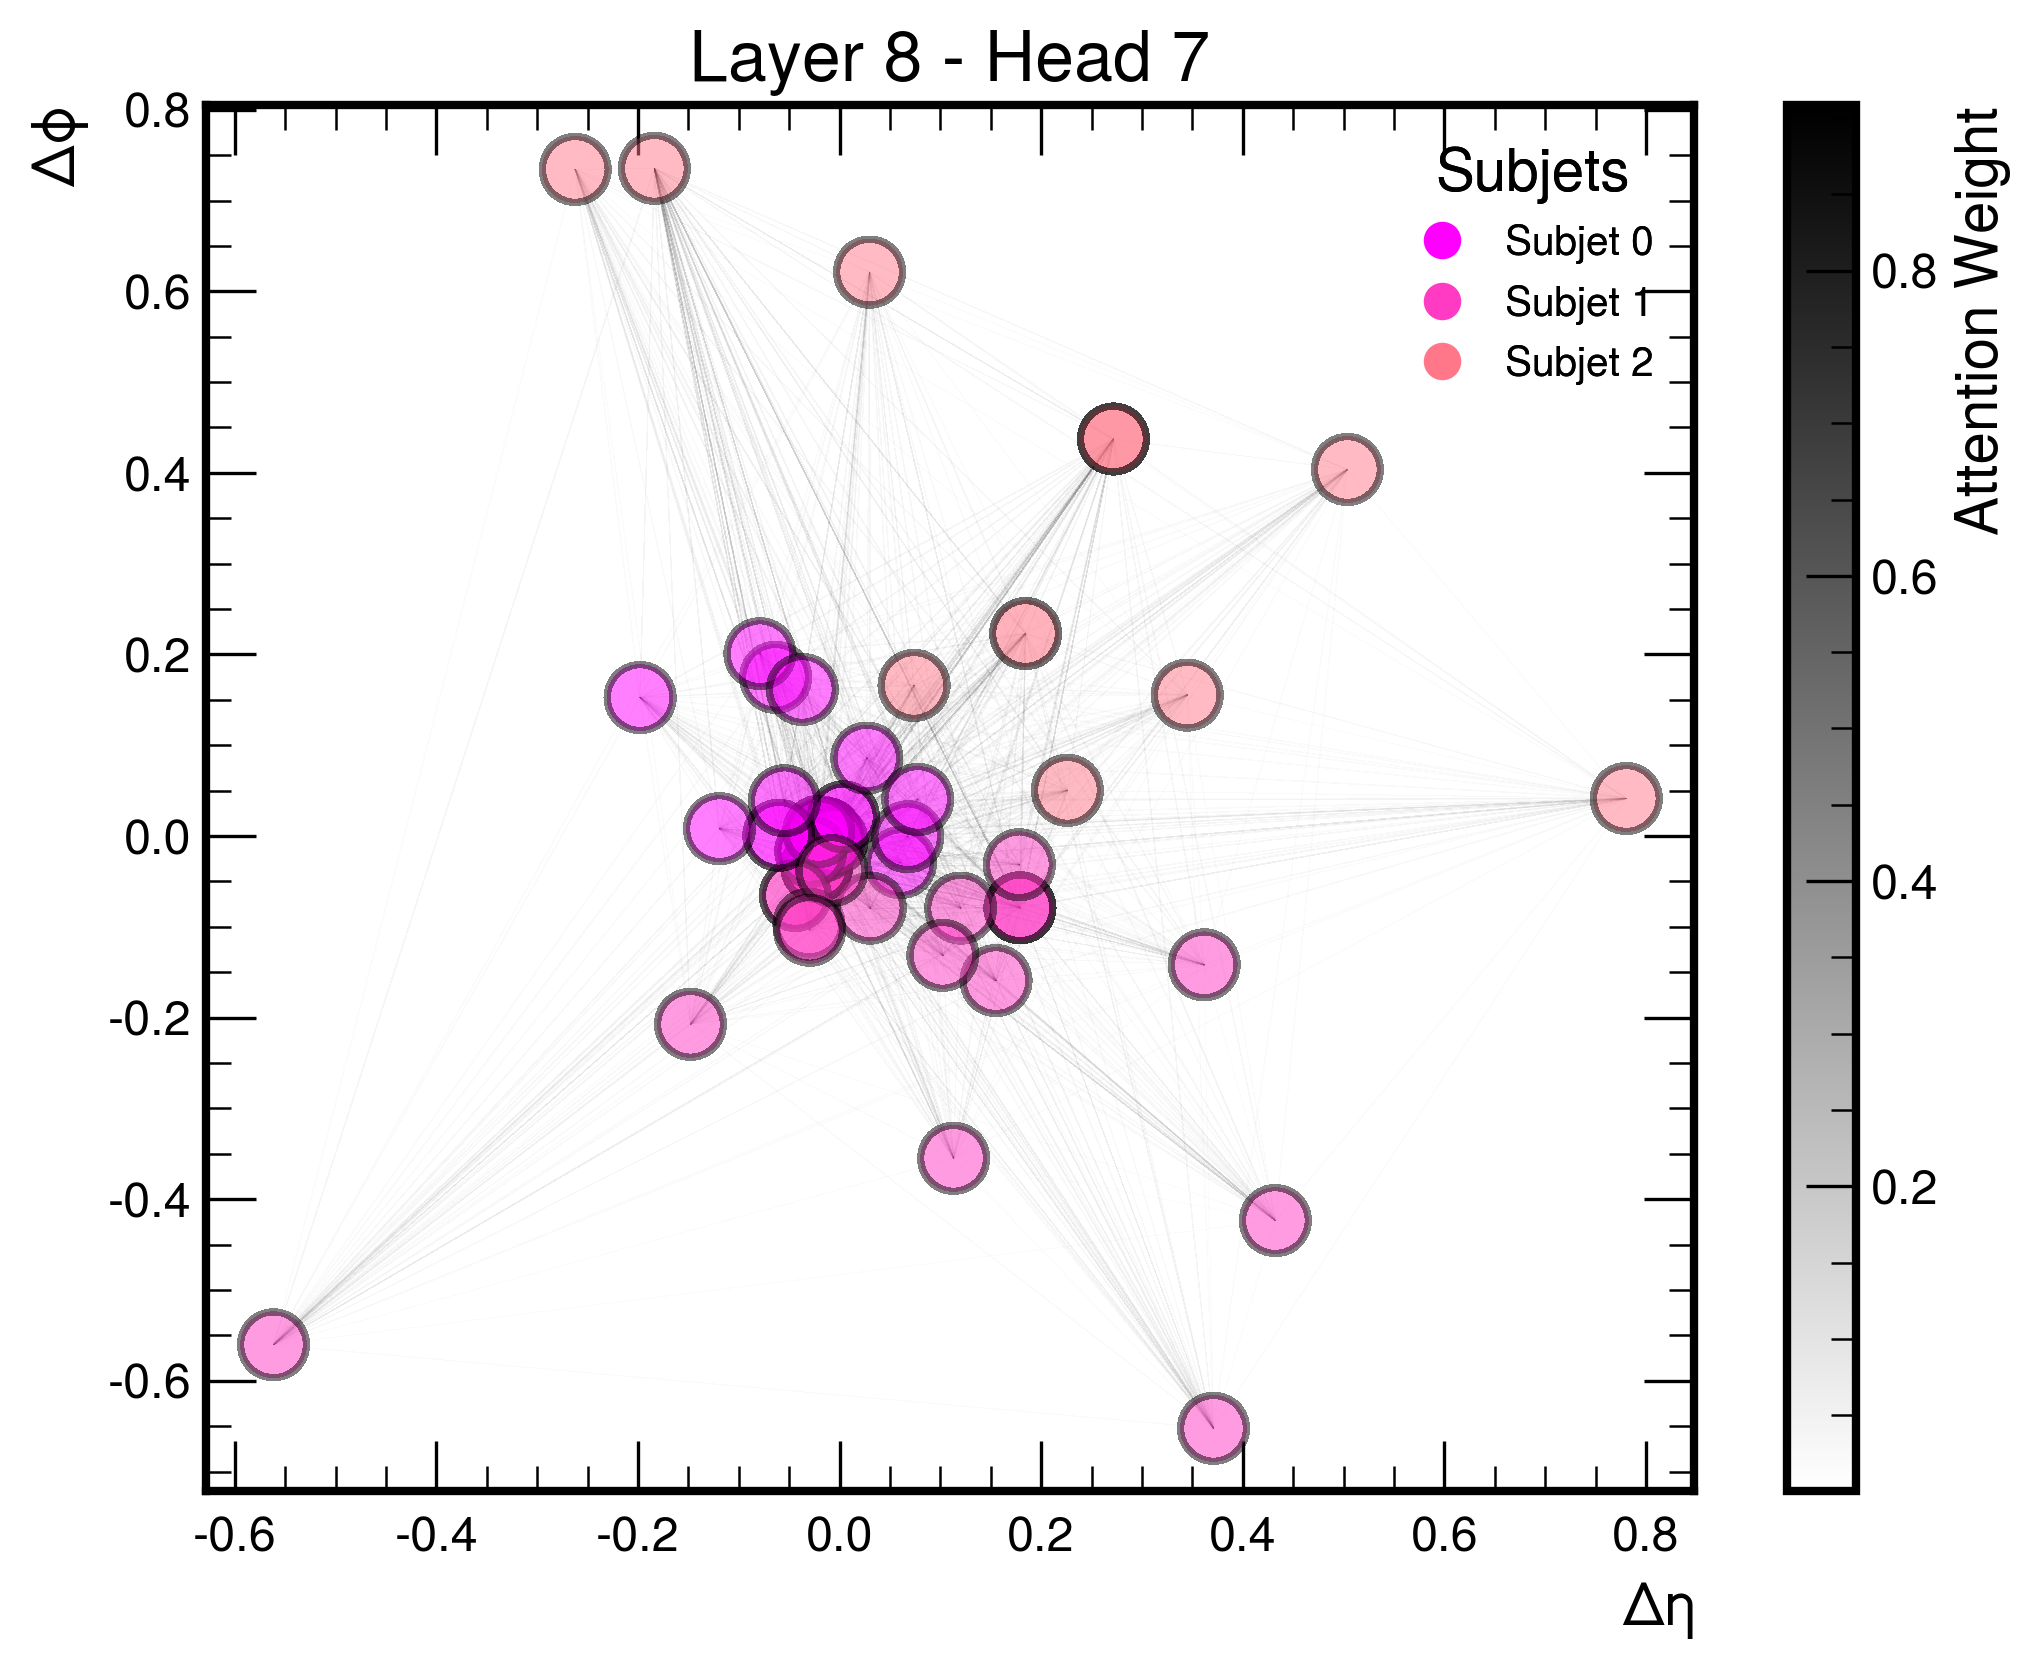

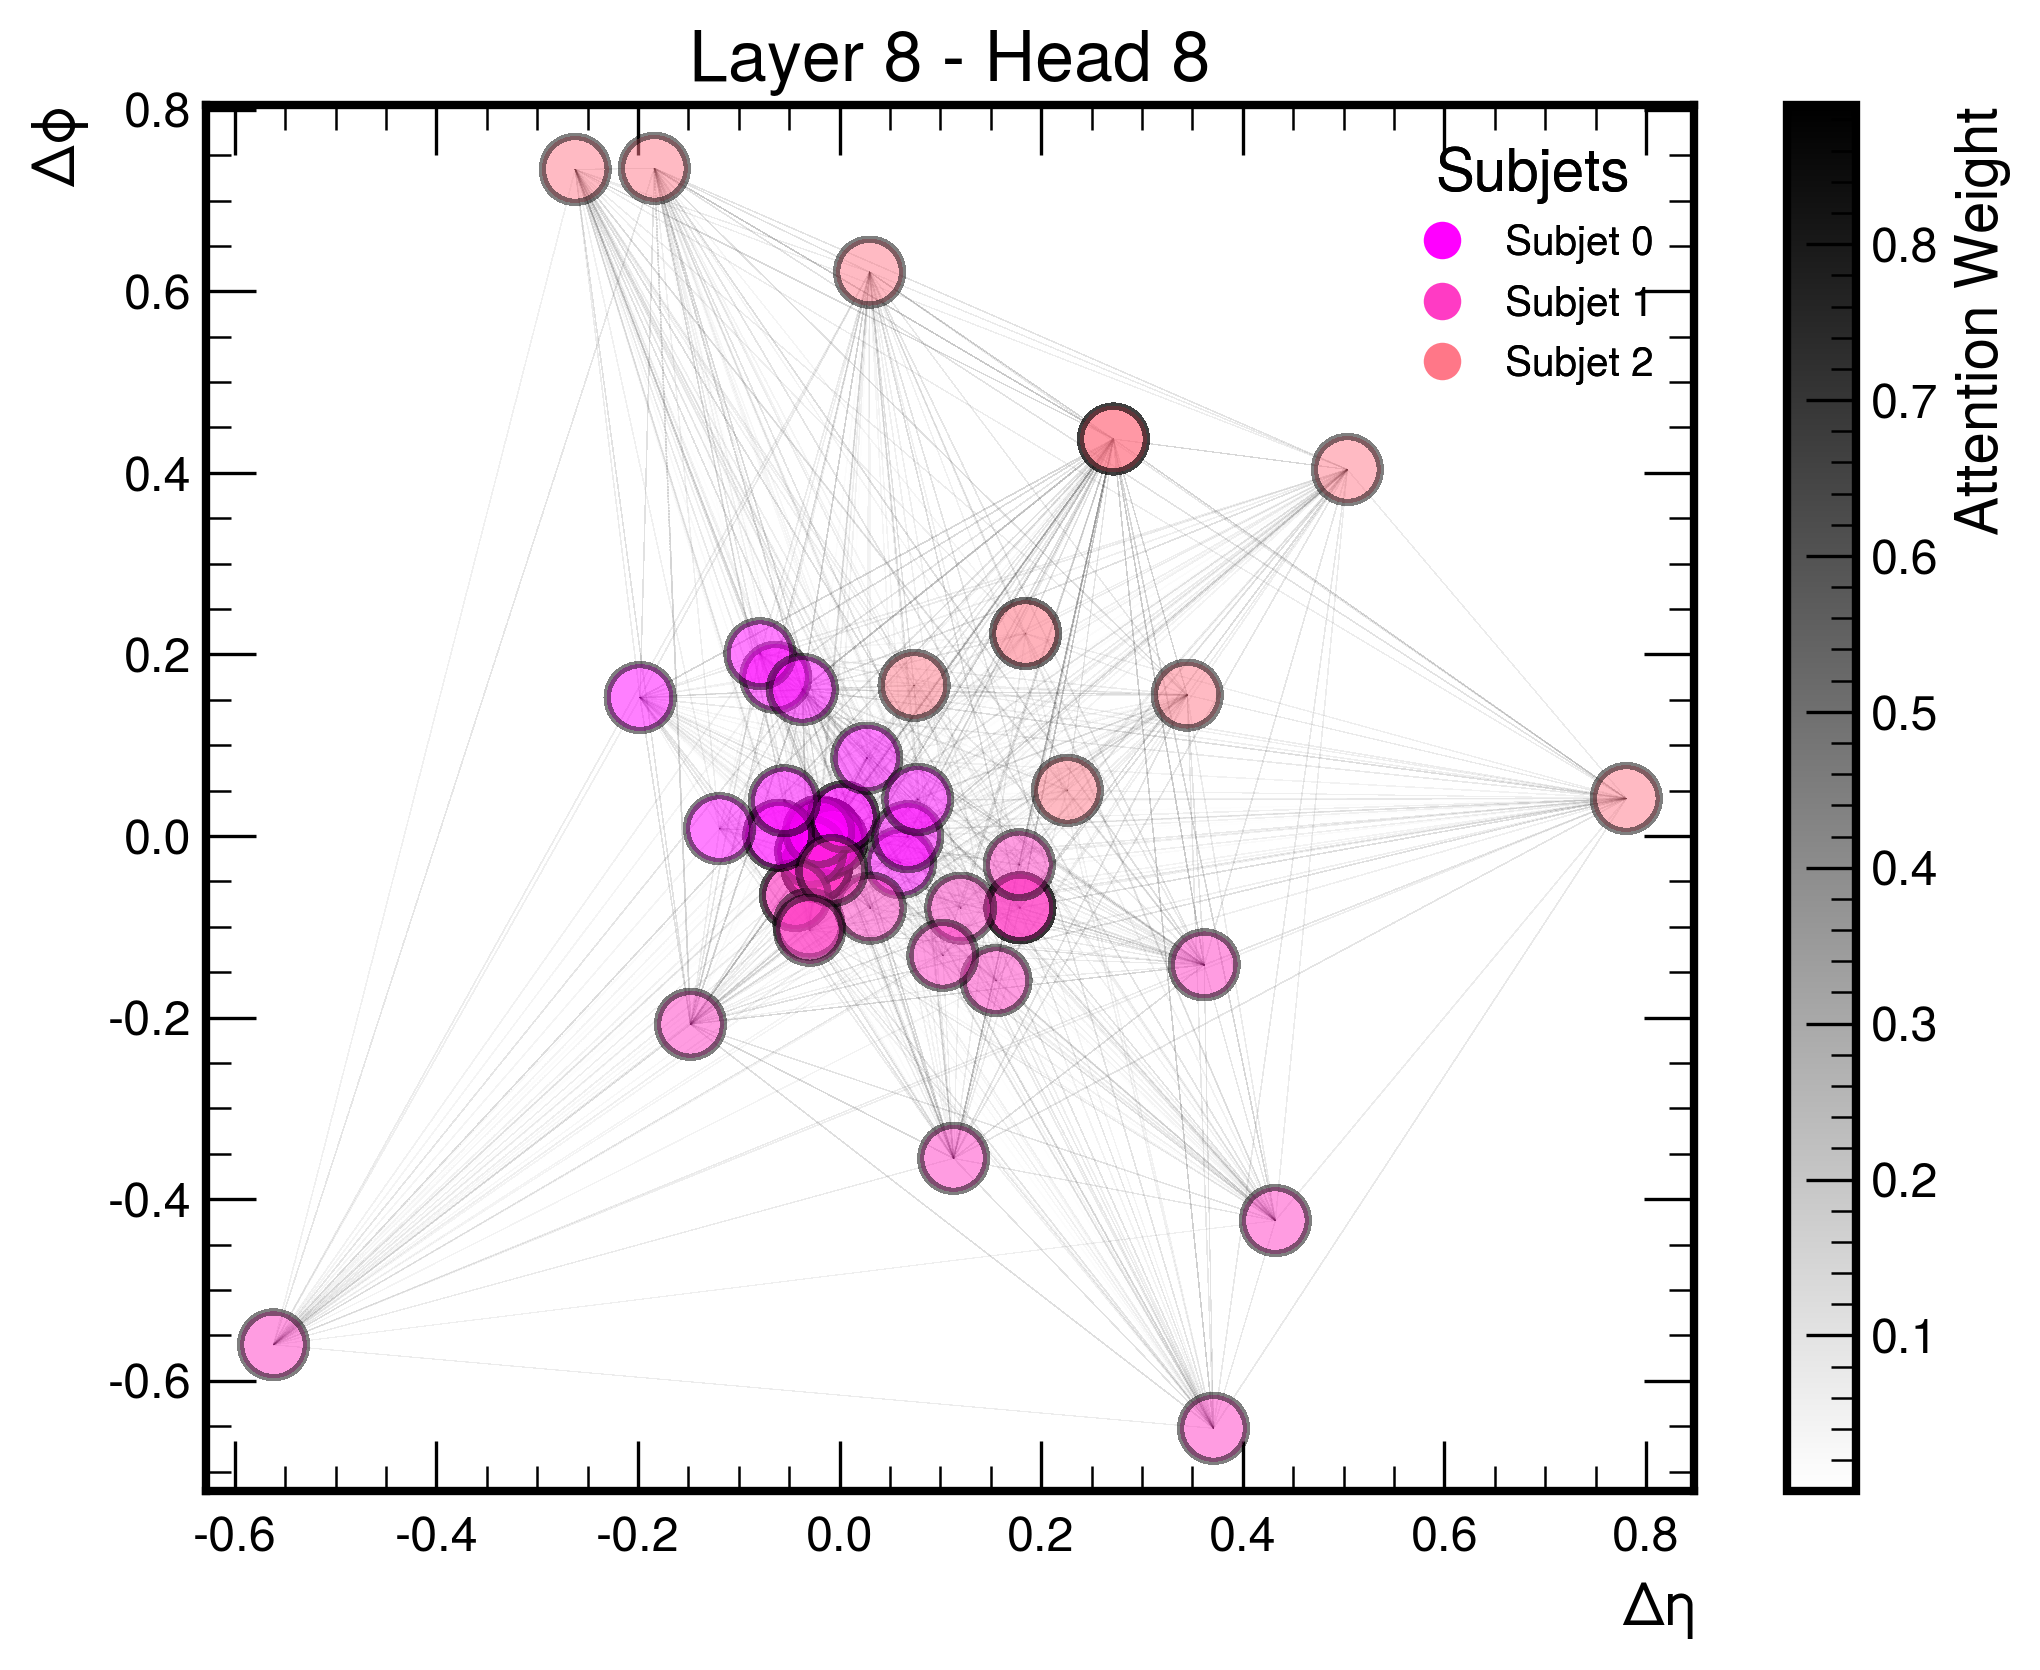

In [30]:
# Example usage based on your context (assuming pf_features, pf_mask, and attention are already defined)
jet = 0
number = jet
num = 0
for b in np.squeeze(tl_pf_mask[number]):
    if b == 0:
        break
    num += 1

# Extract the 4-momentum components for the valid particles
px = tl_pf_vectors[jet][0][0:num]
py = tl_pf_vectors[jet][1][0:num]
pz = tl_pf_vectors[jet][2][0:num]
e = tl_pf_vectors[jet][3][0:num]

# Get the subjets using the get_subjets function
subjets, subjet_vectors = get_subjets(px, py, pz, e, N_SUBJETS=3, JET_ALGO="kt")

# Initialize and combine particle data from all types
deta_all = []
dphi_all = []
pt_all = []
subjets_all = []

# Append all particle types
def append_particles(deta, dphi, pt, subjets, deta_all, dphi_all, pt_all, subjets_all):
    deta_all.extend(deta)
    dphi_all.extend(dphi)
    pt_all.extend(pt)
    subjets_all.extend(subjets)

# Process the particles and combine them into one list
append_particles(tl_pf_features[jet][5][0:num], tl_pf_features[jet][6][0:num], tl_pf_features[jet][0][0:num], subjets,
                 deta_all, dphi_all, pt_all, subjets_all)

# Convert lists to numpy arrays for plotting
deta_all = np.array(deta_all)
dphi_all = np.array(dphi_all)
pt_all = np.array(pt_all)
subjets_all = np.array(subjets_all)

# Example attention data, where `x` is the layer number
layer_number = 7  # Choose the layer
Decay = 'Tbqq'
for head_number in range(8):
  tl_plot_attention_with_particles(tl_attention[layer_number][jet][head_number, 0:num, 0:num], jet, deta_all, dphi_all, pt_all, subjets_all, layer_number, head_number, tl_pf_features, output_filename='Jet' + str(jet) + str(Decay) + '/' + str(Decay) + '-layer'+str(layer_number + 1) + '-head' + str(head_number + 1) + '8172025.pdf')
  #plot_attention_with_particles(srandom_matrix[0][1][4, 0:num, 0:num], jet, deta_all, dphi_all, pt_all, subjets_all, layer_number, head_number, pf_features, '/content/drive/MyDrive/networks/Plots/Jet' + str(jet) + str(Decay) + '/' + 'randomAttentionMatrix' + str(Decay) + '-layer'+str(layer_number + 1) + '-head' + str(head_number + 1) + '.pdf')


In [37]:
print(qg_jet_num)

33


In [20]:
# Define a function to plot the particles and attention lines
def qg_plot_attention_with_particles(attention_head, jet, deta_all, dphi_all, pt_all, subjets_all, layer_number, head_number, pf_features):

    # Normalize pt values for alpha transparency
    norm_pt = mcolors.Normalize(vmin=pt_all.min(), vmax=pt_all.max())
    # Normalize attention for line transparency/width
    norm_attention = mcolors.Normalize(vmin=attention_head.min(), vmax=attention_head.max())

    # Identify the lowest Pt subjet
    unique_subjets, inverse_indices = np.unique(subjets_all, return_inverse=True)
    subjet_pt_sum = np.array([np.sum(pt_all[subjets_all == subjet]) for subjet in unique_subjets])
    lowest_pt_subjet = unique_subjets[np.argmin(subjet_pt_sum)]
    print("Unique subjets: ", unique_subjets)
    print("Lowest Pt subjet: ", lowest_pt_subjet)

    # Use a bright colormap
    colormap = plt.get_cmap('spring')

    fig, ax = plt.subplots(figsize=(12, 8))

    # Prepare colors and markers for all particles
    colors = np.zeros((len(deta_all), 4))
    markers = np.full(len(deta_all), 'o', dtype='<U1')

    # Set colors and markers
    for i in range(len(deta_all)):
        # Determine color
        if subjets_all[i] == lowest_pt_subjet:
            colors[i] = (0.993248, 0.906157, 0.143936, 1.0)  # Yellow
        else:
            colors[i] = colormap(inverse_indices[i] / len(unique_subjets) * 0.7)

        # Determine marker
        if pf_features[jet][6][i] == 1:  # Charged Hadron
            markers[i] = '^'
        elif pf_features[jet][7][i] == 1:  # Neutral Hadron
            markers[i] = 'v'
        elif pf_features[jet][8][i] == 1:  # Photon
            markers[i] = 'o'
        elif pf_features[jet][9][i] == 1:  # Electron
            markers[i] = 'P'
        elif pf_features[jet][10][i] == 1:  # Muon
            markers[i] = 'X'

    # Plot all particles in one call
    scatter = ax.scatter(deta_all, dphi_all, c=colors, alpha=0.8, s=300, edgecolors='black', linewidths=1.5, marker='o')

    # Plot attention lines between particles
    for i in range(attention_head.shape[0]):
        for j in range(attention_head.shape[1]):
            if i != j:  # No self-loops
                attn_value = attention_head[i, j]
                if attn_value > 0.1:  # Threshold to reduce number of lines plotted
                    alpha = norm_attention(attn_value)
                    linestyle = 'solid' if subjets_all[i] == subjets_all[j] else 'dotted'
                    ax.plot([deta_all[i], deta_all[j]], [dphi_all[i], dphi_all[j]], color='black',
                            alpha=alpha, linewidth=3 * alpha, linestyle=linestyle)

    # Create legends for subjet colors and particle shapes
    subjet_handles = [
        plt.Line2D([0], [0], marker='o', color='w', label=f'Subjet {int(subjet)}',
                   markerfacecolor=(0.993248, 0.906157, 0.143936, 1.0) if subjet == lowest_pt_subjet else colormap(idx / len(unique_subjets) * 0.7),
                   markersize=10)
        for idx, subjet in enumerate(unique_subjets)
    ]

    particle_shape_handles = [
        plt.Line2D([0], [0], marker=mk, color='w', label=label, markerfacecolor='black', markersize=10)
        for mk, label in zip(['^', 'v', 'o', 'P', 'X'], ['Charged Hadron', 'Neutral Hadron', 'Photon', 'Electron', 'Muon'])
    ]

    # Add legends
    ax.legend(handles=subjet_handles, loc='upper right', title="Subjets")
    ax.legend(handles=particle_shape_handles, loc='lower right', title="Particle Shapes")

    ax.set_xlabel(r'$\mathbf{\Delta \eta}$', fontsize=20, labelpad=20, weight='bold')
    ax.set_ylabel(r'$\mathbf{\Delta \phi}$', fontsize=20, labelpad=20, weight='bold')
    ax.set_title(f'Layer {layer_number + 1} - Head {head_number + 1}', fontsize=16)

    plt.tight_layout()
    plt.show()

# Example usage based on your context (assuming pf_features, pf_mask, and attention are already defined)
number = jet
num = np.sum(np.squeeze(qg_pf_mask[number]) > 0)  # Count valid particles

# Extract the 4-momentum components for the valid particles
px = pf_vectors[jet][0][:num]
py = pf_vectors[jet][1][:num]
pz = pf_vectors[jet][2][:num]
e = pf_vectors[jet][3][:num]

# Get the subjets
subjets, subjet_vectors = get_subjets(px, py, pz, e, N_SUBJETS=2, JET_ALGO="kt")

# Initialize and combine particle data
deta_all = np.array(qg_pf_features[jet][15][:num])
dphi_all = np.array(qg_pf_features[jet][16][:num])
pt_all = np.array(qg_pf_features[jet][0][:num])
subjets_all = np.array(subjets)

# Example attention data
layer_number = 7  # Choose the layer
head_number = 2  # Choose the head
plot_attention_with_particles(qg_attention[layer_number][jet][head_number, :num, :num], jet, deta_all, dphi_all, pt_all, subjets_all, layer_number, head_number, pf_features)


NameError: name 'pf_vectors' is not defined

In [15]:
model_init = get_model('tl')
#tl_state_dict = torch.load(tltrained_modelpath, map_location=torch.device('cpu'))
#model[0].load_state_dict(tl_state_dict)
#tl_pf_features = tl_data['pf_features'][200:300]
#tl_pf_vectors = tl_data['pf_vectors'][200:300]
#tl_pf_mask = tl_data['pf_mask'][200:300]
#tl_pf_points = tl_data['pf_points'][200:300]
#tl_labels = tl_data['labels'][200:300]
model_init[0].eval()
with torch.no_grad():
    tl_init_y_pred= model_init[0](torch.from_numpy(tl_pf_points),torch.from_numpy(tl_pf_features),torch.from_numpy(tl_pf_vectors),torch.from_numpy(tl_pf_mask))
tl_init_attention = model_init[0].get_attention_matrix()
tl_init_interaction = model_init[0].get_interactionMatrix()

# Inter-Subjet Attention Distribution Analysis

This section analyzes the distribution of attention values between particles in different subjets for TopLandscape-trained models.

In [22]:
import matplotlib.pyplot as plt
import numpy as np

def collect_inter_subjet_attention_values(attention_data, pf_vectors_data, pf_mask_data, num_jets=100, n_subjets=3):
    """
    Collect inter-subjet attention values for TopLandscape model.
    
    Args:
        attention_data: List of attention matrices for each layer and head
        pf_vectors_data: Particle 4-vectors for subjet clustering  
        pf_mask_data: Mask indicating valid particles
        num_jets: Number of jets to analyze
        n_subjets: Number of subjets to cluster into
    
    Returns:
        inter_subjet_values: List of all inter-subjet attention values
        intra_subjet_values: List of all intra-subjet attention values
    """
    
    inter_subjet_values = []
    intra_subjet_values = []
    
    print(f"Processing {num_jets} jets for inter-subjet attention analysis...")
    
    for jet_idx in range(min(num_jets, len(pf_vectors_data))):
        try:
            # Get valid particles for this jet
            mask = pf_mask_data[jet_idx][0]  # Shape: [128]
            valid_particles = np.sum(mask).astype(int)
            print(f"Jet {jet_idx}: Found {valid_particles} valid particles")
            if valid_particles < n_subjets:
                continue
                
            # Get particle 4-vectors for subjet clustering
            px = pf_vectors_data[jet_idx][0][:valid_particles]
            py = pf_vectors_data[jet_idx][1][:valid_particles]
            pz = pf_vectors_data[jet_idx][2][:valid_particles]
            e = pf_vectors_data[jet_idx][3][:valid_particles]

            # Get subjets using the existing function
            subjets_assignment, _ = get_subjets(px, py, pz, e, N_SUBJETS=n_subjets, JET_ALGO="kt")
            
            # Process attention matrices for all layers and heads
            for layer_idx in range(len(attention_data)):
                attention_matrix = attention_data[layer_idx][jet_idx]  # Shape: [8, 128, 128] for 8 heads
                
                for head_idx in range(attention_matrix.shape[0]):
                    attention_head = attention_matrix[head_idx]  # Shape: [128, 128]
                    
                    # Extract attention values between valid particles
                    for i in range(valid_particles):
                        for j in range(valid_particles):
                            if i != j:  # Skip self-attention
                                attention_value = attention_head[i, j]
                                
                                # Check if particles are in same or different subjets
                                if subjets_assignment[i] == subjets_assignment[j]:
                                    # Same subjet (intra-subjet)
                                    intra_subjet_values.append(attention_value)
                                else:
                                    # Different subjets (inter-subjet)
                                    inter_subjet_values.append(attention_value)
                                    
        except Exception as e:
            print(f"Skipping jet {jet_idx} due to error: {e}")
            continue
    
    print(f"Collected {len(inter_subjet_values)} inter-subjet attention values")
    print(f"Collected {len(intra_subjet_values)} intra-subjet attention values")
    
    return inter_subjet_values, intra_subjet_values

In [23]:
def plot_inter_subjet_attention_distribution(inter_subjet_values, intra_subjet_values, 
                                            bins=50, title_prefix="TopLandscape", save_path=None):
    """
    Plot histogram distribution of inter-subjet vs intra-subjet attention values.
    
    Args:
        inter_subjet_values: List of attention values between particles in different subjets
        intra_subjet_values: List of attention values between particles in same subjet  
        bins: Number of histogram bins
        title_prefix: Prefix for plot title
        save_path: Path to save figure (optional)
    """
    
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
    
    # Convert to numpy arrays for easier handling
    inter_vals = np.array(inter_subjet_values)
    intra_vals = np.array(intra_subjet_values)
    
    # Plot 1: Inter-subjet attention distribution
    ax1.hist(inter_vals, bins=bins, alpha=0.7, color='red', density=True, edgecolor='black')
    ax1.set_xlabel('Attention Value')
    ax1.set_ylabel('Probability Density')
    ax1.set_title(f'{title_prefix}: Inter-Subjet Attention Distribution')
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0, 1)
    
    # Add statistics
    mean_inter = np.mean(inter_vals)
    std_inter = np.std(inter_vals)
    ax1.axvline(mean_inter, color='darkred', linestyle='--', linewidth=2, 
                label=f'Mean: {mean_inter:.4f} ± {std_inter:.4f}')
    ax1.legend()
    
    # Plot 2: Intra-subjet attention distribution  
    ax2.hist(intra_vals, bins=bins, alpha=0.7, color='blue', density=True, edgecolor='black')
    ax2.set_xlabel('Attention Value')
    ax2.set_ylabel('Probability Density')
    ax2.set_title(f'{title_prefix}: Intra-Subjet Attention Distribution')
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(0, 1)
    
    # Add statistics
    mean_intra = np.mean(intra_vals)
    std_intra = np.std(intra_vals)
    ax2.axvline(mean_intra, color='darkblue', linestyle='--', linewidth=2,
                label=f'Mean: {mean_intra:.4f} ± {std_intra:.4f}')
    ax2.legend()
    
    # Plot 3: Comparison plot
    ax3.hist(inter_vals, bins=bins, alpha=0.6, color='red', density=True, 
             label=f'Inter-Subjet (n={len(inter_vals):,})', edgecolor='black')
    ax3.hist(intra_vals, bins=bins, alpha=0.6, color='blue', density=True,
             label=f'Intra-Subjet (n={len(intra_vals):,})', edgecolor='black')
    ax3.set_xlabel('Attention Value')
    ax3.set_ylabel('Probability Density')
    ax3.set_title(f'{title_prefix}: Inter vs Intra-Subjet Attention')
    ax3.grid(True, alpha=0.3)
    ax3.legend()
    ax3.set_xlim(0, 1)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to: {save_path}")
    
    plt.show()
    
    # Print summary statistics
    print("\n=== Inter-Subjet Attention Statistics ===")
    print(f"Count: {len(inter_vals):,}")
    print(f"Mean: {mean_inter:.6f}")
    print(f"Std: {std_inter:.6f}")
    print(f"Min: {np.min(inter_vals):.6f}")
    print(f"Max: {np.max(inter_vals):.6f}")
    print(f"Median: {np.median(inter_vals):.6f}")
    
    print("\n=== Intra-Subjet Attention Statistics ===")
    print(f"Count: {len(intra_vals):,}")
    print(f"Mean: {mean_intra:.6f}")
    print(f"Std: {std_intra:.6f}")
    print(f"Min: {np.min(intra_vals):.6f}")
    print(f"Max: {np.max(intra_vals):.6f}")
    print(f"Median: {np.median(intra_vals):.6f}")
    
    # Statistical comparison
    ratio = mean_inter / mean_intra if mean_intra > 0 else float('inf')
    print(f"\n=== Comparison ===")
    print(f"Inter/Intra Mean Ratio: {ratio:.4f}")
    print(f"Mean Difference: {mean_inter - mean_intra:.6f}")
    
    return fig

In [24]:
# Collect inter-subjet attention values for TopLandscape model
print("Collecting inter-subjet attention values for TopLandscape model...")

# Use TopLandscape data that's already loaded
tl_inter_subjet, tl_intra_subjet = collect_inter_subjet_attention_values(
    attention_data=tl_attention,  # TopLandscape attention data
    pf_vectors_data=tl_pf_vectors,  # TopLandscape particle vectors
    pf_mask_data=tl_pf_mask,  # TopLandscape particle mask
    num_jets=5,  # Analyze first 20 jets for computational efficiency
    n_subjets=3   # Standard 3-subjet clustering for top quarks
)

Processing 5 jets for inter-subjet attention analysis...
Jet 0: Found 48 valid particles
1
#--------------------------------------------------------------------------
#                         FastJet release 3.4.1
#                 M. Cacciari, G.P. Salam and G. Soyez                  
#     A software package for jet finding and analysis at colliders      
#                           http://fastjet.fr                           
#	                                                                      
# Please cite EPJC72(2012)1896 [arXiv:1111.6097] if you use this package
# for scientific work and optionally PLB641(2006)57 [hep-ph/0512210].   
#                                                                       
# FastJet is provided without warranty under the GNU GPL v2 or higher.  
# It uses T. Chan's closest pair algorithm, S. Fortune's Voronoi code,
# CGAL and 3rd party plugin jet algorithms. See COPYING file for details.
#-------------------------------------------------------

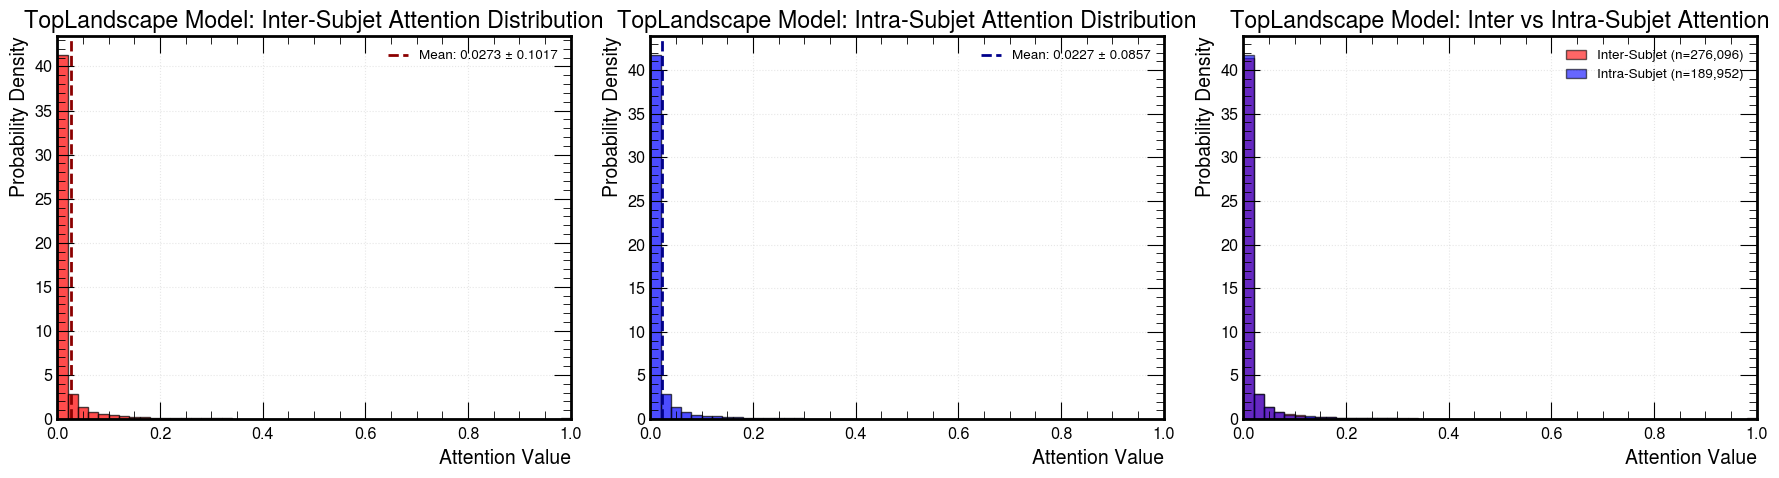


=== Inter-Subjet Attention Statistics ===
Count: 276,096
Mean: 0.027298
Std: 0.101687
Min: 0.000000
Max: 1.000000
Median: 0.000204

=== Intra-Subjet Attention Statistics ===
Count: 189,952
Mean: 0.022679
Std: 0.085671
Min: 0.000000
Max: 1.000000
Median: 0.000214

=== Comparison ===
Inter/Intra Mean Ratio: 1.2036
Mean Difference: 0.004618


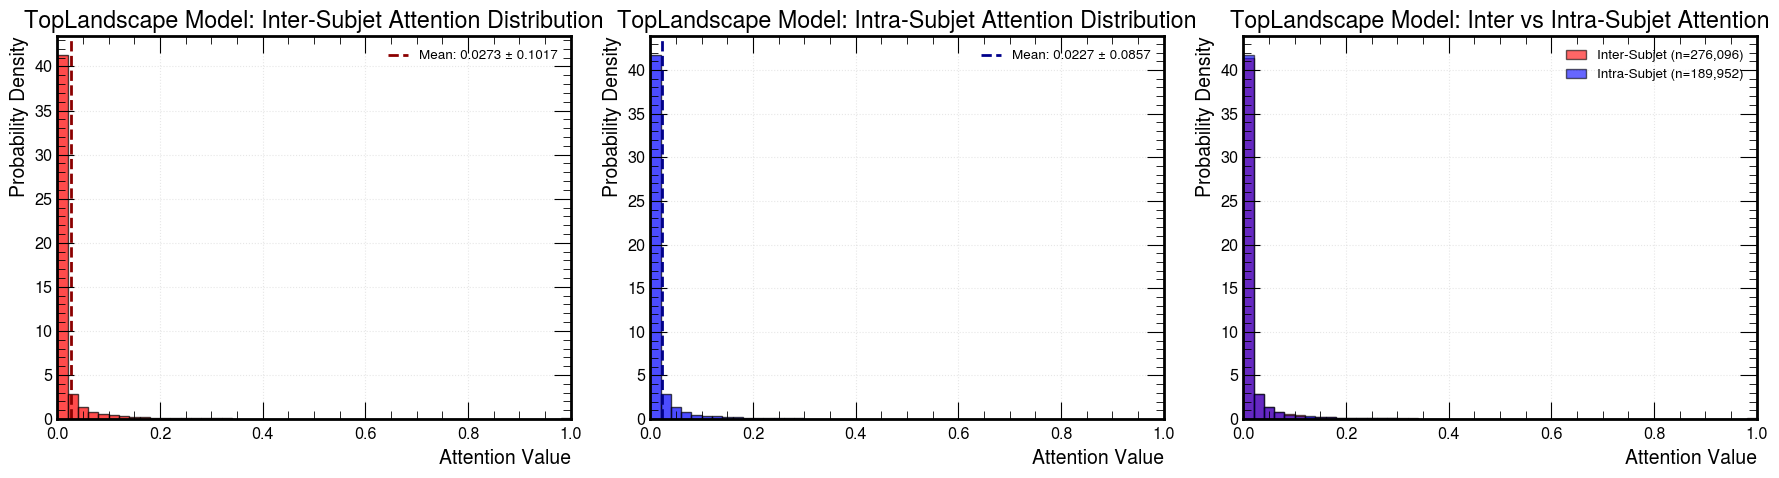

In [25]:
# Plot inter-subjet attention distribution
plot_inter_subjet_attention_distribution(
    inter_subjet_values=tl_inter_subjet,
    intra_subjet_values=tl_intra_subjet,
    bins=50,
    title_prefix="TopLandscape Model",
)

# save_path="attn_plots/tl/inter_subjet_attention_distribution.png"

In [ ]:
def analyze_inter_subjet_by_layer_head(attention_data, pf_vectors_data, pf_mask_data, 
                                      num_jets=50, n_subjets=3):
    """
    Analyze inter-subjet attention values broken down by layer and head.
    """
    
    results = {}
    
    for layer_idx in range(len(attention_data)):
        results[f'layer_{layer_idx}'] = {}
        
        for head_idx in range(8):  # Assuming 8 heads
            inter_vals = []
            
            for jet_idx in range(min(num_jets, len(pf_vectors_data))):
                try:
                    # Get valid particles for this jet
                    mask = pf_mask_data[jet_idx][0]
                    valid_particles = np.sum(mask)
                    
                    if valid_particles < n_subjets:
                        continue
                        
                    # Get particle 4-vectors for subjet clustering
                    px = pf_vectors_data[jet_idx][0][:valid_particles]
                    py = pf_vectors_data[jet_idx][1][:valid_particles] 
                    pz = pf_vectors_data[jet_idx][2][:valid_particles]
                    e = pf_vectors_data[jet_idx][3][:valid_particles]
                    
                    # Get subjets
                    subjets_assignment, _ = get_subjets(px, py, pz, e, N_SUBJETS=n_subjets, JET_ALGO="kt")
                    
                    # Get attention matrix for this layer and head
                    attention_head = attention_data[layer_idx][jet_idx][head_idx]
                    
                    # Extract inter-subjet attention values
                    for i in range(valid_particles):
                        for j in range(valid_particles):
                            if i != j and subjets_assignment[i] != subjets_assignment[j]:
                                inter_vals.append(attention_head[i, j])
                                
                except Exception:
                    continue
            
            results[f'layer_{layer_idx}'][f'head_{head_idx}'] = {
                'values': inter_vals,
                'mean': np.mean(inter_vals) if inter_vals else 0,
                'std': np.std(inter_vals) if inter_vals else 0,
                'count': len(inter_vals)
            }
    
    return results

# Analyze by layer and head
print("Analyzing inter-subjet attention by layer and head...")
tl_layer_head_analysis = analyze_inter_subjet_by_layer_head(
    tl_attention, tl_pf_vectors, tl_pf_mask, num_jets=50, n_subjets=3
)

In [ ]:
# Plot heatmap of inter-subjet attention by layer and head
def plot_layer_head_heatmap(results, metric='mean', title_prefix="TopLandscape"):
    """Plot heatmap of inter-subjet attention statistics by layer and head."""
    
    # Extract data for heatmap
    layers = sorted([k for k in results.keys() if k.startswith('layer_')])
    heads = [f'head_{i}' for i in range(8)]
    
    data_matrix = np.zeros((len(layers), len(heads)))
    
    for i, layer in enumerate(layers):
        for j, head in enumerate(heads):
            if head in results[layer]:
                data_matrix[i, j] = results[layer][head][metric]
    
    # Create heatmap
    fig, ax = plt.subplots(figsize=(10, 6))
    im = ax.imshow(data_matrix, cmap='viridis', aspect='auto')
    
    # Set ticks and labels
    ax.set_xticks(np.arange(len(heads)))
    ax.set_yticks(np.arange(len(layers)))
    ax.set_xticklabels([f'Head {i+1}' for i in range(len(heads))])
    ax.set_yticklabels([f'Layer {i+1}' for i in range(len(layers))])
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(f'Inter-Subjet Attention {metric.capitalize()}', rotation=270, labelpad=20)
    
    # Add value annotations
    for i in range(len(layers)):
        for j in range(len(heads)):
            text = ax.text(j, i, f'{data_matrix[i, j]:.4f}', 
                          ha="center", va="center", color="white", fontsize=8)
    
    ax.set_title(f'{title_prefix}: Inter-Subjet Attention {metric.capitalize()} by Layer and Head')
    ax.set_xlabel('Attention Head')
    ax.set_ylabel('Transformer Layer')
    
    plt.tight_layout()
    plt.show()
    
    return fig

# Plot the heatmap
plot_layer_head_heatmap(tl_layer_head_analysis, metric='mean', title_prefix="TopLandscape Model")

In [ ]:
# Optional: Compare with QuarkGluon model (which has 2-subjet structure)
print("Collecting inter-subjet attention values for QuarkGluon model for comparison...")

# Collect QuarkGluon inter-subjet attention (with 2-subjet clustering)
qg_inter_subjet, qg_intra_subjet = collect_inter_subjet_attention_values(
    attention_data=qg_attention,  # QuarkGluon attention data
    pf_vectors_data=qg_pf_vectors,  # QuarkGluon particle vectors
    pf_mask_data=qg_pf_mask,  # QuarkGluon particle mask
    num_jets=50,  # Analyze first 50 jets
    n_subjets=2   # 2-subjet clustering for quark vs gluon
)

In [ ]:
# Comparative analysis between TopLandscape and QuarkGluon
def plot_comparative_inter_subjet_attention(tl_inter, qg_inter, bins=50):
    """
    Plot comparative histogram of inter-subjet attention between TopLandscape and QuarkGluon models.
    """
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Convert to numpy arrays
    tl_vals = np.array(tl_inter)
    qg_vals = np.array(qg_inter)
    
    # Plot 1: Overlay comparison
    ax1.hist(tl_vals, bins=bins, alpha=0.6, color='red', density=True, 
             label=f'TopLandscape (3-subjets)\nn={len(tl_vals):,}', edgecolor='black')
    ax1.hist(qg_vals, bins=bins, alpha=0.6, color='green', density=True,
             label=f'QuarkGluon (2-subjets)\nn={len(qg_vals):,}', edgecolor='black')
    
    ax1.set_xlabel('Inter-Subjet Attention Value')
    ax1.set_ylabel('Probability Density') 
    ax1.set_title('Inter-Subjet Attention: TopLandscape vs QuarkGluon')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    ax1.set_xlim(0, 1)
    
    # Add mean lines
    tl_mean = np.mean(tl_vals)
    qg_mean = np.mean(qg_vals)
    ax1.axvline(tl_mean, color='darkred', linestyle='--', linewidth=2, alpha=0.8)
    ax1.axvline(qg_mean, color='darkgreen', linestyle='--', linewidth=2, alpha=0.8)
    
    # Plot 2: Box plot comparison
    box_data = [tl_vals, qg_vals]
    box_labels = ['TopLandscape\n(3-subjets)', 'QuarkGluon\n(2-subjets)']
    
    bp = ax2.boxplot(box_data, labels=box_labels, patch_artist=True)
    bp['boxes'][0].set_facecolor('red')
    bp['boxes'][0].set_alpha(0.6)
    bp['boxes'][1].set_facecolor('green') 
    bp['boxes'][1].set_alpha(0.6)
    
    ax2.set_ylabel('Inter-Subjet Attention Value')
    ax2.set_title('Inter-Subjet Attention Distribution Comparison')
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(0, 1)
    
    plt.tight_layout()
    plt.show()
    
    # Print comparison statistics
    print("\n=== Model Comparison ===")
    print(f"TopLandscape (3-subjets):")
    print(f"  Mean: {tl_mean:.6f}")
    print(f"  Std: {np.std(tl_vals):.6f}")
    print(f"  Median: {np.median(tl_vals):.6f}")
    print(f"  Count: {len(tl_vals):,}")
    
    print(f"\nQuarkGluon (2-subjets):")
    print(f"  Mean: {qg_mean:.6f}")
    print(f"  Std: {np.std(qg_vals):.6f}")
    print(f"  Median: {np.median(qg_vals):.6f}")
    print(f"  Count: {len(qg_vals):,}")
    
    print(f"\nDifference (TL - QG): {tl_mean - qg_mean:.6f}")
    print(f"Ratio (TL / QG): {tl_mean / qg_mean if qg_mean > 0 else 'inf':.4f}")
    
    return fig

# Create comparative plot
plot_comparative_inter_subjet_attention(tl_inter_subjet, qg_inter_subjet, bins=50)

In [18]:
def calculate_inter_subjet_attention_fraction(attention_data, pf_vectors_data, pf_mask_data, 
                                              num_jets=100, n_subjets=3):
    """
    Calculate the fraction of inter-subjet attention for each attention head of each jet.
    Plots this for an untrained ParT model as well.
    
    Args:
        attention_data: List of attention matrices for each layer and head
        pf_vectors_data: Particle 4-vectors for subjet clustering  
        pf_mask_data: Mask indicating valid particles
        num_jets: Number of jets to analyze
        n_subjets: Number of subjets to cluster into
    
    Returns:
        fractions: List of inter-subjet attention fractions (one per head per jet)
    """
    
    fractions = []
    init_fractions = []
    
    print(f"Calculating inter-subjet attention fractions for {num_jets} jets...")
    
    for jet_idx in range(min(num_jets, len(pf_vectors_data))):
        try:
            # Get valid particles for this jet
            mask = pf_mask_data[jet_idx][0]  # Shape: [128]
            valid_particles = np.sum(mask).astype(int)
            
            if valid_particles < n_subjets:
                continue
                
            # Get particle 4-vectors for subjet clustering
            px = pf_vectors_data[jet_idx][0][:valid_particles]
            py = pf_vectors_data[jet_idx][1][:valid_particles] 
            pz = pf_vectors_data[jet_idx][2][:valid_particles]
            e = pf_vectors_data[jet_idx][3][:valid_particles]
            
            # Get subjets using the existing function
            subjets_assignment, _ = get_subjets(px, py, pz, e, N_SUBJETS=n_subjets, JET_ALGO="kt")
            
            # Process attention matrices for all layers and heads
            for layer_idx in range(len(attention_data)):
                attention_matrix = attention_data[layer_idx][jet_idx]  # Shape: [8, 128, 128] for 8 heads
                attention_matrix_init = tl_init_attention[layer_idx][jet_idx]
                
                for head_idx in range(attention_matrix.shape[0]):
                    attention_head = attention_matrix[head_idx]  # Shape: [128, 128]
                    attention_head_init = attention_matrix_init[head_idx]

                    inter_subjet_sum = 0.0
                    total_attention_sum = 0.0
                    
                    inter_subjet_sum_init = 0.0
                    total_attention_sum_init = 0.0

                    # Calculate sums for valid particles only
                    for i in range(valid_particles):
                        for j in range(valid_particles):
                            if i != j:  # Skip self-attention
                                attention_value = attention_head[i, j]
                                total_attention_sum += attention_value
                                
                                init_attention_value = attention_head_init[i, j]
                                total_attention_sum_init += init_attention_value

                                # Check if particles are in different subjets
                                if subjets_assignment[i] != subjets_assignment[j]:
                                    inter_subjet_sum += attention_value

                                    inter_subjet_sum_init += init_attention_value

                    # Calculate fraction (avoid division by zero)
                    if total_attention_sum > 0:
                        fraction = inter_subjet_sum / total_attention_sum
                        fractions.append(fraction)

                        init_fraction = inter_subjet_sum_init / total_attention_sum_init
                        init_fractions.append(init_fraction)

        except Exception as e:
            print(f"Skipping jet {jet_idx} due to error: {e}")
            continue
    
    print(f"Calculated {len(fractions)} inter-subjet attention fractions")
    print(f"Calculated {len(init_fractions)} initialized inter-subjet attention fractions")

    return fractions, init_fractions

In [1]:
def plot_inter_subjet_fraction_histogram(fractions, init_fractions, bins=50, title_prefix="TopLandscape", save_path=None):
    """
    Plot histogram of inter-subjet attention fractions with log-10 scaled y-axis.
    
    Args:
        fractions: List of inter-subjet attention fractions (one per head per jet)
        bins: Number of histogram bins
        title_prefix: Prefix for plot title
        save_path: Path to save figure (optional)
    """
    
    fig, ax = plt.subplots(figsize=(5, 5))
    
    # Convert to numpy array
    fractions = np.array(fractions)
    
    # Create histogram with log scale
    counts, bin_edges, patches = ax.hist(fractions, bins=bins, alpha=0.7, color='blue', histtype='step',
                                        edgecolor='blue', density=True, label='TL-trained ParT')

    # Plot initialized fractions
    init_fractions = np.array(init_fractions)

    ax.hist(init_fractions, bins=bins, alpha=0.7, color='orange', histtype='step',
            edgecolor='black', density=True, label='Untrained ParT')

    # Set log scale on y-axis
    ax.set_yscale('log')
    
    # Labels and title
    ax.set_xlabel('Sum of Attention Between Subjets / Sum of Attention', fontsize=12)
    ax.set_ylabel('Probability Density')
    #ax.set_title(r'$t\rightarrow bqq\prime$ Attention Ratios')
    ax.set_title(f'TL-trained Inter-Subjet Attention Ratios', fontsize=12)
    ax.set_xlim(0, 1)
    
    # Add statistics
    mean_frac = np.mean(fractions)
    median_frac = np.median(fractions)
    std_frac = np.std(fractions)
    
    # Add vertical lines for statistics
    #ax.axvline(mean_frac, color='red', linestyle='--', linewidth=2, 
    #           label=f'Mean: {mean_frac:.4f}')
    #ax.axvline(median_frac, color='orange', linestyle='--', linewidth=2,
    #           label=f'Median: {median_frac:.4f}')
    
    # Add legend
    ax.legend(loc='upper left')
    
    # Add text box with statistics
    #stats_text = f'Statistics:\nCount: {len(fractions):,}\nMean: {mean_frac:.4f}\nMedian: {median_frac:.4f}\nStd: {std_frac:.4f}\nMin: {np.min(fractions):.4f}\nMax: {np.max(fractions):.4f}'
    #ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=10,
    #        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to: {save_path}")
    
    plt.show()
    
    # Print detailed statistics
    print("\n=== Inter-Subjet Attention Fraction Statistics ===")
    print(f"Total data points (heads × jets): {len(fractions):,}")
    print(f"Mean fraction: {mean_frac:.6f}")
    print(f"Median fraction: {median_frac:.6f}")
    print(f"Standard deviation: {std_frac:.6f}")
    print(f"Minimum fraction: {np.min(fractions):.6f}")
    print(f"Maximum fraction: {np.max(fractions):.6f}")
    print(f"25th percentile: {np.percentile(fractions, 25):.6f}")
    print(f"75th percentile: {np.percentile(fractions, 75):.6f}")
    
    return fig

In [19]:
# Calculate inter-subjet attention fractions for TopLandscape model
print("Calculating inter-subjet attention fractions for TopLandscape model...")

tl_fractions, init_fractions = calculate_inter_subjet_attention_fraction(
    attention_data=tl_attention,
    pf_vectors_data=tl_pf_vectors,
    pf_mask_data=tl_pf_mask,
    num_jets=300,  # Analyze 300 jets
    n_subjets=3    # 3-subjet clustering for top quarks
)

Calculating inter-subjet attention fractions for TopLandscape model...
Calculating inter-subjet attention fractions for 300 jets...
1
#--------------------------------------------------------------------------
#                         FastJet release 3.4.1
#                 M. Cacciari, G.P. Salam and G. Soyez                  
#     A software package for jet finding and analysis at colliders      
#                           http://fastjet.fr                           
#	                                                                      
# Please cite EPJC72(2012)1896 [arXiv:1111.6097] if you use this package
# for scientific work and optionally PLB641(2006)57 [hep-ph/0512210].   
#                                                                       
# FastJet is provided without warranty under the GNU GPL v2 or higher.  
# It uses T. Chan's closest pair algorithm, S. Fortune's Voronoi code,
# CGAL and 3rd party plugin jet algorithms. See COPYING file for details.
#------------

In [2]:
# Plot inter-subjet attention fraction histogram with log-10 y-axis
plot_inter_subjet_fraction_histogram(
    fractions=tl_fractions,
    init_fractions=init_fractions,
    bins=50,
    title_prefix="TopLandscape Model",
)

# save_path="attn_plots/tl/inter_subjet_fraction_histogram.png"

NameError: name 'tl_fractions' is not defined

In [ ]:
# Optional: Compare with QuarkGluon model fractions
print("Calculating inter-subjet attention fractions for QuarkGluon model...")

qg_fractions = calculate_inter_subjet_attention_fraction(
    attention_data=qg_attention,
    pf_vectors_data=qg_pf_vectors,
    pf_mask_data=qg_pf_mask,
    num_jets=100,  # Analyze 100 jets
    n_subjets=2    # 2-subjet clustering for quark vs gluon
)

In [ ]:
# Comparative plot of inter-subjet attention fractions
def plot_comparative_fraction_histograms(tl_fractions, qg_fractions, bins=50):
    """
    Plot comparative histograms of inter-subjet attention fractions with log-10 y-axis.
    """
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Convert to numpy arrays
    tl_fracs = np.array(tl_fractions)
    qg_fracs = np.array(qg_fractions)
    
    # Plot 1: Overlay comparison with log scale
    ax1.hist(tl_fracs, bins=bins, alpha=0.6, color='red', density=False,
             label=f'TopLandscape (3-subjets)\nn={len(tl_fracs):,}', edgecolor='black')
    ax1.hist(qg_fracs, bins=bins, alpha=0.6, color='green', density=False,
             label=f'QuarkGluon (2-subjets)\nn={len(qg_fracs):,}', edgecolor='black')
    
    ax1.set_yscale('log')
    ax1.set_xlabel('Inter-Subjet Attention Fraction')
    ax1.set_ylabel('Count (log scale)')
    ax1.set_title('Inter-Subjet Attention Fractions: Model Comparison')
    ax1.grid(True, alpha=0.3, which='both')
    ax1.legend()
    ax1.set_xlim(0, 1)
    
    # Add mean lines
    tl_mean = np.mean(tl_fracs)
    qg_mean = np.mean(qg_fracs)
    ax1.axvline(tl_mean, color='darkred', linestyle='--', linewidth=2)
    ax1.axvline(qg_mean, color='darkgreen', linestyle='--', linewidth=2)
    
    # Plot 2: Side-by-side box plots
    box_data = [tl_fracs, qg_fracs]
    box_labels = ['TopLandscape\n(3-subjets)', 'QuarkGluon\n(2-subjets)']
    
    bp = ax2.boxplot(box_data, labels=box_labels, patch_artist=True)
    bp['boxes'][0].set_facecolor('red')
    bp['boxes'][0].set_alpha(0.6)
    bp['boxes'][1].set_facecolor('green') 
    bp['boxes'][1].set_alpha(0.6)
    
    ax2.set_ylabel('Inter-Subjet Attention Fraction')
    ax2.set_title('Inter-Subjet Attention Fraction Distribution')
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(0, 1)
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed comparison
    print("\n=== Model Comparison: Inter-Subjet Attention Fractions ===")
    print(f"TopLandscape (3-subjets):")
    print(f"  Data points: {len(tl_fracs):,}")
    print(f"  Mean: {tl_mean:.6f}")
    print(f"  Median: {np.median(tl_fracs):.6f}")
    print(f"  Std: {np.std(tl_fracs):.6f}")
    print(f"  Min: {np.min(tl_fracs):.6f}")
    print(f"  Max: {np.max(tl_fracs):.6f}")
    
    print(f"\nQuarkGluon (2-subjets):")
    print(f"  Data points: {len(qg_fracs):,}")
    print(f"  Mean: {qg_mean:.6f}")
    print(f"  Median: {np.median(qg_fracs):.6f}")
    print(f"  Std: {np.std(qg_fracs):.6f}")
    print(f"  Min: {np.min(qg_fracs):.6f}")
    print(f"  Max: {np.max(qg_fracs):.6f}")
    
    print(f"\nComparison:")
    print(f"  Mean difference (TL - QG): {tl_mean - qg_mean:.6f}")
    print(f"  Mean ratio (TL / QG): {tl_mean / qg_mean if qg_mean > 0 else 'inf':.4f}")
    
    return fig

# Create comparative plot
plot_comparative_fraction_histograms(tl_fractions, qg_fractions, bins=50)